# 132 · Chess Siamese — Open-Set ELO At Scale (modelo 130)

Notebook de evaluación **solo open-set / ELO**.

Carga el modelo entrenado en `130`, construye su memoria de referencia con las partidas
del evento `compressed_130` y lanza una batería masiva sobre jugadores **nunca vistos**.


## Objetivo y protocolo

- Evaluar únicamente la **capacidad de asimilar/predicir ELO** en jugadores no vistos.
- Muestrear **2000 jugadores arbitrarios** con ELO muy variado desde la base grande de `pgn_output`.
- Tomar **20 partidas arbitrarias** por jugador con `reservoir sampling` en streaming.
- Medir la predicción de ELO a nivel **partida** y a nivel **jugador**.
- Guardar resultados **incrementalmente** para poder reanudar la ejecución si se corta.

Métodos de predicción incluidos:

1. `exemplar_top1`: ELO de la partida conocida más cercana.
2. `exemplar_knn`: promedio ponderado por distancia de las `k` partidas conocidas más cercanas.
3. `player_memory_top1`: ELO del jugador mejor rankeado por memoria estilométrica.
4. `player_memory_weighted`: promedio ponderado por distancia sobre jugadores rankeados por memoria.
5. `centroid_top1` y `centroid_weighted`: baselines por centroide para comparación.


In [1]:
import gc
import hashlib
import io
import json
import math
import random
import re
import sqlite3
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import chess
import chess.pgn
import chess.svg
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import zstandard as zstd

SEED = 314159
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8")
sns.set_context("talk")


@dataclass
class EvalConfig:
    event_name: str = "compressed_130"
    eval_name: str = "benchmark_132_elo_scale_130"

    sequence_len: int = 15
    fullmove_start: int = 15
    fullmove_end: int = 60
    image_size: Tuple[int, int] = (192, 192)
    embedding_dim: int = 256
    infer_batch_size: int = 8

    reference_min_samples_per_player: int = 12

    target_unknown_players: int = 2000
    unknown_games_per_player: int = 20
    player_level_min_valid_games: int = 5

    min_games_in_db: int = 80
    catalog_target_with_elo: int = 10000
    catalog_query_batch: int = 15000
    catalog_max_rounds: int = 6
    elo_min: int = 700
    elo_max: int = 2800
    elo_bin_size: int = 100

    exemplar_knn_k: int = 25
    player_memory_top_k: int = 5
    player_memory_strategy: str = "mean"
    player_regression_k: int = 5
    centroid_regression_k: int = 5
    softmin_temperature: float = 30.0
    weight_epsilon: float = 1e-6

    max_games_to_scan_per_player: Optional[int] = None
    save_every_players: int = 25
    resume_existing: bool = True


CONFIG = EvalConfig()
PLY_LABELS = [f"ply{i:02d}" for i in range(1, CONFIG.sequence_len + 1)]

print(f"TensorFlow {tf.__version__}")
print(CONFIG)


2026-05-31 18:33:07.444452: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-31 18:33:07.552010: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-31 18:33:07.586157: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-31 18:33:07.759641: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.17.0
EvalConfig(event_name='compressed_130', eval_name='benchmark_132_elo_scale_130', sequence_len=15, fullmove_start=15, fullmove_end=60, image_size=(192, 192), embedding_dim=256, infer_batch_size=8, reference_min_samples_per_player=12, target_unknown_players=2000, unknown_games_per_player=20, player_level_min_valid_games=5, min_games_in_db=80, catalog_target_with_elo=10000, catalog_query_batch=15000, catalog_max_rounds=6, elo_min=700, elo_max=2800, elo_bin_size=100, exemplar_knn_k=25, player_memory_top_k=5, player_memory_strategy='mean', player_regression_k=5, centroid_regression_k=5, softmin_temperature=30.0, weight_epsilon=1e-06, max_games_to_scan_per_player=None, save_every_players=25, resume_existing=True)


In [2]:
def detect_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "labs").exists():
            return candidate
    raise RuntimeError("No se encontró la raíz del repo (carpeta labs/).")


def first_existing(candidates: List[Path], description: str) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    joined = "\n".join(str(c) for c in candidates)
    raise RuntimeError(f"No se encontró {description}. Candidatos:\n{joined}")


def discover_event_players(*dir_pairs: Tuple[Path, Path]) -> List[str]:
    player_sets = []
    for board_dir, heat_dir in dir_pairs:
        if not board_dir.exists() or not heat_dir.exists():
            continue
        players = {
            d.name
            for d in board_dir.iterdir()
            if d.is_dir() and (heat_dir / d.name).is_dir()
        }
        if players:
            player_sets.append(players)

    if not player_sets:
        raise RuntimeError("No se pudieron inferir jugadores del evento.")

    common_players = (
        set.intersection(*player_sets) if len(player_sets) > 1 else player_sets[0]
    )
    out = sorted(common_players)
    if not out:
        raise RuntimeError("La intersección TRAIN/HOLDOUT quedó vacía.")
    return out


REPO_ROOT = detect_repo_root()
LABS_DIR = REPO_ROOT / "labs"

EVENT_DIR = first_existing(
    [
        LABS_DIR / "notebooks" / "output" / "events" / CONFIG.event_name,
        Path("/workspace/code/labs/notebooks/output/events") / CONFIG.event_name,
        Path("/mnt/d/CODE/jupyter/labs/notebooks/output/events") / CONFIG.event_name,
        Path("D:/CODE/jupyter/labs/notebooks/output/events") / CONFIG.event_name,
    ],
    "directorio del evento 130",
)

TRAIN_BOARD_DIR = EVENT_DIR / "board_images"
TRAIN_HEAT_DIR = EVENT_DIR / "heatmap_images"
HOLDOUT_BOARD_DIR = EVENT_DIR / "holdout_board_images"
HOLDOUT_HEAT_DIR = EVENT_DIR / "holdout_heatmap_images"

TRAINING_STATE_DIR = EVENT_DIR / "training_state"
CHECKPOINTS_DIR = TRAINING_STATE_DIR / "checkpoints"
BEST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_best.weights.h5"
LAST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_last.weights.h5"

INDEX_DB = first_existing(
    [
        Path("/pgn_data/index.db"),
        Path("/workspace/pgn_output/index.db"),
        Path("/mnt/d/pgn_output/index.db"),
        Path("D:/pgn_output/index.db"),
    ],
    "index.db de pgn_output",
)
ZST_PLAYERS_DIR = first_existing(
    [
        Path("/pgn_data/players"),
        Path("/workspace/pgn_output/players"),
        Path("/mnt/d/pgn_output/players"),
        Path("D:/pgn_output/players"),
    ],
    "directorio players/ de pgn_output",
)

EVAL_DIR = LABS_DIR / "notebooks" / "output" / "events" / CONFIG.eval_name
EVAL_DIR.mkdir(parents=True, exist_ok=True)

CATALOG_CSV_PATH = EVAL_DIR / "candidate_catalog.csv"
SELECTED_PLAYERS_CSV_PATH = EVAL_DIR / "selected_unknown_players.csv"
GAME_PREDICTIONS_CSV_PATH = EVAL_DIR / "game_level_predictions.csv"
PLAYER_SUMMARY_CSV_PATH = EVAL_DIR / "player_level_summary.csv"
RUN_META_PATH = EVAL_DIR / "run_meta.json"
REFERENCE_MEMORY_NPZ_PATH = EVAL_DIR / "reference_memory_cache.npz"
REFERENCE_MEMORY_META_PATH = EVAL_DIR / "reference_memory_cache_meta.json"
FORCE_REBUILD_REFERENCE_MEMORY = False
FORCE_REEVALUATE_UNKNOWN_GAMES = False

TRAINED_PLAYERS = discover_event_players(
    (TRAIN_BOARD_DIR, TRAIN_HEAT_DIR),
    (HOLDOUT_BOARD_DIR, HOLDOUT_HEAT_DIR),
)

print(f"Repo: {REPO_ROOT}")
print(f"Evento: {EVENT_DIR}")
print(f"index.db: {INDEX_DB}")
print(f"players/: {ZST_PLAYERS_DIR}")
print(f"Salida eval: {EVAL_DIR}")
print(f"Jugadores conocidos del modelo ({len(TRAINED_PLAYERS)}): {TRAINED_PLAYERS}")


Repo: /workspace/code
Evento: /workspace/code/labs/notebooks/output/events/compressed_130
index.db: /pgn_data/index.db
players/: /pgn_data/players
Salida eval: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130
Jugadores conocidos del modelo (200): ['AdamIsGonnaLose709', 'Addictive187', 'Albatroaz4', 'Alex_marusenko', 'Arielagronomo', 'BIRINA1957', 'BJK1903Q7', 'Barombek77', 'Bazsalikom', 'Belitim', 'Camachogg', 'Ceedevita', 'Cesarbal123', 'ChessVik82', 'Chingiz02', 'Colmar56', 'Compositor58', 'Corsair0', 'Dakkon2007', 'Daniel_Chess_77', 'David-67500', 'DiegoSotto', 'Dis_Ko', 'Dr_Mabuse24', 'EdwardMartens', 'Emrahcetin', 'FX-DANGER', 'Falkenburger', 'Ffferz333', 'Finis777', 'FixAFKLogic', 'GErmaNnadIY_333', 'Getforked2000', 'GoSpikGo', 'Grosfater', 'Himdgr8', 'I2nChess21', 'Ilpanormita', 'Janiszmn', 'Juliano_42', 'KangwaB', 'Karl_Plus', 'Kasalla1', 'Kembang22', 'Komarjolea', 'LFQ', 'Lohne', 'Loyagavictor02', 'MRA95', 'MXMU', 'M_gusak', 'Mailoo', 'Manukya0303', 'Ma

In [3]:
def build_embedding_model(
    seq_len: int, image_size: Tuple[int, int], embedding_dim: int
) -> tf.keras.Model:
    h, w = image_size

    board_input = tf.keras.layers.Input(
        shape=(seq_len, h, w, 3), name="board_sequence"
    )
    heat_input = tf.keras.layers.Input(
        shape=(seq_len, h, w, 1), name="heat_sequence"
    )

    base_cnn = tf.keras.applications.ResNet50(
        include_top=False,
        weights=None,
        pooling="avg",
        input_shape=(h, w, 3),
    )
    base_cnn.trainable = False

    board_pre = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Lambda(
            lambda x: tf.keras.applications.resnet50.preprocess_input(x * 255.0)
        ),
        name="board_preprocess",
    )(board_input)
    board_features = tf.keras.layers.TimeDistributed(
        base_cnn, name="board_backbone"
    )(board_pre)
    board_features = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(512, activation="gelu"), name="board_dense"
    )(board_features)

    heat_encoder = tf.keras.Sequential(
        [
            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dense(256, activation="gelu"),
        ],
        name="heat_encoder",
    )
    heat_features = tf.keras.layers.TimeDistributed(
        heat_encoder, name="heat_backbone"
    )(heat_input)

    fused = tf.keras.layers.Concatenate(name="fuse_modalities")(
        [board_features, heat_features]
    )
    fused = tf.keras.layers.LayerNormalization(name="fuse_norm")(fused)
    fused = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(512, activation="gelu"), name="fuse_dense"
    )(fused)

    temporal = tf.keras.layers.Bidirectional(
        tf.keras.layers.GRU(
            256,
            return_sequences=True,
            dropout=0.20,
            reset_after=False,
        ),
        name="temporal_gru",
    )(fused)
    pooled = tf.keras.layers.GlobalAveragePooling1D(name="temporal_pool")(temporal)

    x = tf.keras.layers.Dense(512, activation="gelu")(pooled)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(embedding_dim, activation=None, dtype="float32")(x)
    embedding = tf.keras.layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1), name="embedding_l2"
    )(x)

    return tf.keras.Model(
        inputs=[board_input, heat_input],
        outputs=embedding,
        name="stylometry_embedding_104",
    )


class MetricTrainer(tf.keras.Model):
    def __init__(
        self,
        embedding_model: tf.keras.Model,
        num_classes: int,
        margin: float = 0.06,
        ce_weight: float = 0.20,
    ):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier = tf.keras.layers.Dense(
            num_classes,
            use_bias=False,
            dtype="float32",
            name="classifier",
        )
        self.margin = float(margin)
        self.ce_weight = float(ce_weight)

    def call(self, inputs, training=False):
        emb = self.embedding_model(inputs, training=training)
        logits = self.classifier(emb)
        return emb, logits


def pick_checkpoint_path() -> Path:
    candidates = [
        BEST_WEIGHTS_PATH,
        LAST_WEIGHTS_PATH,
        *sorted(CHECKPOINTS_DIR.glob("*.weights.h5")),
        *sorted(TRAINING_STATE_DIR.glob("*.weights.h5")),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise RuntimeError("No se encontró checkpoint de pesos (.weights.h5).")


CHECKPOINT_PATH = pick_checkpoint_path()

embedding_model = build_embedding_model(
    seq_len=CONFIG.sequence_len,
    image_size=CONFIG.image_size,
    embedding_dim=CONFIG.embedding_dim,
)
trainer = MetricTrainer(
    embedding_model=embedding_model,
    num_classes=len(TRAINED_PLAYERS),
)

dummy_inputs = {
    "board_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 3),
        dtype=np.float32,
    ),
    "heat_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 1),
        dtype=np.float32,
    ),
}
_ = trainer(dummy_inputs, training=False)
trainer.load_weights(str(CHECKPOINT_PATH))
embedding_model = trainer.embedding_model

print(f"Pesos cargados desde: {CHECKPOINT_PATH}")


I0000 00:00:1780252393.677599     143 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780252394.154109     143 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780252394.154190     143 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780252394.157150     143 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1780252394.157213     143 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
2026-05-31 18:33:17.715720: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91002
W0000 00:00:1780252397.917986     143 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780252397.939626     143 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780252397.941209     143 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780252397.964234     143 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780252397.964691     143 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780252397.965314     143 gpu_timer.cc:114] Skipping t

Pesos cargados desde: /workspace/code/labs/notebooks/output/events/compressed_130/training_state/checkpoints/metric_trainer_best.weights.h5


In [4]:
@dataclass(frozen=True)
class GameSample:
    player: str
    game_id: str
    board_paths: Tuple[str, ...]
    heat_paths: Tuple[str, ...]


def _norm_player(name: str) -> str:
    return name.strip().lower().replace(" ", "_")


def discover_game_samples(
    board_dir: Path,
    heat_dir: Path,
    labels: List[str],
    players_whitelist: Optional[List[str]] = None,
    min_samples: int = 4,
) -> Tuple[Dict[str, List[GameSample]], pd.DataFrame]:
    whitelist = (
        {_norm_player(p) for p in players_whitelist}
        if players_whitelist
        else None
    )

    samples_by_player: Dict[str, List[GameSample]] = {}
    if not board_dir.exists():
        raise RuntimeError(f"No existe {board_dir}")

    player_dirs = sorted(d for d in board_dir.iterdir() if d.is_dir())
    first_label = labels[0]

    for player_dir in player_dirs:
        player = player_dir.name
        if whitelist and _norm_player(player) not in whitelist:
            continue

        heat_player_dir = heat_dir / player
        if not heat_player_dir.exists():
            continue

        game_ids = sorted(
            {
                path.stem.split("_")[1]
                for path in player_dir.glob(f"game_*_{first_label}.png")
            }
        )

        player_samples: List[GameSample] = []
        for game_id in game_ids:
            board_paths: List[str] = []
            heat_paths: List[str] = []
            valid = True

            for label in labels:
                bp = player_dir / f"game_{game_id}_{label}.png"
                hp = heat_player_dir / f"game_{game_id}_{label}.png"
                if not bp.exists() or not hp.exists():
                    valid = False
                    break
                board_paths.append(str(bp))
                heat_paths.append(str(hp))

            if not valid:
                continue

            player_samples.append(
                GameSample(
                    player=player,
                    game_id=game_id,
                    board_paths=tuple(board_paths),
                    heat_paths=tuple(heat_paths),
                )
            )

        if len(player_samples) >= min_samples:
            samples_by_player[player] = player_samples

    if not samples_by_player:
        raise RuntimeError("No se encontraron muestras válidas.")

    rows = [{"player": p, "games": len(s)} for p, s in samples_by_player.items()]
    stats_df = (
        pd.DataFrame(rows)
        .sort_values("games", ascending=False)
        .reset_index(drop=True)
    )
    return samples_by_player, stats_df


def load_sequence_np(
    sample: GameSample,
    image_size: Tuple[int, int],
) -> Tuple[np.ndarray, np.ndarray]:
    h, w = image_size
    boards: List[np.ndarray] = []
    heats: List[np.ndarray] = []

    for bp, hp in zip(sample.board_paths, sample.heat_paths):
        bgr = cv2.imread(bp, cv2.IMREAD_COLOR)
        if bgr is None:
            raise RuntimeError(f"No se pudo leer imagen: {bp}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        boards.append(rgb.astype(np.float32) / 255.0)

        heat = cv2.imread(hp, cv2.IMREAD_GRAYSCALE)
        if heat is None:
            raise RuntimeError(f"No se pudo leer heatmap: {hp}")
        heat = cv2.resize(heat, (w, h), interpolation=cv2.INTER_AREA)
        heats.append((heat.astype(np.float32) / 255.0)[..., None])

    return np.stack(boards), np.stack(heats)


def embed_samples_streaming(
    samples: List[GameSample],
    player_to_label: Dict[str, int],
    image_size: Tuple[int, int],
    batch_size: int = 8,
    tag: str = "SAMPLES",
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    if not samples:
        raise RuntimeError(f"No hay muestras para {tag}.")

    emb_chunks: List[np.ndarray] = []
    label_chunks: List[np.ndarray] = []
    players: List[str] = []

    total = len(samples)
    for start in range(0, total, batch_size):
        batch = samples[start : start + batch_size]

        boards = []
        heats = []
        labels = []
        for sample in batch:
            board_seq, heat_seq = load_sequence_np(sample, image_size)
            boards.append(board_seq)
            heats.append(heat_seq)
            labels.append(player_to_label[sample.player])
            players.append(sample.player)

        boards_np = np.stack(boards).astype(np.float32)
        heats_np = np.stack(heats).astype(np.float32)
        labels_np = np.array(labels, dtype=np.int32)

        emb_batch = embedding_model.predict(
            {"board_sequence": boards_np, "heat_sequence": heats_np},
            batch_size=len(batch),
            verbose=0,
        )
        emb_chunks.append(emb_batch.astype(np.float32))
        label_chunks.append(labels_np)

        processed = min(start + batch_size, total)
        print(f"{tag}: {processed}/{total}")

        del boards_np, heats_np, labels_np, emb_batch, boards, heats, labels
        gc.collect()

    embeddings = np.vstack(emb_chunks)
    labels = np.concatenate(label_chunks)
    return embeddings, labels, players


def find_zst_path(player_name: str) -> Optional[Path]:
    prefix = player_name[:2].lower()
    candidate = ZST_PLAYERS_DIR / prefix / f"{player_name}.pgn.zst"
    if candidate.exists():
        return candidate

    prefix_dir = ZST_PLAYERS_DIR / prefix
    if not prefix_dir.exists():
        return None

    target = f"{player_name.lower()}.pgn.zst"
    for file_path in prefix_dir.iterdir():
        if file_path.name.lower() == target:
            return file_path
    return None


def extract_elo_from_zst(zst_path: Path, max_bytes: int = 120_000) -> Optional[int]:
    try:
        dctx = zstd.ZstdDecompressor()
        with open(zst_path, "rb") as f:
            reader = dctx.stream_reader(f)
            text = reader.read(max_bytes).decode("utf-8", errors="replace")

        values: List[int] = []
        for line in text.splitlines():
            line = line.strip()
            if line.startswith("[WhiteElo") or line.startswith("[BlackElo"):
                try:
                    elo = int(line.split('"')[1])
                except (IndexError, ValueError):
                    continue
                if 400 <= elo <= 3500:
                    values.append(elo)

        if values:
            return int(np.median(values))
    except Exception:
        return None
    return None


selected_players_df = pd.DataFrame(
    [
        {
            "player": player,
            "zst_path": str(find_zst_path(player)) if find_zst_path(player) else None,
        }
        for player in TRAINED_PLAYERS
    ]
)
selected_players_df["elo"] = selected_players_df["zst_path"].map(
    lambda x: extract_elo_from_zst(Path(x)) if isinstance(x, str) else np.nan
)
PLAYER_ELO = {
    row["player"]: float(row["elo"]) if pd.notna(row["elo"]) else np.nan
    for _, row in selected_players_df.iterrows()
}

train_samples_by_player, train_stats_df = discover_game_samples(
    board_dir=TRAIN_BOARD_DIR,
    heat_dir=TRAIN_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=TRAINED_PLAYERS,
    min_samples=CONFIG.reference_min_samples_per_player,
)

TRAIN_SAMPLES = [
    sample
    for player in sorted(train_samples_by_player.keys())
    for sample in train_samples_by_player[player]
]
PLAYER_TO_LABEL = {p: i for i, p in enumerate(sorted(train_samples_by_player.keys()))}
LABEL_TO_PLAYER = {i: p for p, i in PLAYER_TO_LABEL.items()}

reference_players = [LABEL_TO_PLAYER[i] for i in range(len(PLAYER_TO_LABEL))]
expected_train_players = [sample.player for sample in TRAIN_SAMPLES]


def build_reference_memory_signature() -> Tuple[str, Dict]:
    weights_path = BEST_WEIGHTS_PATH if BEST_WEIGHTS_PATH.exists() else LAST_WEIGHTS_PATH
    sample_keys = [f"{sample.player}|{sample.game_id}" for sample in TRAIN_SAMPLES]
    payload = {
        "cache_version": 1,
        "event_name": CONFIG.event_name,
        "eval_name": CONFIG.eval_name,
        "sequence_len": CONFIG.sequence_len,
        "image_size": list(CONFIG.image_size),
        "embedding_dim": CONFIG.embedding_dim,
        "ply_labels": PLY_LABELS,
        "players": reference_players,
        "samples": sample_keys,
        "weights_path": str(weights_path),
        "weights_mtime_ns": weights_path.stat().st_mtime_ns if weights_path.exists() else None,
    }
    signature = hashlib.sha256(
        json.dumps(payload, sort_keys=True, ensure_ascii=False).encode("utf-8")
    ).hexdigest()
    return signature, payload


reference_memory_signature, reference_memory_payload = build_reference_memory_signature()


def reference_memory_cache_is_valid() -> bool:
    if not REFERENCE_MEMORY_NPZ_PATH.exists() or not REFERENCE_MEMORY_META_PATH.exists():
        return False
    try:
        meta = json.loads(REFERENCE_MEMORY_META_PATH.read_text(encoding="utf-8"))
    except Exception:
        return False
    return meta.get("signature") == reference_memory_signature


def save_reference_memory_cache() -> None:
    np.savez_compressed(
        REFERENCE_MEMORY_NPZ_PATH,
        train_embeddings=np.asarray(train_embeddings, dtype=np.float32),
        train_labels=np.asarray(train_labels, dtype=np.int32),
        train_players=np.asarray(train_players, dtype=str),
    )
    meta = {
        "signature": reference_memory_signature,
        "payload": reference_memory_payload,
        "reference_games": int(len(TRAIN_SAMPLES)),
        "reference_players": int(len(reference_players)),
    }
    REFERENCE_MEMORY_META_PATH.write_text(
        json.dumps(meta, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


loaded_reference_memory_from_cache = False
if not FORCE_REBUILD_REFERENCE_MEMORY and reference_memory_cache_is_valid():
    cache = np.load(REFERENCE_MEMORY_NPZ_PATH, allow_pickle=False)
    train_embeddings = cache["train_embeddings"].astype(np.float32)
    train_labels = cache["train_labels"].astype(np.int32)
    train_players = cache["train_players"].astype(str).tolist()
    loaded_reference_memory_from_cache = True
    print(f"REFERENCE EMB cargado desde cache: {REFERENCE_MEMORY_NPZ_PATH}")
elif (
    not FORCE_REBUILD_REFERENCE_MEMORY
    and "train_embeddings" in globals()
    and "train_labels" in globals()
    and "train_players" in globals()
    and len(train_embeddings) == len(TRAIN_SAMPLES)
    and list(train_players) == expected_train_players
):
    train_embeddings = np.asarray(train_embeddings, dtype=np.float32)
    train_labels = np.asarray(train_labels, dtype=np.int32)
    train_players = list(train_players)
    print("REFERENCE EMB ya estaba en memoria; se reutiliza y se guarda cache.")
    save_reference_memory_cache()
else:
    train_embeddings, train_labels, train_players = embed_samples_streaming(
        TRAIN_SAMPLES,
        PLAYER_TO_LABEL,
        CONFIG.image_size,
        batch_size=CONFIG.infer_batch_size,
        tag="REFERENCE EMB",
    )
    save_reference_memory_cache()
    print(f"REFERENCE EMB guardado en cache: {REFERENCE_MEMORY_NPZ_PATH}")

if len(train_embeddings) != len(TRAIN_SAMPLES):
    raise RuntimeError(
        f"Cache inconsistente: {len(train_embeddings)} embeddings para {len(TRAIN_SAMPLES)} muestras."
    )

reference_player_elos = np.array([PLAYER_ELO[p] for p in reference_players], dtype=np.float32)
reference_game_elos = np.array(
    [PLAYER_ELO[sample.player] for sample in TRAIN_SAMPLES],
    dtype=np.float32,
)

centroid_matrix = []
for class_idx in range(len(reference_players)):
    class_emb = train_embeddings[train_labels == class_idx]
    centroid_matrix.append(class_emb.mean(axis=0))
centroid_matrix = np.vstack(centroid_matrix).astype(np.float32)
centroid_matrix /= np.clip(
    np.linalg.norm(centroid_matrix, axis=1, keepdims=True),
    1e-8,
    None,
)

reference_summary_df = (
    pd.DataFrame(
        {
            "player": reference_players,
            "elo": reference_player_elos,
            "reference_games": [
                int(np.sum(train_labels == idx))
                for idx in range(len(reference_players))
            ],
        }
    )
    .sort_values("elo")
    .reset_index(drop=True)
)

display(reference_summary_df)
print(f"Partidas de referencia: {len(TRAIN_SAMPLES)}")


W0000 00:00:1780256252.645624     318 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256252.688161     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256252.718516     318 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256252.760040     318 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256252.789253     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256252.790676     318 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256252.794743     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256252.796599     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256252.798290     320 gp

REFERENCE EMB: 8/40000


W0000 00:00:1780256256.947779     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256256.951729     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256256.956056     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256256.959451     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256256.967742     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256256.982023     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256256.990465     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256257.003330     320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256257.009641     320 gp

REFERENCE EMB: 16/40000


W0000 00:00:1780256260.718036     317 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256260.728117     317 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256260.736315     317 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256260.743369     317 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256260.751598     317 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256260.760260     317 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256260.774932     317 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256260.779407     317 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256260.783180     317 gp

...

REFERENCE EMB: 40/40000


W0000 00:00:1780256271.728275     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256271.736917     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256271.747011     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256271.753643     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256271.762997     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256271.771645     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256271.785378     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256271.789781     319 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780256271.793816     319 gp

REFERENCE EMB: 48/40000
REFERENCE EMB: 56/40000
REFERENCE EMB: 64/40000
REFERENCE EMB: 72/40000
REFERENCE EMB: 80/40000
REFERENCE EMB: 88/40000
REFERENCE EMB: 96/40000
REFERENCE EMB: 104/40000
REFERENCE EMB: 112/40000
REFERENCE EMB: 120/40000
REFERENCE EMB: 128/40000
REFERENCE EMB: 136/40000
REFERENCE EMB: 144/40000
REFERENCE EMB: 152/40000
REFERENCE EMB: 160/40000
REFERENCE EMB: 168/40000
REFERENCE EMB: 176/40000
REFERENCE EMB: 184/40000
REFERENCE EMB: 192/40000
REFERENCE EMB: 200/40000
REFERENCE EMB: 208/40000
REFERENCE EMB: 216/40000
REFERENCE EMB: 224/40000
REFERENCE EMB: 232/40000
REFERENCE EMB: 240/40000
REFERENCE EMB: 248/40000
REFERENCE EMB: 256/40000
REFERENCE EMB: 264/40000
REFERENCE EMB: 272/40000
REFERENCE EMB: 280/40000
REFERENCE EMB: 288/40000
REFERENCE EMB: 296/40000
REFERENCE EMB: 304/40000
REFERENCE EMB: 312/40000
REFERENCE EMB: 320/40000
REFERENCE EMB: 328/40000
REFERENCE EMB: 336/40000
REFERENCE EMB: 344/40000
REFERENCE EMB: 352/40000
REFERENCE EMB: 360/40000
REFEREN

,player,elo,reference_games
0,manuelkevogo,638.0,200
1,ROkkk45,647.0,200
2,youcef7112,716.0,200
3,hmzaydn,734.0,200
4,marwanabd,770.0,200
...,...,...,...
195,Janiszmn,2141.0,200
196,Loyagavictor02,2158.0,200
197,serkanakman65,2253.0,200
198,EdwardMartens,2271.0,200


Partidas de referencia: 40000


In [5]:
def board_to_rgb_array(board: chess.Board, size: int = 400) -> np.ndarray:
    try:
        import cairosvg
    except ImportError as exc:
        raise ImportError("Falta cairosvg. Instala: pip install cairosvg") from exc

    svg_data = chess.svg.board(board=board, size=size, coordinates=False)
    png_data = cairosvg.svg2png(bytestring=svg_data.encode("utf-8"))
    png_array = np.frombuffer(png_data, dtype=np.uint8)
    bgr = cv2.imdecode(png_array, cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError("No se pudo renderizar el tablero.")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def _norm_header_name(name: str) -> str:
    return name.strip().lower().replace(" ", "_")


def resolve_player_side(game: chess.pgn.Game, player_name: str) -> Optional[str]:
    white = _norm_header_name(game.headers.get("White", ""))
    black = _norm_header_name(game.headers.get("Black", ""))
    target = _norm_header_name(player_name)
    if white == target:
        return "white"
    if black == target:
        return "black"
    return None


def normalize_board_for_player(board: chess.Board, player_color: bool) -> chess.Board:
    return board if player_color == chess.WHITE else board.mirror()


CLOCK_RE = re.compile(r"\[%clk\s+([0-9:]+)\]")


def _clock_to_seconds(clock_text: str) -> Optional[int]:
    try:
        parts = [int(x) for x in clock_text.split(":")]
    except ValueError:
        return None
    if len(parts) == 3:
        h, m, s = parts
        return h * 3600 + m * 60 + s
    if len(parts) == 2:
        m, s = parts
        return m * 60 + s
    return None


def extract_decision_seconds_by_halfmove(
    game: chess.pgn.Game,
) -> Dict[int, Dict[str, float]]:
    decision_map: Dict[int, Dict[str, float]] = {}
    board = game.board()
    prev_clock = {"white": None, "black": None}
    halfmove = 0

    node = game
    while node.variations:
        node = node.variations[0]
        halfmove += 1
        board.push(node.move)

        mover = "white" if board.turn == chess.BLACK else "black"
        comment = node.comment or ""
        match = CLOCK_RE.search(comment)
        if not match:
            continue

        current_clock = _clock_to_seconds(match.group(1))
        if current_clock is None:
            continue

        previous = prev_clock[mover]
        if previous is None:
            delta = 0.0
        else:
            delta = float(max(0, previous - current_clock))

        decision_map[halfmove] = {"color": mover, "seconds": delta}
        prev_clock[mover] = current_clock

    return decision_map


def select_player_halfmoves(
    total_halfmoves: int,
    player_color: bool,
    fullmove_start: int,
    fullmove_end: int,
) -> List[int]:
    start = max(1, fullmove_start)
    end = max(start, fullmove_end)
    selected: List[int] = []

    for fullmove in range(start, end + 1):
        hm = 2 * fullmove - 1 if player_color == chess.WHITE else 2 * fullmove
        if hm <= total_halfmoves:
            selected.append(hm)
    return selected


def build_player_move_heatmap(
    move: chess.Move,
    decision_seconds: float,
    output_size: int,
    mirror_for_black: bool,
) -> np.ndarray:
    heat = np.zeros((8, 8), dtype=np.float32)

    to_sq = move.to_square
    row = 7 - chess.square_rank(to_sq)
    col = chess.square_file(to_sq)

    weight = max(0.0, float(math.log1p(max(0.0, decision_seconds))))
    if weight <= 0:
        weight = 0.5
    heat[row, col] = weight

    heat = cv2.GaussianBlur(heat, (0, 0), sigmaX=1.2, sigmaY=1.2)
    heat -= heat.min()
    maxv = float(heat.max())
    if maxv > 0:
        heat /= maxv
    heat = (heat * 255.0).astype(np.uint8)

    if mirror_for_black:
        heat = np.flipud(np.fliplr(heat))

    heat = cv2.resize(heat, (output_size, output_size), interpolation=cv2.INTER_CUBIC)
    return heat


def build_single_game_tensor(
    game: chess.pgn.Game,
    side: str,
    sequence_len: int,
    fullmove_start: int,
    fullmove_end: int,
    image_size: Tuple[int, int],
) -> Tuple[np.ndarray, np.ndarray]:
    side = side.lower().strip()
    if side not in {"white", "black"}:
        raise ValueError("side debe ser 'white' o 'black'.")

    player_color = chess.WHITE if side == "white" else chess.BLACK
    moves = list(game.mainline_moves())
    selected_halfmoves = select_player_halfmoves(
        total_halfmoves=len(moves),
        player_color=player_color,
        fullmove_start=fullmove_start,
        fullmove_end=fullmove_end,
    )
    if len(selected_halfmoves) < sequence_len:
        raise RuntimeError(
            "La partida no tiene suficientes jugadas para esta configuración."
        )

    selected_halfmoves = selected_halfmoves[:sequence_len]
    decision_map = extract_decision_seconds_by_halfmove(game)

    board = game.board()
    board_states: Dict[int, chess.Board] = {}
    for hm, move in enumerate(moves, start=1):
        board.push(move)
        if hm in selected_halfmoves:
            board_states[hm] = board.copy()
        if len(board_states) == len(selected_halfmoves):
            break

    h, w = image_size
    boards = np.zeros((1, sequence_len, h, w, 3), dtype=np.float32)
    heats = np.zeros((1, sequence_len, h, w, 1), dtype=np.float32)

    expected_color_name = "white" if player_color == chess.WHITE else "black"
    for idx, hm in enumerate(selected_halfmoves):
        state = normalize_board_for_player(board_states[hm], player_color)
        rgb = board_to_rgb_array(state, size=400)
        rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        boards[0, idx] = rgb.astype(np.float32) / 255.0

        move = moves[hm - 1]
        info = decision_map.get(hm, {})
        seconds = (
            float(info.get("seconds", 0.0))
            if info.get("color") == expected_color_name
            else 0.0
        )
        heat = build_player_move_heatmap(
            move=move,
            decision_seconds=seconds,
            output_size=h,
            mirror_for_black=(player_color == chess.BLACK),
        )
        heats[0, idx, :, :, 0] = heat.astype(np.float32) / 255.0

    return boards, heats


def iter_games_from_zst(zst_path: Path) -> Iterable[Tuple[int, str]]:
    dctx = zstd.ZstdDecompressor()
    game_counter = 0
    with open(zst_path, "rb") as f:
        with dctx.stream_reader(f) as reader:
            text_reader = io.TextIOWrapper(reader, encoding="utf-8", errors="replace")
            current_lines: List[str] = []

            for line in text_reader:
                if line.startswith("[Event ") and current_lines:
                    game_counter += 1
                    yield game_counter, "".join(current_lines)
                    current_lines = [line]
                else:
                    current_lines.append(line)

            if current_lines:
                game_counter += 1
                yield game_counter, "".join(current_lines)


def stable_player_seed(player_name: str, base_seed: int = SEED) -> int:
    digest = hashlib.md5(player_name.encode("utf-8")).hexdigest()
    return int(digest[:8], 16) ^ int(base_seed)


def sample_random_games_from_zst(
    zst_path: Path,
    player_name: str,
    sample_size: int,
    seed: int,
    max_games_to_scan: Optional[int] = None,
) -> Tuple[List[Tuple[int, chess.pgn.Game, str]], int, int]:
    rng = random.Random(seed)
    reservoir: List[Tuple[int, chess.pgn.Game, str]] = []
    useful_seen = 0
    scanned_total = 0

    for game_index, game_text in iter_games_from_zst(zst_path):
        scanned_total += 1
        if max_games_to_scan is not None and scanned_total > max_games_to_scan:
            break

        game = chess.pgn.read_game(io.StringIO(game_text))
        if game is None:
            continue

        side = resolve_player_side(game, player_name)
        if side is None:
            continue

        useful_seen += 1
        item = (game_index, game, side)
        if len(reservoir) < sample_size:
            reservoir.append(item)
        else:
            draw = rng.randint(1, useful_seen)
            if draw <= sample_size:
                reservoir[draw - 1] = item

    reservoir.sort(key=lambda x: x[0])
    return reservoir, scanned_total, useful_seen


Usando catálogo existente: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/candidate_catalog.csv
Jugadores no vistos seleccionados: 2000


,player,total_games,elo,zst_path
0,chainyx,117,701,/pgn_data/players/ch/chainyx.pgn.zst
1,ReliableLikeBoeing,291,701,/pgn_data/players/re/ReliableLikeBoeing.pgn.zst
2,Kharanunos,175,701,/pgn_data/players/kh/Kharanunos.pgn.zst
3,rootoguzz,460,705,/pgn_data/players/ro/rootoguzz.pgn.zst
4,Gopnik00,102,705,/pgn_data/players/go/Gopnik00.pgn.zst
5,panque27,152,707,/pgn_data/players/pa/panque27.pgn.zst
6,Bittu070707,116,707,/pgn_data/players/bi/Bittu070707.pgn.zst
7,Iskarova_Nasikha,231,712,/pgn_data/players/is/Iskarova_Nasikha.pgn.zst
8,oldoakdao,540,712,/pgn_data/players/ol/oldoakdao.pgn.zst
9,petersene24,176,712,/pgn_data/players/pe/petersene24.pgn.zst


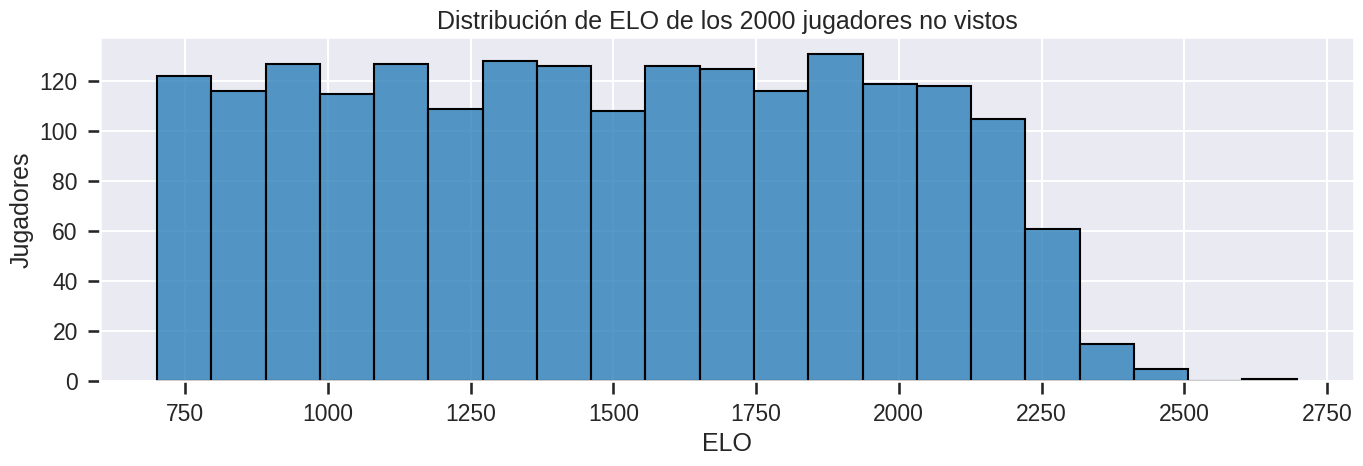

In [6]:
def sample_candidate_players_from_index(
    db_path: Path,
    min_games: int,
    limit: int,
) -> List[Tuple[str, int]]:
    conn = sqlite3.connect(str(db_path))
    try:
        cur = conn.cursor()
        cur.execute(
            "SELECT name, total_games FROM players "
            "WHERE total_games >= ? "
            "ORDER BY RANDOM() LIMIT ?",
            (int(min_games), int(limit)),
        )
        rows = cur.fetchall()
    finally:
        conn.close()
    return [(str(name), int(total_games)) for name, total_games in rows]


def build_candidate_catalog(
    refresh: bool = False,
) -> pd.DataFrame:
    if CATALOG_CSV_PATH.exists() and not refresh:
        catalog_df = pd.read_csv(CATALOG_CSV_PATH)
        if not catalog_df.empty:
            print(f"Usando catálogo existente: {CATALOG_CSV_PATH}")
            return catalog_df

    known_norm = {_norm_player(p) for p in TRAINED_PLAYERS}
    seen_players = set()
    rows = []

    for round_idx in range(CONFIG.catalog_max_rounds):
        candidate_rows = sample_candidate_players_from_index(
            db_path=INDEX_DB,
            min_games=CONFIG.min_games_in_db,
            limit=CONFIG.catalog_query_batch,
        )

        if not candidate_rows:
            break

        print(
            f"Catálogo round {round_idx + 1}/{CONFIG.catalog_max_rounds} | "
            f"candidatos SQL={len(candidate_rows)} | con_elo={len(rows)}"
        )

        for player_name, total_games in candidate_rows:
            player_norm = _norm_player(player_name)
            if player_norm in known_norm or player_norm in seen_players:
                continue

            seen_players.add(player_norm)
            zst_path = find_zst_path(player_name)
            if zst_path is None:
                continue

            elo = extract_elo_from_zst(zst_path)
            if elo is None:
                continue
            if not (CONFIG.elo_min <= elo <= CONFIG.elo_max):
                continue

            rows.append(
                {
                    "player": player_name,
                    "total_games": int(total_games),
                    "elo": int(elo),
                    "zst_path": str(zst_path),
                }
            )

            if len(rows) >= CONFIG.catalog_target_with_elo:
                break

        if len(rows) >= CONFIG.catalog_target_with_elo:
            break

    if not rows:
        raise RuntimeError("No se pudo construir catálogo con ELO válido.")

    catalog_df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["player"])
        .sort_values(["elo", "total_games", "player"])
        .reset_index(drop=True)
    )
    catalog_df.to_csv(CATALOG_CSV_PATH, index=False)
    print(f"Catálogo guardado en {CATALOG_CSV_PATH} con {len(catalog_df)} jugadores.")
    return catalog_df


def stratified_round_robin_sample(
    catalog_df: pd.DataFrame,
    target_players: int,
    bin_size: int,
    seed: int,
) -> pd.DataFrame:
    if len(catalog_df) < target_players:
        raise RuntimeError(
            f"Catálogo insuficiente: {len(catalog_df)} < {target_players}"
        )

    work = catalog_df.copy()
    bins = list(range(CONFIG.elo_min, CONFIG.elo_max + bin_size, bin_size))
    work["elo_bin"] = pd.cut(
        work["elo"],
        bins=bins,
        labels=False,
        include_lowest=True,
    )
    work = work.dropna(subset=["elo_bin"]).copy()
    work["elo_bin"] = work["elo_bin"].astype(int)

    rng = random.Random(seed)
    per_bin_records: Dict[int, List[dict]] = {}
    for elo_bin, group in work.groupby("elo_bin"):
        records = group.to_dict("records")
        rng.shuffle(records)
        per_bin_records[int(elo_bin)] = records

    non_empty_bins = sorted(per_bin_records.keys())
    if not non_empty_bins:
        raise RuntimeError("No hay bins de ELO no vacíos en el catálogo.")

    selected = []
    cursor_by_bin = {elo_bin: 0 for elo_bin in non_empty_bins}

    while len(selected) < target_players:
        progressed = False
        for elo_bin in non_empty_bins:
            cursor = cursor_by_bin[elo_bin]
            items = per_bin_records[elo_bin]
            if cursor >= len(items):
                continue
            selected.append(items[cursor])
            cursor_by_bin[elo_bin] += 1
            progressed = True
            if len(selected) >= target_players:
                break
        if not progressed:
            break

    if len(selected) < target_players:
        raise RuntimeError(
            f"No fue posible seleccionar {target_players} jugadores variados por ELO."
        )

    selected_df = (
        pd.DataFrame(selected)
        .drop(columns=["elo_bin"], errors="ignore")
        .sort_values("elo")
        .reset_index(drop=True)
    )
    return selected_df


catalog_df = build_candidate_catalog(refresh=False)
selected_unknown_players_df = stratified_round_robin_sample(
    catalog_df=catalog_df,
    target_players=CONFIG.target_unknown_players,
    bin_size=CONFIG.elo_bin_size,
    seed=SEED,
)
selected_unknown_players_df.to_csv(SELECTED_PLAYERS_CSV_PATH, index=False)

print(f"Jugadores no vistos seleccionados: {len(selected_unknown_players_df)}")
display(selected_unknown_players_df.head(20))

plt.figure(figsize=(14, 5))
ax = sns.histplot(
    data=selected_unknown_players_df,
    x="elo",
    bins=max(10, (CONFIG.elo_max - CONFIG.elo_min) // CONFIG.elo_bin_size),
    color="tab:blue",
)
ax.set_title("Distribución de ELO de los 2000 jugadores no vistos")
ax.set_xlabel("ELO")
ax.set_ylabel("Jugadores")
plt.tight_layout()
plt.show()


In [7]:
def pairwise_distance_matrix(
    query_embeddings: np.ndarray,
    ref_embeddings: np.ndarray,
) -> np.ndarray:
    query = np.asarray(query_embeddings, dtype=np.float32)
    reference = np.asarray(ref_embeddings, dtype=np.float32)
    sims = np.clip(query @ reference.T, -1.0, 1.0)
    dist_sq = np.maximum(2.0 - 2.0 * sims, 0.0)
    return np.sqrt(dist_sq + 1e-12).astype(np.float32)


def aggregate_player_distances(
    query_to_ref_dists: np.ndarray,
    ref_labels: np.ndarray,
    num_players: int,
    top_k: int,
    strategy: str = "mean",
    temperature: float = 30.0,
) -> np.ndarray:
    strategy = str(strategy).strip().lower()
    if strategy not in {"mean", "softmin"}:
        raise ValueError("strategy debe ser 'mean' o 'softmin'.")

    out = np.full((query_to_ref_dists.shape[0], num_players), np.inf, dtype=np.float32)
    for player_idx in range(num_players):
        class_mask = ref_labels == player_idx
        class_dists = query_to_ref_dists[:, class_mask]
        if class_dists.size == 0:
            continue

        k = min(max(1, int(top_k)), class_dists.shape[1])
        topk = np.partition(class_dists, kth=k - 1, axis=1)[:, :k]
        topk.sort(axis=1)

        if strategy == "mean" or k == 1:
            out[:, player_idx] = topk.mean(axis=1)
            continue

        weights = np.exp(-float(temperature) * topk)
        weights_sum = np.maximum(weights.sum(axis=1, keepdims=True), 1e-8)
        out[:, player_idx] = np.sum(weights * topk, axis=1) / weights_sum[:, 0]

    return out


def weighted_average_from_distances(
    values: np.ndarray,
    dists: np.ndarray,
    k: int,
    eps: float = 1e-6,
) -> float:
    values = np.asarray(values, dtype=np.float32)
    dists = np.asarray(dists, dtype=np.float32)

    valid_mask = np.isfinite(values) & np.isfinite(dists)
    values = values[valid_mask]
    dists = dists[valid_mask]
    if values.size == 0:
        return float("nan")

    k = min(max(1, int(k)), values.size)
    order = np.argsort(dists)[:k]
    picked_values = values[order]
    picked_dists = dists[order]
    weights = 1.0 / np.maximum(picked_dists, eps)
    weights_sum = float(np.sum(weights))
    if weights_sum <= 0:
        return float(np.mean(picked_values))
    return float(np.sum(weights * picked_values) / weights_sum)


def predict_elo_from_embeddings(batch_embeddings: np.ndarray) -> pd.DataFrame:
    query_to_ref_dists = pairwise_distance_matrix(batch_embeddings, train_embeddings)

    nearest_ref_idx = np.argmin(query_to_ref_dists, axis=1)
    exemplar_top1_elo = reference_game_elos[nearest_ref_idx]
    exemplar_top1_dist = query_to_ref_dists[np.arange(len(batch_embeddings)), nearest_ref_idx]

    exemplar_knn_elo = np.array(
        [
            weighted_average_from_distances(
                values=reference_game_elos,
                dists=row_dists,
                k=CONFIG.exemplar_knn_k,
                eps=CONFIG.weight_epsilon,
            )
            for row_dists in query_to_ref_dists
        ],
        dtype=np.float32,
    )

    player_memory_dists = aggregate_player_distances(
        query_to_ref_dists=query_to_ref_dists,
        ref_labels=train_labels,
        num_players=len(reference_players),
        top_k=CONFIG.player_memory_top_k,
        strategy=CONFIG.player_memory_strategy,
        temperature=CONFIG.softmin_temperature,
    )
    player_memory_pred_idx = np.argmin(player_memory_dists, axis=1)
    player_memory_top1_elo = reference_player_elos[player_memory_pred_idx]
    player_memory_top1_dist = player_memory_dists[
        np.arange(len(batch_embeddings)), player_memory_pred_idx
    ]
    player_memory_weighted_elo = np.array(
        [
            weighted_average_from_distances(
                values=reference_player_elos,
                dists=row_dists,
                k=CONFIG.player_regression_k,
                eps=CONFIG.weight_epsilon,
            )
            for row_dists in player_memory_dists
        ],
        dtype=np.float32,
    )

    centroid_dists = pairwise_distance_matrix(batch_embeddings, centroid_matrix)
    centroid_pred_idx = np.argmin(centroid_dists, axis=1)
    centroid_top1_elo = reference_player_elos[centroid_pred_idx]
    centroid_top1_dist = centroid_dists[np.arange(len(batch_embeddings)), centroid_pred_idx]
    centroid_weighted_elo = np.array(
        [
            weighted_average_from_distances(
                values=reference_player_elos,
                dists=row_dists,
                k=CONFIG.centroid_regression_k,
                eps=CONFIG.weight_epsilon,
            )
            for row_dists in centroid_dists
        ],
        dtype=np.float32,
    )

    out = pd.DataFrame(
        {
            "pred_elo_exemplar_top1": exemplar_top1_elo,
            "pred_elo_exemplar_knn": exemplar_knn_elo,
            "pred_elo_player_memory_top1": player_memory_top1_elo,
            "pred_elo_player_memory_weighted": player_memory_weighted_elo,
            "pred_elo_centroid_top1": centroid_top1_elo,
            "pred_elo_centroid_weighted": centroid_weighted_elo,
            "dist_exemplar_top1": exemplar_top1_dist,
            "dist_player_memory_top1": player_memory_top1_dist,
            "dist_centroid_top1": centroid_top1_dist,
            "pred_player_memory_top1": [reference_players[idx] for idx in player_memory_pred_idx],
            "pred_centroid_top1": [reference_players[idx] for idx in centroid_pred_idx],
            "pred_player_exemplar_top1": [TRAIN_SAMPLES[idx].player for idx in nearest_ref_idx],
            "pred_game_exemplar_top1": [TRAIN_SAMPLES[idx].game_id for idx in nearest_ref_idx],
        }
    )
    return out


def infer_unknown_player_games(player_row: pd.Series) -> pd.DataFrame:
    player_name = str(player_row["player"])
    player_elo = float(player_row["elo"])
    zst_path = Path(player_row["zst_path"])
    player_seed = stable_player_seed(player_name, SEED)

    sampled_games, scanned_total, useful_seen = sample_random_games_from_zst(
        zst_path=zst_path,
        player_name=player_name,
        sample_size=CONFIG.unknown_games_per_player,
        seed=player_seed,
        max_games_to_scan=CONFIG.max_games_to_scan_per_player,
    )

    if not sampled_games:
        return pd.DataFrame()

    meta_rows = []
    board_batches = []
    heat_batches = []

    for game_index, game, side in sampled_games:
        try:
            boards, heats = build_single_game_tensor(
                game=game,
                side=side,
                sequence_len=CONFIG.sequence_len,
                fullmove_start=CONFIG.fullmove_start,
                fullmove_end=CONFIG.fullmove_end,
                image_size=CONFIG.image_size,
            )
        except Exception:
            continue

        board_batches.append(boards[0])
        heat_batches.append(heats[0])
        meta_rows.append(
            {
                "unknown_player": player_name,
                "unknown_elo": player_elo,
                "game_index": int(game_index),
                "side": side,
                "scanned_total_games_in_file": int(scanned_total),
                "useful_games_seen_in_file": int(useful_seen),
            }
        )

    if not meta_rows:
        return pd.DataFrame()

    boards_np = np.stack(board_batches).astype(np.float32)
    heats_np = np.stack(heat_batches).astype(np.float32)
    emb = embedding_model.predict(
        {"board_sequence": boards_np, "heat_sequence": heats_np},
        batch_size=min(CONFIG.infer_batch_size, len(meta_rows)),
        verbose=0,
    ).astype(np.float32)

    pred_df = predict_elo_from_embeddings(emb)
    out = pd.concat([pd.DataFrame(meta_rows), pred_df], axis=1)
    return out


def save_run_meta() -> None:
    payload = {
        "config": asdict(CONFIG),
        "event_dir": str(EVENT_DIR),
        "index_db": str(INDEX_DB),
        "players_dir": str(ZST_PLAYERS_DIR),
        "reference_players": reference_players,
        "reference_player_elos": [float(x) for x in reference_player_elos],
        "reference_games": int(len(TRAIN_SAMPLES)),
    }
    RUN_META_PATH.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


def evaluate_unknown_players_at_scale(
    selected_players_df: pd.DataFrame,
    resume_existing: bool = True,
) -> pd.DataFrame:
    save_run_meta()

    completed_players = set()
    if resume_existing and GAME_PREDICTIONS_CSV_PATH.exists():
        existing = pd.read_csv(GAME_PREDICTIONS_CSV_PATH)
        if not existing.empty and "unknown_player" in existing.columns:
            counts = (
                existing.groupby("unknown_player")
                .size()
                .rename("games_evaluated")
                .reset_index()
            )
            completed_players = set(
                counts.loc[
                    counts["games_evaluated"] >= CONFIG.player_level_min_valid_games,
                    "unknown_player",
                ].astype(str)
            )
            keep_mask = existing["unknown_player"].astype(str).isin(completed_players)
            existing = existing.loc[keep_mask].reset_index(drop=True)
            existing.to_csv(GAME_PREDICTIONS_CSV_PATH, index=False)
        print(
            f"Resume activo: {len(completed_players)} jugadores ya estaban evaluados."
        )
    elif GAME_PREDICTIONS_CSV_PATH.exists():
        GAME_PREDICTIONS_CSV_PATH.unlink()

    processed_since_flush = 0
    total_targets = len(selected_players_df)

    for idx, (_, row) in enumerate(selected_players_df.iterrows(), start=1):
        player_name = str(row["player"])
        if player_name in completed_players:
            continue

        print(
            f"[{idx}/{total_targets}] Evaluando {player_name} "
            f"(ELO {int(row['elo'])})"
        )
        player_df = infer_unknown_player_games(row)

        if player_df.empty:
            print("  sin partidas válidas")
        else:
            write_header = not GAME_PREDICTIONS_CSV_PATH.exists()
            player_df.to_csv(
                GAME_PREDICTIONS_CSV_PATH,
                mode="a",
                header=write_header,
                index=False,
            )
            print(f"  partidas válidas guardadas: {len(player_df)}")

        processed_since_flush += 1
        if processed_since_flush >= CONFIG.save_every_players:
            processed_since_flush = 0
            gc.collect()

    if not GAME_PREDICTIONS_CSV_PATH.exists():
        raise RuntimeError("No se generaron predicciones.")

    return pd.read_csv(GAME_PREDICTIONS_CSV_PATH)


can_load_game_predictions_cache = False
if CONFIG.resume_existing and not FORCE_REEVALUATE_UNKNOWN_GAMES and GAME_PREDICTIONS_CSV_PATH.exists():
    cached_game_predictions_df = pd.read_csv(GAME_PREDICTIONS_CSV_PATH)
    if not cached_game_predictions_df.empty and "unknown_player" in cached_game_predictions_df.columns:
        cached_counts = (
            cached_game_predictions_df.groupby("unknown_player")
            .size()
            .rename("games_evaluated")
            .reset_index()
        )
        completed_cached_players = set(
            cached_counts.loc[
                cached_counts["games_evaluated"] >= CONFIG.player_level_min_valid_games,
                "unknown_player",
            ].astype(str)
        )
        target_cached_players = set(selected_unknown_players_df["player"].astype(str))
        can_load_game_predictions_cache = target_cached_players.issubset(completed_cached_players)

if can_load_game_predictions_cache:
    game_predictions_df = cached_game_predictions_df.copy()
    print(f"Predicciones a nivel partida cargadas desde cache: {GAME_PREDICTIONS_CSV_PATH}")
else:
    game_predictions_df = evaluate_unknown_players_at_scale(
        selected_players_df=selected_unknown_players_df,
        resume_existing=CONFIG.resume_existing and not FORCE_REEVALUATE_UNKNOWN_GAMES,
    )

print(f"Predicciones a nivel partida: {len(game_predictions_df)}")
display(game_predictions_df.head(20))


Predicciones a nivel partida cargadas desde cache: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/game_level_predictions.csv
Predicciones a nivel partida: 40000


,unknown_player,unknown_elo,game_index,side,scanned_total_games_in_file,useful_games_seen_in_file,pred_elo_exemplar_top1,pred_elo_exemplar_knn,pred_elo_player_memory_top1,pred_elo_player_memory_weighted,pred_elo_centroid_top1,pred_elo_centroid_weighted,dist_exemplar_top1,dist_player_memory_top1,dist_centroid_top1,pred_player_memory_top1,pred_centroid_top1,pred_player_exemplar_top1,pred_game_exemplar_top1
0,chainyx,701.0,2,white,117,117,1704.0,1583.0012,1319.0,1536.5829,1117.0,1245.07520,0.030352,0.035543,0.031671,polodu88,adelline,acm17,10
1,chainyx,701.0,3,black,117,117,1357.0,1355.4318,1628.0,1310.6449,1280.0,1137.22440,0.032633,0.036231,0.033398,Bazsalikom,ali885,calmeidajr,141
2,chainyx,701.0,11,white,117,117,1497.0,1238.5817,919.0,1193.1246,770.0,876.05560,0.032858,0.037361,0.035725,looseasagoosearms76,marwanabd,axtur777,104
3,chainyx,701.0,14,white,117,117,1669.0,1303.8365,638.0,1092.8579,716.0,848.91920,0.032380,0.038369,0.035883,manuelkevogo,youcef7112,jadi2019,113
4,chainyx,701.0,15,black,117,117,1038.0,1446.1282,1319.0,1571.4194,941.0,1087.04220,0.030567,0.042561,0.041906,polodu88,mathieuCham,durple,76
5,chainyx,701.0,20,white,117,117,1293.0,1510.3114,1202.0,1216.6790,1392.0,1056.37320,0.031783,0.037595,0.036766,sviddunaas,dhany82,gido0911,151
6,chainyx,701.0,22,white,117,117,1202.0,1433.2607,1202.0,1202.5863,1115.0,1047.93230,0.031095,0.039257,0.038436,sviddunaas,vilemus,sviddunaas,195
7,chainyx,701.0,24,white,117,117,1304.0,1429.8765,1304.0,1114.7556,734.0,1013.19670,0.033776,0.040032,0.038528,klimacool,hmzaydn,klimacool,179
8,chainyx,701.0,26,black,117,117,1202.0,1366.4991,1396.0,1319.4155,1202.0,1123.85110,0.029867,0.035640,0.030425,eagle_sajan,sviddunaas,sviddunaas,186
9,chainyx,701.0,41,white,117,117,1749.0,1388.6470,941.0,1288.9006,941.0,920.18317,0.030344,0.036657,0.031103,mathieuCham,mathieuCham,Emrahcetin,85


,method,coverage_games,mae,rmse,median_ae,corr
0,pred_elo_centroid_weighted,40000,356.612130,446.423475,299.91800,0.385883
1,pred_elo_player_memory_weighted,40000,359.058161,432.431781,327.62620,0.370300
2,pred_elo_exemplar_knn,40000,367.567782,431.035216,354.55645,0.387069
3,pred_elo_centroid_top1,40000,396.012975,503.881714,322.00000,0.334931
4,pred_elo_player_memory_top1,40000,406.225875,505.164760,349.00000,0.254904
5,pred_elo_exemplar_top1,40000,429.075750,528.943942,375.00000,0.159051


Resumen por jugador guardado en /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/player_level_summary.csv


,method,coverage_players,mae,rmse,median_ae,corr
0,pred_elo_centroid_top1,2000,287.662275,341.972177,272.625000,0.752060
1,pred_elo_centroid_weighted,2000,295.954249,349.267642,285.364679,0.774951
2,pred_elo_player_memory_top1,2000,328.982775,384.166994,321.275000,0.710353
3,pred_elo_player_memory_weighted,2000,333.759433,389.468085,322.065822,0.784254
4,pred_elo_exemplar_top1,2000,355.578350,416.142115,341.775000,0.564903
5,pred_elo_exemplar_knn,2000,360.957105,419.547011,350.929308,0.788792


RESUMEN EJECUTIVO · OPEN-SET ELO AT SCALE
Jugadores objetivo: 2000
Partidas por jugador: 20
Partidas válidas evaluadas: 40000
Jugadores con resumen: 2000
Mejor método por partida: pred_elo_centroid_weighted
Mejor método por jugador: pred_elo_centroid_top1


/tmp/ipykernel_143/2339024480.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_143/2339024480.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


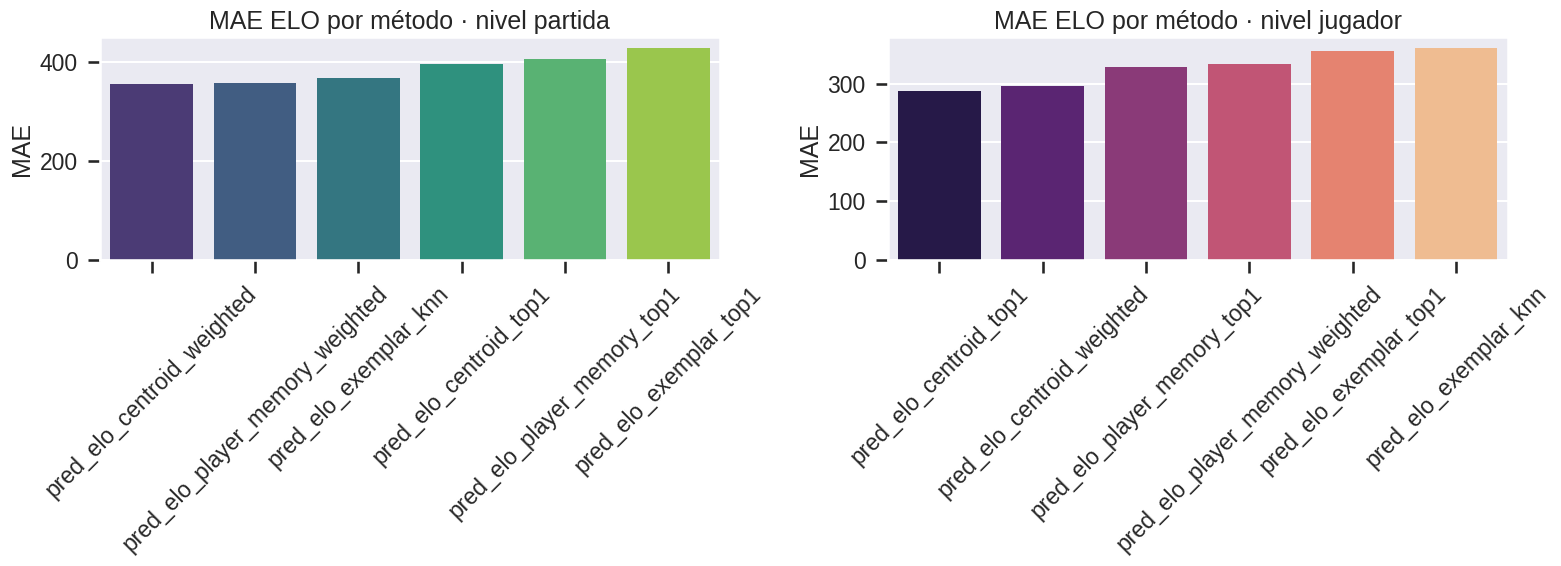

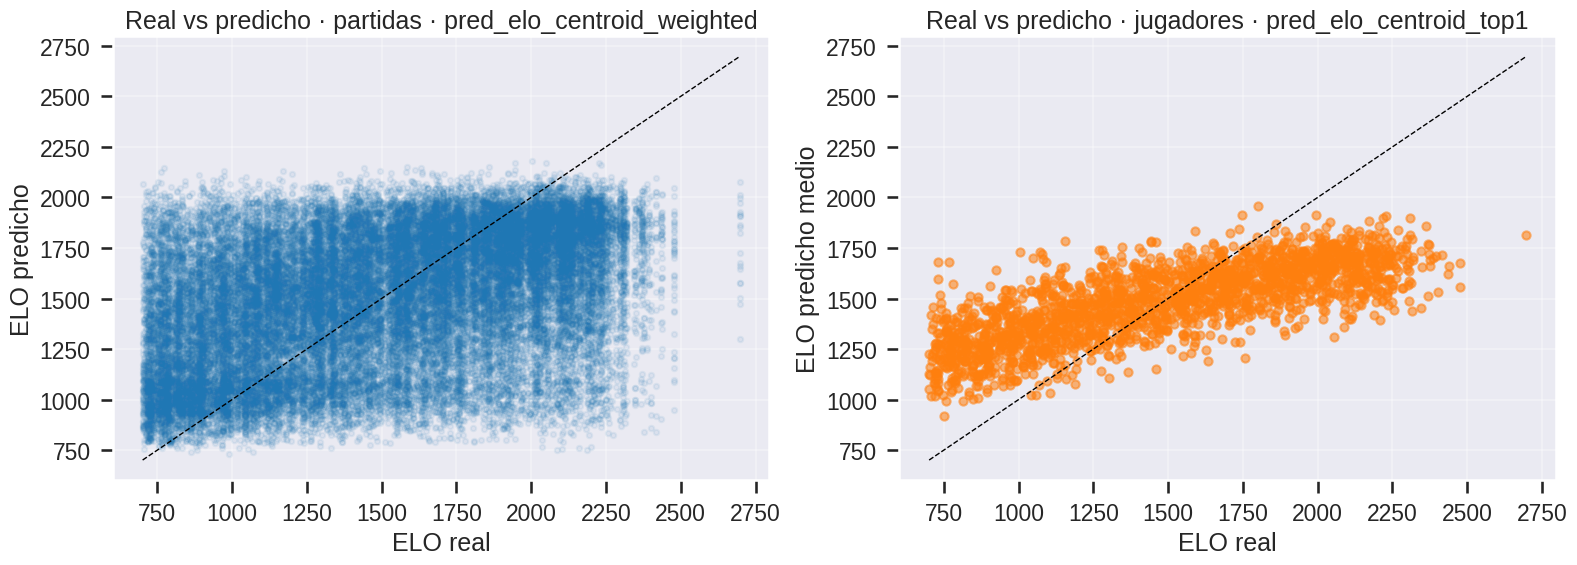

/tmp/ipykernel_143/2339024480.py:203: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


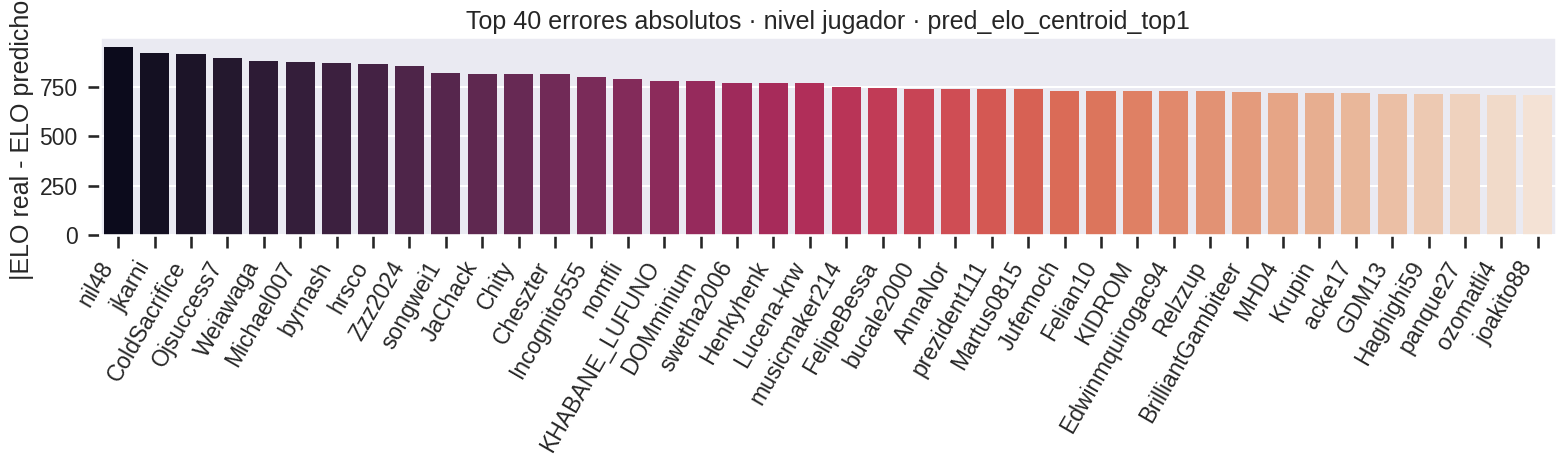

,unknown_player,unknown_elo,games_evaluated,pred_elo_exemplar_top1,pred_elo_exemplar_knn,pred_elo_player_memory_top1,pred_elo_player_memory_weighted,pred_elo_centroid_top1,pred_elo_centroid_weighted,dist_exemplar_top1_mean,dist_player_memory_top1_mean,dist_centroid_top1_mean,abs_error__pred_elo_exemplar_top1,abs_error__pred_elo_exemplar_knn,abs_error__pred_elo_player_memory_top1,abs_error__pred_elo_player_memory_weighted,abs_error__pred_elo_centroid_top1,abs_error__pred_elo_centroid_weighted
0,Kharanunos,701.0,20,1417.10,1444.144840,1254.30,1308.597045,1227.85,1297.322316,0.034578,0.039771,0.038715,716.10,743.144840,553.30,607.597045,526.85,596.322316
1,chainyx,701.0,20,1309.10,1387.795775,1206.45,1244.874810,1054.40,1035.936821,0.032272,0.038362,0.036116,608.10,686.795775,505.45,543.874810,353.40,334.936821
2,ReliableLikeBoeing,701.0,20,1359.30,1450.511855,1298.95,1323.451475,1127.30,1164.361913,0.033717,0.039482,0.038412,658.30,749.511855,597.95,622.451475,426.30,463.361913
3,Gopnik00,705.0,20,1504.25,1461.131055,1372.15,1403.021635,1161.10,1244.238863,0.032310,0.037501,0.033770,799.25,756.131055,667.15,698.021635,456.10,539.238863
4,rootoguzz,705.0,20,1543.00,1448.445655,1472.55,1392.954848,1119.65,1216.791960,0.033053,0.038518,0.035328,838.00,743.445655,767.55,687.954848,414.65,511.791960
5,panque27,707.0,20,1597.25,1549.067625,1490.10,1525.212745,1417.15,1439.739808,0.032896,0.038855,0.037173,890.25,842.067625,783.10,818.212745,710.15,732.739808
6,Bittu070707,707.0,20,1491.25,1477.510365,1449.40,1412.363010,1018.95,1155.456831,0.034509,0.039945,0.037627,784.25,770.510365,742.40,705.363010,311.95,448.456831
7,petersene24,712.0,20,1496.65,1530.523685,1546.25,1535.586280,1348.05,1398.881211,0.032885,0.038593,0.036709,784.65,818.523685,834.25,823.586280,636.05,686.881211
8,oldoakdao,712.0,20,1512.90,1483.211445,1370.45,1394.024185,1215.45,1265.340461,0.033411,0.038381,0.036600,800.90,771.211445,658.45,682.024185,503.45,553.340461
9,Iskarova_Nasikha,712.0,20,1480.75,1452.493310,1270.80,1376.740165,1191.20,1182.533618,0.034605,0.039419,0.037416,768.75,740.493310,558.80,664.740165,479.20,470.533618


In [8]:
prediction_cols = [
    "pred_elo_exemplar_top1",
    "pred_elo_exemplar_knn",
    "pred_elo_player_memory_top1",
    "pred_elo_player_memory_weighted",
    "pred_elo_centroid_top1",
    "pred_elo_centroid_weighted",
]

eval_df = game_predictions_df.copy()
for col in prediction_cols:
    eval_df[f"abs_error__{col}"] = (eval_df[col] - eval_df["unknown_elo"]).abs()
    eval_df[f"sq_error__{col}"] = (eval_df[col] - eval_df["unknown_elo"]) ** 2


metric_rows = []
for col in prediction_cols:
    valid = eval_df.dropna(subset=[col, "unknown_elo"]).copy()
    if valid.empty:
        continue

    mae = float(np.mean(np.abs(valid[col] - valid["unknown_elo"])))
    rmse = float(np.sqrt(np.mean((valid[col] - valid["unknown_elo"]) ** 2)))
    medae = float(np.median(np.abs(valid[col] - valid["unknown_elo"])))
    corr = (
        float(np.corrcoef(valid["unknown_elo"], valid[col])[0, 1])
        if len(valid) >= 2
        else np.nan
    )
    metric_rows.append(
        {
            "method": col,
            "coverage_games": int(len(valid)),
            "mae": mae,
            "rmse": rmse,
            "median_ae": medae,
            "corr": corr,
        }
    )

game_metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values(["mae", "rmse", "method"])
    .reset_index(drop=True)
)
display(game_metrics_df)


player_summary_df = (
    eval_df.groupby(["unknown_player", "unknown_elo"], as_index=False)
    .agg(
        games_evaluated=("game_index", "count"),
        pred_elo_exemplar_top1=("pred_elo_exemplar_top1", "mean"),
        pred_elo_exemplar_knn=("pred_elo_exemplar_knn", "mean"),
        pred_elo_player_memory_top1=("pred_elo_player_memory_top1", "mean"),
        pred_elo_player_memory_weighted=("pred_elo_player_memory_weighted", "mean"),
        pred_elo_centroid_top1=("pred_elo_centroid_top1", "mean"),
        pred_elo_centroid_weighted=("pred_elo_centroid_weighted", "mean"),
        dist_exemplar_top1_mean=("dist_exemplar_top1", "mean"),
        dist_player_memory_top1_mean=("dist_player_memory_top1", "mean"),
        dist_centroid_top1_mean=("dist_centroid_top1", "mean"),
    )
    .sort_values("unknown_elo")
    .reset_index(drop=True)
)
player_summary_df = (
    player_summary_df.loc[
        player_summary_df["games_evaluated"] >= CONFIG.player_level_min_valid_games
    ]
    .copy()
    .reset_index(drop=True)
)

for col in prediction_cols:
    player_summary_df[f"abs_error__{col}"] = (
        player_summary_df[col] - player_summary_df["unknown_elo"]
    ).abs()

player_summary_df.to_csv(PLAYER_SUMMARY_CSV_PATH, index=False)
print(f"Resumen por jugador guardado en {PLAYER_SUMMARY_CSV_PATH}")


player_metric_rows = []
for col in prediction_cols:
    valid = player_summary_df.dropna(subset=[col, "unknown_elo"]).copy()
    if valid.empty:
        continue

    mae = float(np.mean(np.abs(valid[col] - valid["unknown_elo"])))
    rmse = float(np.sqrt(np.mean((valid[col] - valid["unknown_elo"]) ** 2)))
    medae = float(np.median(np.abs(valid[col] - valid["unknown_elo"])))
    corr = (
        float(np.corrcoef(valid["unknown_elo"], valid[col])[0, 1])
        if len(valid) >= 2
        else np.nan
    )
    player_metric_rows.append(
        {
            "method": col,
            "coverage_players": int(len(valid)),
            "mae": mae,
            "rmse": rmse,
            "median_ae": medae,
            "corr": corr,
        }
    )

player_metrics_df = (
    pd.DataFrame(player_metric_rows)
    .sort_values(["mae", "rmse", "method"])
    .reset_index(drop=True)
)
display(player_metrics_df)

best_game_method = str(game_metrics_df.iloc[0]["method"])
best_player_method = str(player_metrics_df.iloc[0]["method"])

print("=" * 90)
print("RESUMEN EJECUTIVO · OPEN-SET ELO AT SCALE")
print("=" * 90)
print(f"Jugadores objetivo: {CONFIG.target_unknown_players}")
print(f"Partidas por jugador: {CONFIG.unknown_games_per_player}")
print(f"Partidas válidas evaluadas: {len(eval_df)}")
print(f"Jugadores con resumen: {len(player_summary_df)}")
print(f"Mejor método por partida: {best_game_method}")
print(f"Mejor método por jugador: {best_player_method}")
print("=" * 90)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=game_metrics_df,
    x="method",
    y="mae",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("MAE ELO por método · nivel partida")
axes[0].set_xlabel("")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=player_metrics_df,
    x="method",
    y="mae",
    palette="magma",
    ax=axes[1],
)
axes[1].set_title("MAE ELO por método · nivel jugador")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

game_plot_df = eval_df.dropna(subset=[best_game_method, "unknown_elo"]).copy()
axes[0].scatter(
    game_plot_df["unknown_elo"],
    game_plot_df[best_game_method],
    alpha=0.08,
    s=15,
    color="tab:blue",
)
if not game_plot_df.empty:
    lo = float(min(game_plot_df["unknown_elo"].min(), game_plot_df[best_game_method].min()))
    hi = float(max(game_plot_df["unknown_elo"].max(), game_plot_df[best_game_method].max()))
    axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_title(f"Real vs predicho · partidas · {best_game_method}")
axes[0].set_xlabel("ELO real")
axes[0].set_ylabel("ELO predicho")
axes[0].grid(True, alpha=0.3)

player_plot_df = player_summary_df.dropna(subset=[best_player_method, "unknown_elo"]).copy()
axes[1].scatter(
    player_plot_df["unknown_elo"],
    player_plot_df[best_player_method],
    alpha=0.55,
    s=35,
    color="tab:orange",
)
if not player_plot_df.empty:
    lo = float(min(player_plot_df["unknown_elo"].min(), player_plot_df[best_player_method].min()))
    hi = float(max(player_plot_df["unknown_elo"].max(), player_plot_df[best_player_method].max()))
    axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[1].set_title(f"Real vs predicho · jugadores · {best_player_method}")
axes[1].set_xlabel("ELO real")
axes[1].set_ylabel("ELO predicho medio")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 5))
top_player_errors_df = (
    player_summary_df[["unknown_player", "unknown_elo", f"abs_error__{best_player_method}"]]
    .sort_values(f"abs_error__{best_player_method}", ascending=False)
    .head(40)
)
ax = sns.barplot(
    data=top_player_errors_df,
    x="unknown_player",
    y=f"abs_error__{best_player_method}",
    palette="rocket",
)
ax.set_title(f"Top 40 errores absolutos · nivel jugador · {best_player_method}")
ax.set_xlabel("")
ax.set_ylabel("|ELO real - ELO predicho|")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

display(player_summary_df.head(20))


## Notas de uso

- Si el proceso se interrumpe, vuelve a ejecutar la celda de evaluación con `resume_existing=True`.
- Si el `reservoir sampling` completo tarda demasiado, puedes poner `CONFIG.max_games_to_scan_per_player`
  a un entero para recortar el coste, pero perderás arbitrariedad real sobre todo el archivo.
- El método principal recomendado para juzgar la promesa del embedding es comparar:
  `pred_elo_exemplar_knn` frente a `pred_elo_player_memory_weighted`.


REPLICA 132 · ELO MEDIO PREDICHO (TOP-1) VS ELO REAL (NO-VISTO)
Jugadores no vistos válidos: 2000
Partidas mínimas por jugador exigidas: 5
MAE ELO (top-1 medio por jugador):  328.98
RMSE ELO (top-1 medio por jugador): 384.17
Correlación real/predicho:         0.7104


,unknown_player,unknown_elo,games_evaluated,pred_elo_mean,top1_dist_mean,elo_abs_error
0,Kharanunos,701.0,20,1254.30,0.039771,553.30
1,chainyx,701.0,20,1206.45,0.038362,505.45
2,ReliableLikeBoeing,701.0,20,1298.95,0.039482,597.95
3,Gopnik00,705.0,20,1372.15,0.037501,667.15
4,rootoguzz,705.0,20,1472.55,0.038518,767.55
5,panque27,707.0,20,1490.10,0.038855,783.10
6,Bittu070707,707.0,20,1449.40,0.039945,742.40
7,petersene24,712.0,20,1546.25,0.038593,834.25
8,oldoakdao,712.0,20,1370.45,0.038381,658.45
9,Iskarova_Nasikha,712.0,20,1270.80,0.039419,558.80


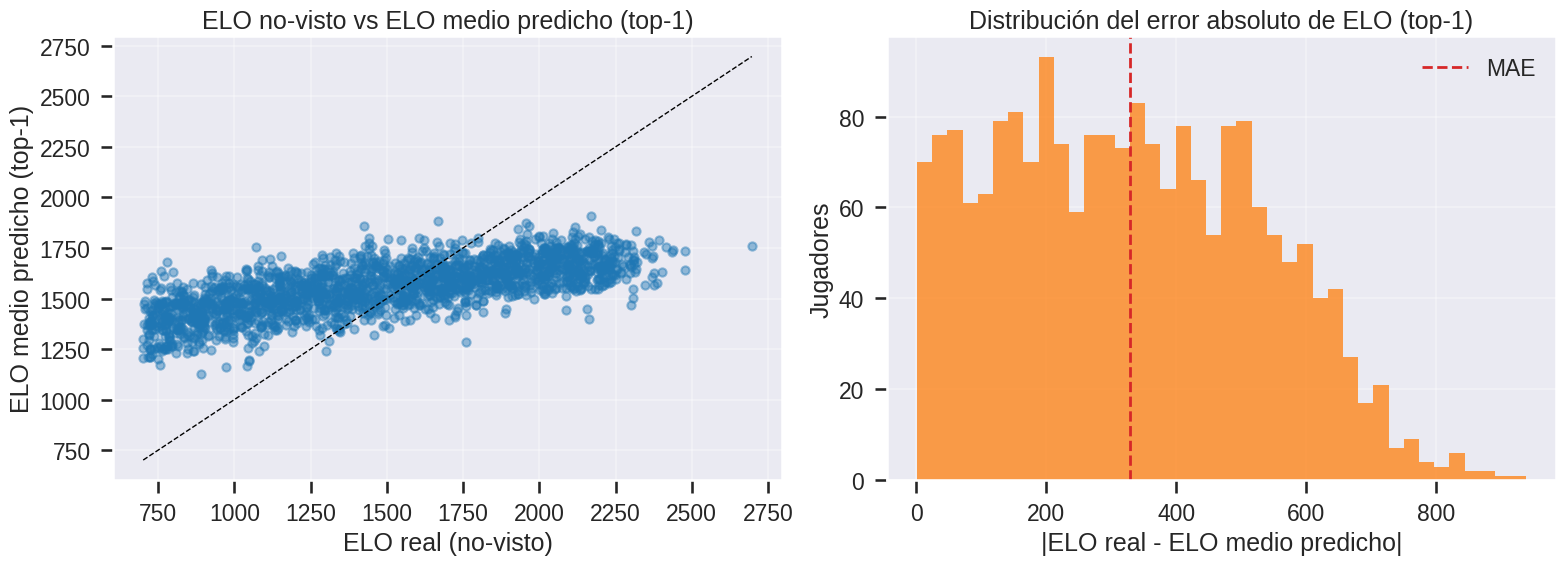

In [9]:
top1_elo_summary_df = (
    eval_df.groupby(["unknown_player", "unknown_elo"], as_index=False)
    .agg(
        games_evaluated=("game_index", "count"),
        pred_elo_mean=("pred_elo_player_memory_top1", "mean"),
        top1_dist_mean=("dist_player_memory_top1", "mean"),
    )
    .sort_values("unknown_elo")
    .reset_index(drop=True)
)
top1_elo_summary_df = (
    top1_elo_summary_df.loc[
        top1_elo_summary_df["games_evaluated"] >= CONFIG.player_level_min_valid_games
    ]
    .copy()
    .reset_index(drop=True)
)
top1_elo_summary_df["elo_abs_error"] = (
    top1_elo_summary_df["pred_elo_mean"] - top1_elo_summary_df["unknown_elo"]
).abs()

top1_valid_df = top1_elo_summary_df.dropna(subset=["pred_elo_mean", "unknown_elo"]).copy()
elo_mae_top1 = float(
    np.mean(np.abs(top1_valid_df["pred_elo_mean"] - top1_valid_df["unknown_elo"]))
)
elo_rmse_top1 = float(
    np.sqrt(np.mean((top1_valid_df["pred_elo_mean"] - top1_valid_df["unknown_elo"]) ** 2))
)
elo_corr_top1 = (
    float(np.corrcoef(top1_valid_df["unknown_elo"], top1_valid_df["pred_elo_mean"])[0, 1])
    if len(top1_valid_df) >= 2
    else np.nan
)

print("=" * 90)
print("REPLICA 132 · ELO MEDIO PREDICHO (TOP-1) VS ELO REAL (NO-VISTO)")
print("=" * 90)
print(f"Jugadores no vistos válidos: {len(top1_valid_df)}")
print(f"Partidas mínimas por jugador exigidas: {CONFIG.player_level_min_valid_games}")
print(f"MAE ELO (top-1 medio por jugador):  {elo_mae_top1:.2f}")
print(f"RMSE ELO (top-1 medio por jugador): {elo_rmse_top1:.2f}")
if not np.isnan(elo_corr_top1):
    print(f"Correlación real/predicho:         {elo_corr_top1:.4f}")
else:
    print("Correlación real/predicho:         no disponible")
print("=" * 90)

display(top1_elo_summary_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    top1_valid_df["unknown_elo"],
    top1_valid_df["pred_elo_mean"],
    alpha=0.45,
    s=35,
    color="tab:blue",
)
if not top1_valid_df.empty:
    lo = float(min(top1_valid_df["unknown_elo"].min(), top1_valid_df["pred_elo_mean"].min()))
    hi = float(max(top1_valid_df["unknown_elo"].max(), top1_valid_df["pred_elo_mean"].max()))
    axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_title("ELO no-visto vs ELO medio predicho (top-1)")
axes[0].set_xlabel("ELO real (no-visto)")
axes[0].set_ylabel("ELO medio predicho (top-1)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(
    top1_valid_df["elo_abs_error"],
    bins=40,
    color="tab:orange",
    alpha=0.75,
)
axes[1].axvline(elo_mae_top1, color="tab:red", linestyle="--", linewidth=2, label="MAE")
axes[1].set_title("Distribución del error absoluto de ELO (top-1)")
axes[1].set_xlabel("|ELO real - ELO medio predicho|")
axes[1].set_ylabel("Jugadores")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Calibración lineal del ELO predicho

La nube anterior muestra una predicción comprimida hacia el centro del rango de ELO. Esta celda ajusta una calibración lineal de la forma `ELO_real ≈ a + b * ELO_predicho` para convertir el `pred_elo_mean` top-1 en un ELO calibrado.

Se reportan dos lecturas:

- `linear_in_sample`: ajuste y evaluación sobre todos los puntos; útil para ver el máximo enderezamiento posible, pero optimista.
- `linear_oof`: calibración out-of-fold por jugador; más honesta para estimar si el ajuste generaliza dentro de este benchmark.


CALIBRACIÓN LINEAL TOP-1 PLAYER-MEMORY
Modelo full-fit: ELO_calibrado = -2518.814 + 2.580280 * ELO_predicho
CSV calibrado: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/top1_linear_calibration.csv
CSV métricas:  /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/top1_linear_calibration_metrics.csv


,pred_col,variant,n,mae,rmse,median_ae,bias,corr,full_fit_intercept,full_fit_slope,n_splits
0,pred_elo_mean,linear_in_sample_clipped,2000,260.472233,321.614880,226.026276,9.892749e-01,0.712140,-2518.814476,2.58028,5
1,pred_elo_mean,linear_oof_clipped,2000,260.633418,321.784781,225.173584,9.366955e-01,0.711769,-2518.814476,2.58028,5
2,pred_elo_mean,linear_in_sample,2000,261.461507,322.422679,226.372681,2.441406e-07,0.710353,-2518.814476,2.58028,5
3,pred_elo_mean,linear_oof,2000,261.642315,322.627166,226.186829,-7.220129e-02,0.709911,-2518.814476,2.58028,5
4,pred_elo_mean,raw,2000,328.982775,384.166994,321.275000,6.253482e+01,0.710353,-2518.814476,2.58028,5


,unknown_player,unknown_elo,games_evaluated,pred_elo_mean,top1_dist_mean,elo_abs_error,pred_elo_mean__linear_in_sample,pred_elo_mean__linear_in_sample_clipped,pred_elo_mean__linear_oof,pred_elo_mean__linear_oof_clipped,abs_error__pred_elo_mean__raw,abs_error__pred_elo_mean__linear_oof_clipped
0,Kharanunos,701.0,20,1254.30,0.039771,553.30,717.630188,717.630188,727.603821,727.603821,553.30,26.603821
1,chainyx,701.0,20,1206.45,0.038362,505.45,594.163818,700.000000,605.879883,700.000000,505.45,1.000000
2,ReliableLikeBoeing,701.0,20,1298.95,0.039482,597.95,832.839722,832.839722,826.005371,826.005371,597.95,125.005371
3,Gopnik00,705.0,20,1372.15,0.037501,667.15,1021.716187,1021.716187,1016.969116,1016.969116,667.15,311.969116
4,rootoguzz,705.0,20,1472.55,0.038518,767.55,1280.776245,1280.776245,1282.802368,1282.802368,767.55,577.802368
5,panque27,707.0,20,1490.10,0.038855,783.10,1326.060181,1326.060181,1327.447144,1327.447144,783.10,620.447144
6,Bittu070707,707.0,20,1449.40,0.039945,742.40,1221.042725,1221.042725,1223.911865,1223.911865,742.40,516.911865
7,petersene24,712.0,20,1546.25,0.038593,834.25,1470.942871,1470.942871,1473.437500,1473.437500,834.25,761.437500
8,oldoakdao,712.0,20,1370.45,0.038381,658.45,1017.329712,1017.329712,1012.534180,1012.534180,658.45,300.534180
9,Iskarova_Nasikha,712.0,20,1270.80,0.039419,558.80,760.204834,760.204834,752.567810,752.567810,558.80,40.567810


Mejora MAE out-of-fold clipped: 328.98 -> 260.63 (+68.35)
Nota: linear_in_sample es optimista; para producción, guarda el intercept/slope aprendido en un set de calibración separado.


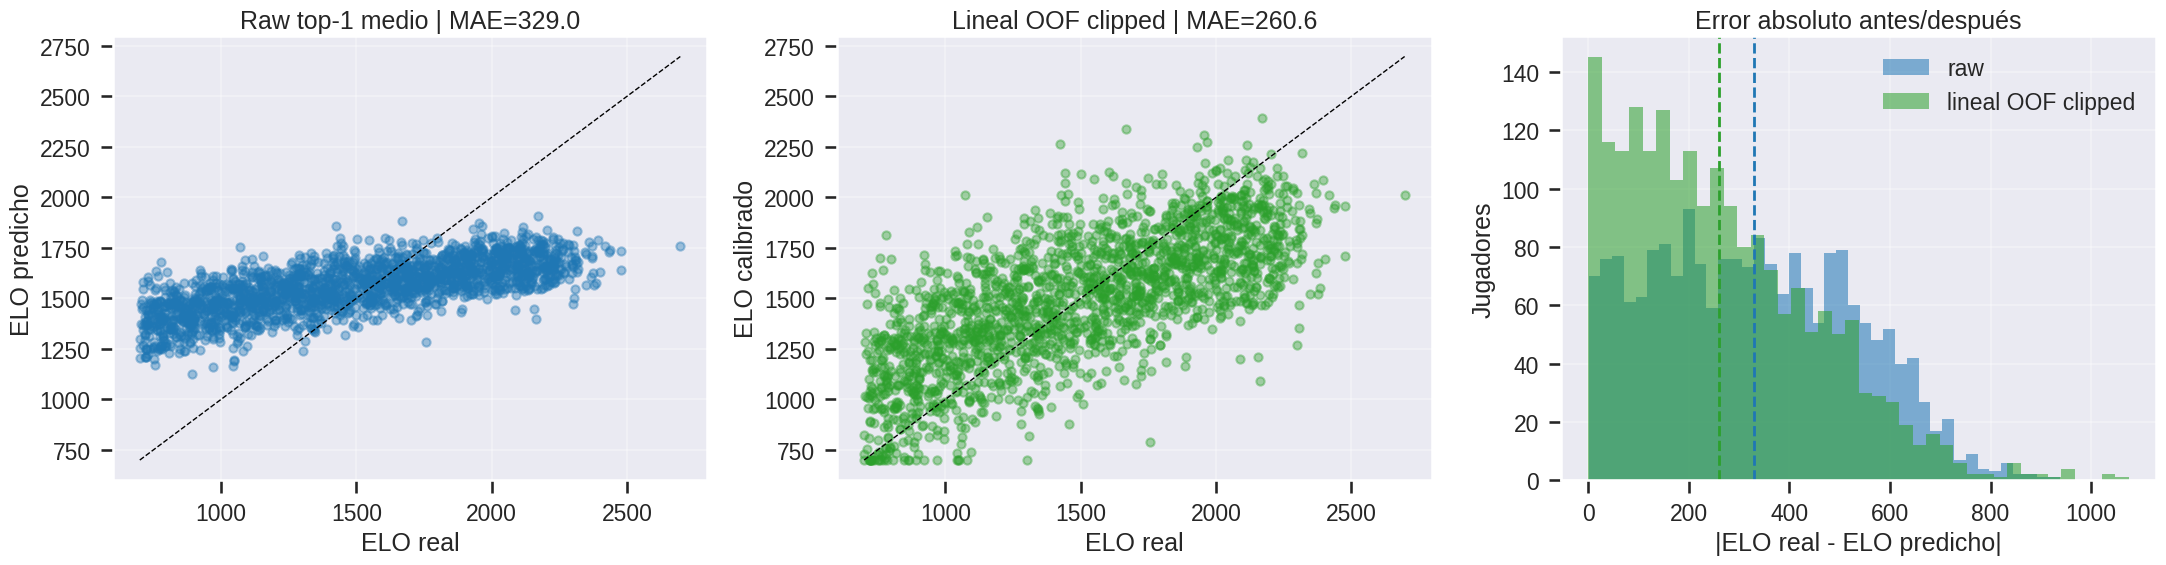

Métricas calibradas de todos los métodos: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/player_linear_calibration_metrics.csv


,pred_col,variant,n,mae,rmse,median_ae,bias,corr,full_fit_intercept,full_fit_slope,n_splits
0,pred_elo_exemplar_knn,linear_in_sample_clipped,2000,223.466548,280.712658,190.642456,1.384820e+00,0.790298,-8564.090546,6.490533,5
1,pred_elo_exemplar_knn,linear_oof_clipped,2000,223.617570,280.956512,190.786743,1.317066e+00,0.789875,-8564.090546,6.490533,5
2,pred_elo_exemplar_knn,linear_in_sample,2000,224.851368,281.567809,192.507324,3.051758e-08,0.788792,-8564.090546,6.490533,5
3,pred_elo_exemplar_knn,linear_oof,2000,225.028017,281.855258,193.049438,-9.338086e-02,0.788304,-8564.090546,6.490533,5
4,pred_elo_player_memory_weighted,linear_in_sample_clipped,2000,225.042008,282.656831,188.925354,2.060589e+00,0.787072,-4059.389796,3.569229,5
5,pred_elo_player_memory_weighted,linear_oof_clipped,2000,225.109508,282.792076,189.324036,1.990133e+00,0.786828,-4059.389796,3.569229,5
6,pred_elo_player_memory_weighted,linear_in_sample,2000,227.102596,284.215810,191.545166,1.235962e-06,0.784254,-4059.389796,3.569229,5
7,pred_elo_player_memory_weighted,linear_oof,2000,227.207183,284.409286,191.793091,-1.075420e-01,0.783920,-4059.389796,3.569229,5
8,pred_elo_centroid_weighted,linear_in_sample_clipped,2000,227.239047,288.888440,190.280121,9.789497e-01,0.776104,-1830.402727,2.223609,5
9,pred_elo_centroid_weighted,linear_oof_clipped,2000,227.352194,289.006916,190.059326,9.167615e-01,0.775889,-1830.402727,2.223609,5


In [10]:
TOP1_LINEAR_CALIBRATION_CSV_PATH = EVAL_DIR / "top1_linear_calibration.csv"
TOP1_LINEAR_CALIBRATION_METRICS_CSV_PATH = EVAL_DIR / "top1_linear_calibration_metrics.csv"
PLAYER_LINEAR_CALIBRATION_METRICS_CSV_PATH = EVAL_DIR / "player_linear_calibration_metrics.csv"


def _finite_xy(df: pd.DataFrame, pred_col: str, target_col: str = "unknown_elo") -> pd.DataFrame:
    work = df.dropna(subset=[pred_col, target_col]).copy().reset_index(drop=True)
    mask = np.isfinite(work[pred_col].to_numpy(dtype=np.float64)) & np.isfinite(
        work[target_col].to_numpy(dtype=np.float64)
    )
    return work.loc[mask].reset_index(drop=True)


def fit_linear_calibrator(
    x_pred: np.ndarray,
    y_true: np.ndarray,
) -> Tuple[float, float]:
    x = np.asarray(x_pred, dtype=np.float64)
    y = np.asarray(y_true, dtype=np.float64)
    if len(x) < 2:
        raise ValueError("Se necesitan al menos 2 puntos para ajustar una recta.")
    X = np.column_stack([np.ones(len(x), dtype=np.float64), x])
    intercept, slope = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(intercept), float(slope)


def apply_linear_calibrator(
    x_pred: np.ndarray,
    intercept: float,
    slope: float,
) -> np.ndarray:
    return (float(intercept) + float(slope) * np.asarray(x_pred, dtype=np.float64)).astype(np.float32)


def regression_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    prefix: str,
) -> Dict[str, float | int | str]:
    y = np.asarray(y_true, dtype=np.float64)
    pred = np.asarray(y_pred, dtype=np.float64)
    mask = np.isfinite(y) & np.isfinite(pred)
    y = y[mask]
    pred = pred[mask]
    if len(y) == 0:
        return {
            "variant": prefix,
            "n": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "median_ae": np.nan,
            "bias": np.nan,
            "corr": np.nan,
        }
    err = pred - y
    return {
        "variant": prefix,
        "n": int(len(y)),
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "median_ae": float(np.median(np.abs(err))),
        "bias": float(np.mean(err)),
        "corr": float(np.corrcoef(y, pred)[0, 1]) if len(y) >= 2 else np.nan,
    }


def oof_linear_calibration(
    df: pd.DataFrame,
    pred_col: str,
    target_col: str = "unknown_elo",
    n_splits: int = 5,
    seed: int = SEED,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    work = _finite_xy(df, pred_col=pred_col, target_col=target_col)
    if len(work) < 2:
        raise RuntimeError(f"No hay suficientes puntos válidos para calibrar {pred_col}.")

    x = work[pred_col].to_numpy(dtype=np.float64)
    y = work[target_col].to_numpy(dtype=np.float64)

    full_intercept, full_slope = fit_linear_calibrator(x, y)
    in_sample = apply_linear_calibrator(x, full_intercept, full_slope)

    n = len(work)
    folds_count = min(max(2, int(n_splits)), n)
    rng = np.random.default_rng(seed)
    order = np.arange(n)
    rng.shuffle(order)
    folds = np.array_split(order, folds_count)

    oof = np.full(n, np.nan, dtype=np.float32)
    fold_rows = []
    all_idx = np.arange(n)
    for fold_idx, valid_idx in enumerate(folds, start=1):
        train_idx = np.setdiff1d(all_idx, valid_idx, assume_unique=False)
        fold_intercept, fold_slope = fit_linear_calibrator(x[train_idx], y[train_idx])
        oof[valid_idx] = apply_linear_calibrator(x[valid_idx], fold_intercept, fold_slope)
        row = regression_metrics(y[valid_idx], oof[valid_idx], prefix="fold")
        row.update(
            {
                "fold": int(fold_idx),
                "intercept": float(fold_intercept),
                "slope": float(fold_slope),
            }
        )
        fold_rows.append(row)

    clip_min = float(getattr(CONFIG, "elo_min", np.nanmin(y)))
    clip_max = float(getattr(CONFIG, "elo_max", np.nanmax(y)))
    if not np.isfinite(clip_min):
        clip_min = float(np.nanmin(y))
    if not np.isfinite(clip_max):
        clip_max = float(np.nanmax(y))

    work[f"{pred_col}__linear_in_sample"] = in_sample
    work[f"{pred_col}__linear_in_sample_clipped"] = np.clip(in_sample, clip_min, clip_max)
    work[f"{pred_col}__linear_oof"] = oof
    work[f"{pred_col}__linear_oof_clipped"] = np.clip(oof, clip_min, clip_max)
    work[f"abs_error__{pred_col}__raw"] = np.abs(x - y)
    work[f"abs_error__{pred_col}__linear_oof_clipped"] = np.abs(
        work[f"{pred_col}__linear_oof_clipped"].to_numpy(dtype=np.float64) - y
    )

    metric_rows = [
        regression_metrics(y, x, prefix="raw"),
        regression_metrics(y, in_sample, prefix="linear_in_sample"),
        regression_metrics(
            y,
            work[f"{pred_col}__linear_in_sample_clipped"].to_numpy(dtype=np.float64),
            prefix="linear_in_sample_clipped",
        ),
        regression_metrics(y, oof, prefix="linear_oof"),
        regression_metrics(
            y,
            work[f"{pred_col}__linear_oof_clipped"].to_numpy(dtype=np.float64),
            prefix="linear_oof_clipped",
        ),
    ]
    metrics_df = pd.DataFrame(metric_rows)
    metrics_df["pred_col"] = pred_col
    metrics_df["full_fit_intercept"] = float(full_intercept)
    metrics_df["full_fit_slope"] = float(full_slope)
    metrics_df["n_splits"] = int(folds_count)
    metrics_df = metrics_df[
        [
            "pred_col",
            "variant",
            "n",
            "mae",
            "rmse",
            "median_ae",
            "bias",
            "corr",
            "full_fit_intercept",
            "full_fit_slope",
            "n_splits",
        ]
    ]

    folds_df = pd.DataFrame(fold_rows)
    return work, metrics_df, folds_df


# Calibración principal de la última celda: top-1 player-memory medio por jugador.
top1_calibration_df, top1_calibration_metrics_df, top1_calibration_folds_df = oof_linear_calibration(
    top1_elo_summary_df,
    pred_col="pred_elo_mean",
    target_col="unknown_elo",
    n_splits=5,
    seed=SEED,
)

top1_calibration_df.to_csv(TOP1_LINEAR_CALIBRATION_CSV_PATH, index=False)
top1_calibration_metrics_df.to_csv(TOP1_LINEAR_CALIBRATION_METRICS_CSV_PATH, index=False)

print("=" * 90)
print("CALIBRACIÓN LINEAL TOP-1 PLAYER-MEMORY")
print("=" * 90)
print(
    "Modelo full-fit: ELO_calibrado = "
    f"{top1_calibration_metrics_df.iloc[0]['full_fit_intercept']:.3f} + "
    f"{top1_calibration_metrics_df.iloc[0]['full_fit_slope']:.6f} * ELO_predicho"
)
print(f"CSV calibrado: {TOP1_LINEAR_CALIBRATION_CSV_PATH}")
print(f"CSV métricas:  {TOP1_LINEAR_CALIBRATION_METRICS_CSV_PATH}")
print("=" * 90)

display(top1_calibration_metrics_df.sort_values(["mae", "rmse"]).reset_index(drop=True))
display(top1_calibration_df.head(20))

raw_mae = float(
    top1_calibration_metrics_df.loc[
        top1_calibration_metrics_df["variant"] == "raw", "mae"
    ].iloc[0]
)
oof_clip_mae = float(
    top1_calibration_metrics_df.loc[
        top1_calibration_metrics_df["variant"] == "linear_oof_clipped", "mae"
    ].iloc[0]
)
print(
    f"Mejora MAE out-of-fold clipped: {raw_mae:.2f} -> {oof_clip_mae:.2f} "
    f"({raw_mae - oof_clip_mae:+.2f})"
)
print(
    "Nota: linear_in_sample es optimista; para producción, guarda el intercept/slope "
    "aprendido en un set de calibración separado."
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
plot_df = top1_calibration_df.copy()
true = plot_df["unknown_elo"].to_numpy(dtype=np.float64)
raw = plot_df["pred_elo_mean"].to_numpy(dtype=np.float64)
oof_cal = plot_df["pred_elo_mean__linear_oof_clipped"].to_numpy(dtype=np.float64)

lo = float(np.nanmin([true.min(), raw.min(), oof_cal.min()]))
hi = float(np.nanmax([true.max(), raw.max(), oof_cal.max()]))

axes[0].scatter(true, raw, alpha=0.40, s=35, color="tab:blue")
axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_title(f"Raw top-1 medio | MAE={raw_mae:.1f}")
axes[0].set_xlabel("ELO real")
axes[0].set_ylabel("ELO predicho")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(true, oof_cal, alpha=0.40, s=35, color="tab:green")
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[1].set_title(f"Lineal OOF clipped | MAE={oof_clip_mae:.1f}")
axes[1].set_xlabel("ELO real")
axes[1].set_ylabel("ELO calibrado")
axes[1].grid(True, alpha=0.3)

axes[2].hist(np.abs(raw - true), bins=40, alpha=0.55, label="raw", color="tab:blue")
axes[2].hist(np.abs(oof_cal - true), bins=40, alpha=0.55, label="lineal OOF clipped", color="tab:green")
axes[2].axvline(raw_mae, color="tab:blue", linestyle="--", linewidth=2)
axes[2].axvline(oof_clip_mae, color="tab:green", linestyle="--", linewidth=2)
axes[2].set_title("Error absoluto antes/después")
axes[2].set_xlabel("|ELO real - ELO predicho|")
axes[2].set_ylabel("Jugadores")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Misma calibración para todos los métodos player-level ya calculados.
all_calibrated_metric_frames = []
for method_col in prediction_cols:
    if method_col not in player_summary_df.columns:
        continue
    _, method_metrics_df, _ = oof_linear_calibration(
        player_summary_df,
        pred_col=method_col,
        target_col="unknown_elo",
        n_splits=5,
        seed=SEED,
    )
    all_calibrated_metric_frames.append(method_metrics_df)

player_linear_calibration_metrics_df = (
    pd.concat(all_calibrated_metric_frames, ignore_index=True)
    .sort_values(["mae", "rmse", "pred_col", "variant"])
    .reset_index(drop=True)
)
player_linear_calibration_metrics_df.to_csv(
    PLAYER_LINEAR_CALIBRATION_METRICS_CSV_PATH,
    index=False,
)

print(f"Métricas calibradas de todos los métodos: {PLAYER_LINEAR_CALIBRATION_METRICS_CSV_PATH}")
display(player_linear_calibration_metrics_df)


## ¿Cuántas partidas hacen falta para estimar el ELO?

Esta sección mide cómo cambia el error cuando, en vez de inferir con una sola partida, se promedian varias partidas del mismo jugador. Para cada jugador no visto se toman subconjuntos de `1`, `5`, `10` y `20` partidas, se promedian las predicciones por método y se calcula el error frente al ELO real del jugador.

Para que `1`, `5` y `10` partidas no dependan de una selección concreta, el análisis repite el muestreo varias veces sin reemplazo. También reporta la versión calibrada linealmente out-of-fold, que es la lectura más útil si queremos saber cuántas partidas hacen falta en la práctica.


CUÁNTAS PARTIDAS HACEN FALTA PARA ESTIMAR ELO
Métricas por repetición: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/games_per_player_elo_metrics.csv
Resumen agregado:        /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/games_per_player_elo_summary.csv
Repeticiones por N partidas: {1: 100, 5: 100, 10: 100, 20: 1}
Mejor método calibrado out-of-fold por número de partidas:


,method,variant,games_per_player,repeats,n_players_mean,mae_mean,mae_std,mae_min,mae_max,rmse_mean,median_ae_mean,bias_mean,corr_mean,slope_mean,intercept_mean
0,pred_elo_centroid_weighted,linear_oof_clipped,1,100,2000.0,354.495927,4.007609,344.634043,363.270698,422.281549,332.600863,-0.013441,0.387074,0.555452,662.136623
1,pred_elo_exemplar_knn,linear_oof_clipped,5,100,2000.0,284.274529,3.280093,277.204785,292.640601,349.907343,249.302789,0.326102,0.645294,4.338234,-5229.321824
2,pred_elo_exemplar_knn,linear_oof_clipped,10,100,2000.0,251.115196,2.976293,242.057407,259.539631,312.404617,216.211705,0.833740,0.731340,5.573582,-7143.799067
3,pred_elo_exemplar_knn,linear_oof_clipped,20,1,2000.0,223.582460,NaN,223.582460,223.582460,280.853290,190.861816,1.292569,0.790054,6.490533,-8564.090546


Resumen raw mean:


,method,variant,games_per_player,repeats,n_players_mean,mae_mean,mae_std,mae_min,mae_max,rmse_mean,median_ae_mean,bias_mean,corr_mean,slope_mean,intercept_mean
0,pred_elo_centroid_weighted,raw_mean,1,100,2000.0,356.013703,5.210365,343.801807,369.171481,445.448110,299.584290,1.794209,0.389318,0.555452,662.136623
1,pred_elo_player_memory_weighted,raw_mean,1,100,2000.0,358.803250,4.349346,349.630254,372.362925,432.167117,328.128216,63.595469,0.371357,0.799045,248.941421
2,pred_elo_exemplar_knn,raw_mean,1,100,2000.0,367.500668,2.191711,363.590561,373.652774,430.928329,355.000459,57.666928,0.387970,1.565358,-933.639378
3,pred_elo_centroid_top1,raw_mean,1,100,2000.0,395.559725,6.840750,377.204500,410.669500,502.810683,322.360000,-6.432415,0.336838,0.374026,936.194382
4,pred_elo_player_memory_top1,raw_mean,1,100,2000.0,405.709385,5.473275,391.441000,419.310000,504.203244,349.230000,63.027545,0.257042,0.335807,969.674674
5,pred_elo_exemplar_top1,raw_mean,1,100,2000.0,428.576420,6.547443,413.719500,447.441000,528.743056,374.300000,62.464340,0.159556,0.215106,1157.449964
6,pred_elo_centroid_weighted,raw_mean,5,100,2000.0,306.185320,2.172297,300.590811,310.298611,366.130632,284.110609,2.419641,0.637890,1.504013,-755.531675
7,pred_elo_centroid_top1,raw_mean,5,100,2000.0,306.279940,3.101121,297.637700,313.454800,371.926523,274.868000,-6.630280,0.588662,1.144354,-207.769241
8,pred_elo_player_memory_weighted,raw_mean,5,100,2000.0,337.912167,1.380494,334.879440,341.490307,396.539708,326.439240,63.407052,0.629835,2.301843,-2088.052523
9,pred_elo_player_memory_top1,raw_mean,5,100,2000.0,341.674287,2.627212,336.408500,347.723800,405.727008,320.008000,61.979811,0.493381,1.247649,-446.775864


Resumen calibrado lineal out-of-fold clipped:


,method,variant,games_per_player,repeats,n_players_mean,mae_mean,mae_std,mae_min,mae_max,rmse_mean,median_ae_mean,bias_mean,corr_mean,slope_mean,intercept_mean
0,pred_elo_centroid_weighted,linear_oof_clipped,1,100,2000.0,354.495927,4.007609,344.634043,363.270698,422.281549,332.600863,-0.013441,0.387074,0.555452,662.136623
1,pred_elo_exemplar_knn,linear_oof_clipped,1,100,2000.0,355.524469,4.076087,346.984571,366.846931,422.529317,333.306049,-0.019878,0.385781,1.565358,-933.639378
2,pred_elo_player_memory_weighted,linear_oof_clipped,1,100,2000.0,358.461553,4.372090,349.071170,371.576046,425.662471,338.208661,0.010154,0.368853,0.799045,248.941421
3,pred_elo_centroid_top1,linear_oof_clipped,1,100,2000.0,365.400751,3.604643,355.204889,373.089508,431.736954,349.059189,0.001689,0.333651,0.374026,936.194382
4,pred_elo_player_memory_top1,linear_oof_clipped,1,100,2000.0,378.487871,2.787581,372.358647,385.075033,443.072121,365.885287,0.015795,0.253227,0.335807,969.674674
5,pred_elo_exemplar_top1,linear_oof_clipped,1,100,2000.0,389.155415,2.211774,383.670922,394.449804,452.581130,382.364172,0.003446,0.152826,0.215106,1157.449964
6,pred_elo_exemplar_knn,linear_oof_clipped,5,100,2000.0,284.274529,3.280093,277.204785,292.640601,349.907343,249.302789,0.326102,0.645294,4.338234,-5229.321824
7,pred_elo_centroid_weighted,linear_oof_clipped,5,100,2000.0,284.692797,3.464016,276.260581,291.530163,353.026711,245.563120,0.081832,0.637148,1.504013,-755.531675
8,pred_elo_player_memory_weighted,linear_oof_clipped,5,100,2000.0,289.560065,3.264448,280.873746,295.967940,355.823012,254.448445,0.432755,0.629690,2.301843,-2088.052523
9,pred_elo_centroid_top1,linear_oof_clipped,5,100,2000.0,301.529853,3.886230,291.064936,309.425065,370.605345,264.252955,0.007758,0.587611,1.144354,-207.769241


MAE calibrado por método y número de partidas:


games_per_player,1,5,10,20
method,,,,
pred_elo_exemplar_knn,355.524469,284.274529,251.115196,223.582460
pred_elo_player_memory_weighted,358.461553,289.560065,254.910866,225.504645
pred_elo_centroid_weighted,354.495927,284.692797,252.701371,227.399130
pred_elo_centroid_top1,365.400751,301.529853,268.070275,238.325340
pred_elo_player_memory_top1,378.487871,331.886915,297.747701,260.894519
pred_elo_exemplar_top1,389.155415,365.562958,342.931963,311.068146


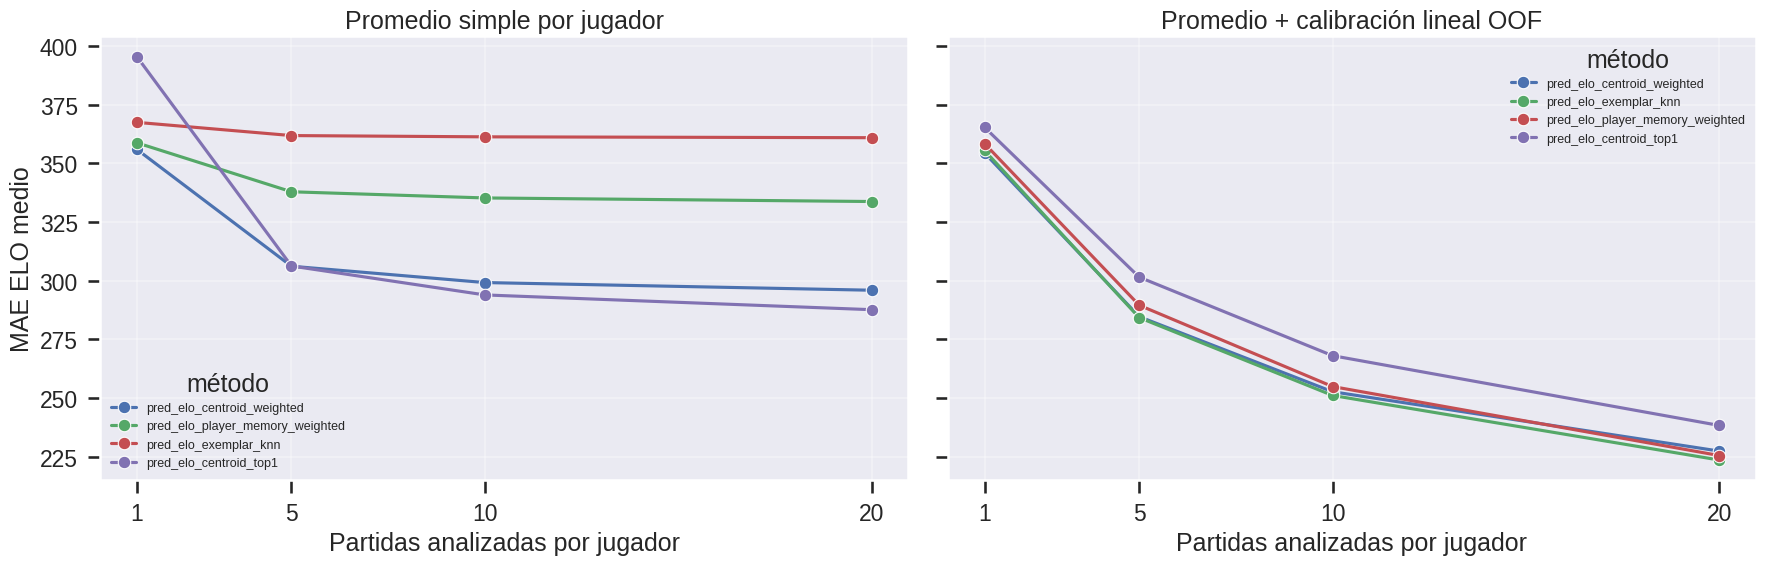

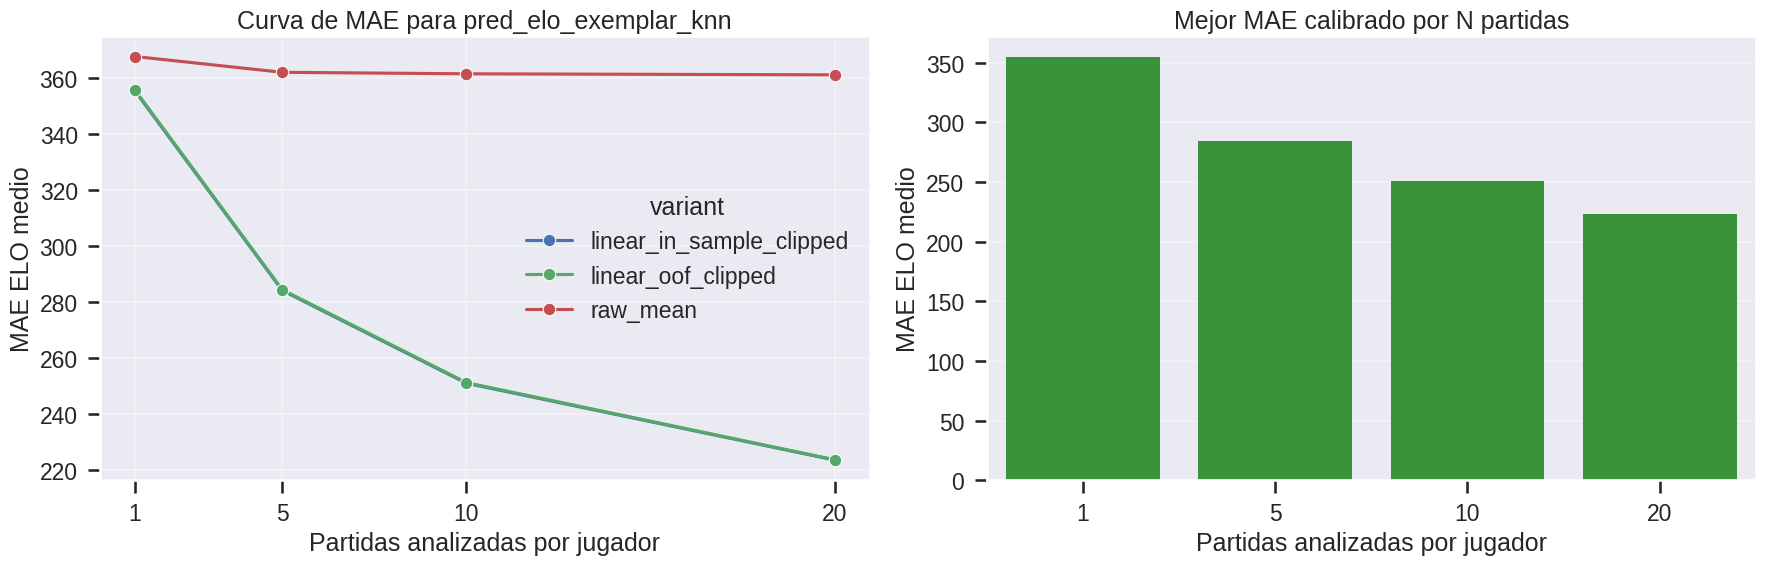

In [11]:
GAMES_PER_PLAYER_COUNTS = [1, 5, 10, 20]
GAMES_PER_PLAYER_REPEATS = {
    1: 100,
    5: 100,
    10: 100,
    20: 1,
}
GAME_COUNT_CALIBRATION_SPLITS = 5

GAMES_PER_PLAYER_METRICS_CSV_PATH = EVAL_DIR / "games_per_player_elo_metrics.csv"
GAMES_PER_PLAYER_SUMMARY_CSV_PATH = EVAL_DIR / "games_per_player_elo_summary.csv"

if "game_predictions_df" not in globals():
    if not GAME_PREDICTIONS_CSV_PATH.exists():
        raise RuntimeError(
            "No existe game_predictions_df en memoria ni game_level_predictions.csv en disco."
        )
    game_predictions_df = pd.read_csv(GAME_PREDICTIONS_CSV_PATH)

if "prediction_cols" not in globals():
    prediction_cols = [
        "pred_elo_exemplar_top1",
        "pred_elo_exemplar_knn",
        "pred_elo_player_memory_top1",
        "pred_elo_player_memory_weighted",
        "pred_elo_centroid_top1",
        "pred_elo_centroid_weighted",
    ]


def _stable_seed_from_text(text: str, base_seed: int = SEED) -> int:
    digest = hashlib.blake2b(str(text).encode("utf-8"), digest_size=4).hexdigest()
    return int(base_seed) + int(digest, 16)


def _finite_game_predictions(df: pd.DataFrame, pred_col: str) -> pd.DataFrame:
    required = ["unknown_player", "unknown_elo", pred_col]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f"Faltan columnas para {pred_col}: {missing}")

    work = df.dropna(subset=required).copy()
    mask = np.isfinite(work["unknown_elo"].to_numpy(dtype=np.float64)) & np.isfinite(
        work[pred_col].to_numpy(dtype=np.float64)
    )
    return work.loc[mask].reset_index(drop=True)


def _build_player_prediction_records(
    df: pd.DataFrame,
    pred_col: str,
) -> List[Dict[str, object]]:
    work = _finite_game_predictions(df, pred_col=pred_col)
    records: List[Dict[str, object]] = []
    for player, group in work.groupby("unknown_player", sort=True):
        values = group[pred_col].to_numpy(dtype=np.float64)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        records.append(
            {
                "unknown_player": str(player),
                "unknown_elo": float(group["unknown_elo"].iloc[0]),
                "pred_values": values,
            }
        )
    return records


def _sample_player_prediction_means_from_records(
    records: List[Dict[str, object]],
    pred_col: str,
    games_per_player: int,
    repeat_idx: int,
    seed: int = SEED,
) -> pd.DataFrame:
    method_seed = _stable_seed_from_text(pred_col, seed)
    rng = np.random.default_rng(
        method_seed + int(games_per_player) * 100_003 + int(repeat_idx) * 1_000_003
    )

    rows = []
    for record in records:
        pred_values = np.asarray(record["pred_values"], dtype=np.float64)
        if pred_values.size < games_per_player:
            continue
        selected_pos = rng.choice(
            np.arange(pred_values.size),
            size=int(games_per_player),
            replace=False,
        )
        picked_values = pred_values[selected_pos]
        rows.append(
            {
                "unknown_player": record["unknown_player"],
                "unknown_elo": float(record["unknown_elo"]),
                "games_used": int(games_per_player),
                "pred_col": pred_col,
                "repeat": int(repeat_idx),
                "pred_elo_mean_n": float(np.mean(picked_values)),
                "pred_elo_std_n": float(np.std(picked_values, ddof=0)) if len(picked_values) > 1 else 0.0,
            }
        )

    return pd.DataFrame(rows)


def _fit_linear_np(x_pred: np.ndarray, y_true: np.ndarray) -> Tuple[float, float]:
    x = np.asarray(x_pred, dtype=np.float64)
    y = np.asarray(y_true, dtype=np.float64)
    if len(x) < 2:
        raise ValueError("Se necesitan al menos 2 jugadores para calibrar.")
    X = np.column_stack([np.ones(len(x), dtype=np.float64), x])
    intercept, slope = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(intercept), float(slope)


def _apply_linear_np(x_pred: np.ndarray, intercept: float, slope: float) -> np.ndarray:
    return (float(intercept) + float(slope) * np.asarray(x_pred, dtype=np.float64)).astype(np.float32)


def _metrics_np(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float | int]:
    y = np.asarray(y_true, dtype=np.float64)
    pred = np.asarray(y_pred, dtype=np.float64)
    mask = np.isfinite(y) & np.isfinite(pred)
    y = y[mask]
    pred = pred[mask]
    if len(y) == 0:
        return {
            "n_players": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "median_ae": np.nan,
            "bias": np.nan,
            "corr": np.nan,
        }
    err = pred - y
    return {
        "n_players": int(len(y)),
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "median_ae": float(np.median(np.abs(err))),
        "bias": float(np.mean(err)),
        "corr": float(np.corrcoef(y, pred)[0, 1]) if len(y) >= 2 else np.nan,
    }


def _linear_oof_np(
    x_pred: np.ndarray,
    y_true: np.ndarray,
    n_splits: int,
    seed: int,
) -> Tuple[np.ndarray, pd.DataFrame]:
    x = np.asarray(x_pred, dtype=np.float64)
    y = np.asarray(y_true, dtype=np.float64)
    n = len(x)
    folds_count = min(max(2, int(n_splits)), n)
    rng = np.random.default_rng(seed)
    order = np.arange(n)
    rng.shuffle(order)
    folds = np.array_split(order, folds_count)

    oof = np.full(n, np.nan, dtype=np.float32)
    fold_rows = []
    all_idx = np.arange(n)
    for fold_idx, valid_idx in enumerate(folds, start=1):
        train_idx = np.setdiff1d(all_idx, valid_idx, assume_unique=False)
        intercept, slope = _fit_linear_np(x[train_idx], y[train_idx])
        oof[valid_idx] = _apply_linear_np(x[valid_idx], intercept, slope)
        row = _metrics_np(y[valid_idx], oof[valid_idx])
        row.update(
            {
                "fold": int(fold_idx),
                "intercept": float(intercept),
                "slope": float(slope),
            }
        )
        fold_rows.append(row)

    return oof, pd.DataFrame(fold_rows)


def evaluate_games_per_player_requirements(
    df: pd.DataFrame,
    methods: List[str],
    game_counts: List[int],
    repeats_by_count: Dict[int, int],
    n_splits: int = 5,
    seed: int = SEED,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    metric_rows = []
    clip_min = float(getattr(CONFIG, "elo_min", 700))
    clip_max = float(getattr(CONFIG, "elo_max", 2800))

    for pred_col in methods:
        if pred_col not in df.columns:
            print(f"Saltando {pred_col}: no existe en game_predictions_df")
            continue

        player_records = _build_player_prediction_records(df, pred_col=pred_col)
        if not player_records:
            print(f"Saltando {pred_col}: sin predicciones válidas")
            continue

        for games_per_player in game_counts:
            repeats = int(repeats_by_count.get(int(games_per_player), 50))
            for repeat_idx in range(repeats):
                sampled_df = _sample_player_prediction_means_from_records(
                    records=player_records,
                    pred_col=pred_col,
                    games_per_player=int(games_per_player),
                    repeat_idx=int(repeat_idx),
                    seed=seed,
                )
                if len(sampled_df) < 2:
                    continue

                y = sampled_df["unknown_elo"].to_numpy(dtype=np.float64)
                raw_pred = sampled_df["pred_elo_mean_n"].to_numpy(dtype=np.float64)
                intercept, slope = _fit_linear_np(raw_pred, y)
                in_sample = _apply_linear_np(raw_pred, intercept, slope)
                in_sample_clipped = np.clip(in_sample, clip_min, clip_max)
                oof_pred, _ = _linear_oof_np(
                    raw_pred,
                    y,
                    n_splits=n_splits,
                    seed=_stable_seed_from_text(
                        f"{pred_col}-{games_per_player}-{repeat_idx}",
                        seed,
                    ),
                )
                oof_clipped = np.clip(oof_pred, clip_min, clip_max)

                variants = {
                    "raw_mean": raw_pred,
                    "linear_in_sample_clipped": in_sample_clipped,
                    "linear_oof_clipped": oof_clipped,
                }
                for variant, pred_values in variants.items():
                    row = _metrics_np(y, pred_values)
                    row.update(
                        {
                            "method": pred_col,
                            "variant": variant,
                            "games_per_player": int(games_per_player),
                            "repeat": int(repeat_idx),
                            "full_fit_intercept": float(intercept),
                            "full_fit_slope": float(slope),
                        }
                    )
                    metric_rows.append(row)

    metrics_df = pd.DataFrame(metric_rows)
    if metrics_df.empty:
        raise RuntimeError("No se generaron métricas de games_per_player.")

    summary_df = (
        metrics_df.groupby(["method", "variant", "games_per_player"], as_index=False)
        .agg(
            repeats=("repeat", "nunique"),
            n_players_mean=("n_players", "mean"),
            mae_mean=("mae", "mean"),
            mae_std=("mae", "std"),
            mae_min=("mae", "min"),
            mae_max=("mae", "max"),
            rmse_mean=("rmse", "mean"),
            median_ae_mean=("median_ae", "mean"),
            bias_mean=("bias", "mean"),
            corr_mean=("corr", "mean"),
            slope_mean=("full_fit_slope", "mean"),
            intercept_mean=("full_fit_intercept", "mean"),
        )
        .sort_values(["variant", "games_per_player", "mae_mean", "method"])
        .reset_index(drop=True)
    )
    return metrics_df, summary_df


game_count_metrics_df, game_count_summary_df = evaluate_games_per_player_requirements(
    df=game_predictions_df,
    methods=prediction_cols,
    game_counts=GAMES_PER_PLAYER_COUNTS,
    repeats_by_count=GAMES_PER_PLAYER_REPEATS,
    n_splits=GAME_COUNT_CALIBRATION_SPLITS,
    seed=SEED,
)

game_count_metrics_df.to_csv(GAMES_PER_PLAYER_METRICS_CSV_PATH, index=False)
game_count_summary_df.to_csv(GAMES_PER_PLAYER_SUMMARY_CSV_PATH, index=False)

print("=" * 90)
print("CUÁNTAS PARTIDAS HACEN FALTA PARA ESTIMAR ELO")
print("=" * 90)
print(f"Métricas por repetición: {GAMES_PER_PLAYER_METRICS_CSV_PATH}")
print(f"Resumen agregado:        {GAMES_PER_PLAYER_SUMMARY_CSV_PATH}")
print("Repeticiones por N partidas:", GAMES_PER_PLAYER_REPEATS)
print("=" * 90)

raw_summary_df = (
    game_count_summary_df.loc[game_count_summary_df["variant"] == "raw_mean"]
    .sort_values(["games_per_player", "mae_mean", "method"])
    .reset_index(drop=True)
)
calibrated_summary_df = (
    game_count_summary_df.loc[game_count_summary_df["variant"] == "linear_oof_clipped"]
    .sort_values(["games_per_player", "mae_mean", "method"])
    .reset_index(drop=True)
)

best_by_count_df = (
    calibrated_summary_df.sort_values(["games_per_player", "mae_mean", "rmse_mean"])
    .groupby("games_per_player", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print("Mejor método calibrado out-of-fold por número de partidas:")
display(best_by_count_df)

print("Resumen raw mean:")
display(raw_summary_df)

print("Resumen calibrado lineal out-of-fold clipped:")
display(calibrated_summary_df)

mae_pivot_df = calibrated_summary_df.pivot_table(
    index="method",
    columns="games_per_player",
    values="mae_mean",
).sort_values(max(GAMES_PER_PLAYER_COUNTS))
print("MAE calibrado por método y número de partidas:")
display(mae_pivot_df)

plot_methods = (
    calibrated_summary_df.loc[
        calibrated_summary_df["games_per_player"] == max(GAMES_PER_PLAYER_COUNTS)
    ]
    .sort_values("mae_mean")
    .head(4)["method"]
    .tolist()
)
plot_df = game_count_summary_df.loc[
    game_count_summary_df["method"].isin(plot_methods)
    & game_count_summary_df["variant"].isin(["raw_mean", "linear_oof_clipped"])
].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for ax, variant, title in [
    (axes[0], "raw_mean", "Promedio simple por jugador"),
    (axes[1], "linear_oof_clipped", "Promedio + calibración lineal OOF"),
]:
    sns.lineplot(
        data=plot_df.loc[plot_df["variant"] == variant],
        x="games_per_player",
        y="mae_mean",
        hue="method",
        marker="o",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Partidas analizadas por jugador")
    ax.set_ylabel("MAE ELO medio")
    ax.set_xticks(GAMES_PER_PLAYER_COUNTS)
    ax.grid(True, alpha=0.3)
    ax.legend(title="método", fontsize=9)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
best_method = str(best_by_count_df.iloc[-1]["method"])
best_method_df = game_count_summary_df.loc[
    game_count_summary_df["method"] == best_method
].copy()

sns.lineplot(
    data=best_method_df,
    x="games_per_player",
    y="mae_mean",
    hue="variant",
    marker="o",
    ax=axes[0],
)
axes[0].set_title(f"Curva de MAE para {best_method}")
axes[0].set_xlabel("Partidas analizadas por jugador")
axes[0].set_ylabel("MAE ELO medio")
axes[0].set_xticks(GAMES_PER_PLAYER_COUNTS)
axes[0].grid(True, alpha=0.3)

sns.barplot(
    data=best_by_count_df,
    x="games_per_player",
    y="mae_mean",
    color="tab:green",
    ax=axes[1],
)
axes[1].set_title("Mejor MAE calibrado por N partidas")
axes[1].set_xlabel("Partidas analizadas por jugador")
axes[1].set_ylabel("MAE ELO medio")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


TRAYECTORIA POR JUGADOR SEGÚN N PARTIDAS
Método usado:       pred_elo_exemplar_knn
Calibración usada: linear_oof_clipped
CSV:               /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/player_elo_trajectory_by_games.csv


,games_per_player,players,mae,median_ae,rmse,pred_elo_mean
0,1,2000,353.684310,325.331848,421.956306,1491.715210
1,5,2000,287.373390,250.288147,351.113818,1492.111694
2,10,2000,254.455772,220.253235,316.644728,1492.600342
3,20,2000,224.003893,189.960205,281.190267,1493.291992


,unknown_player,unknown_elo,method,games_per_player,pred_elo_raw,pred_elo_plot,calibration,abs_error_plot
0,ABOHADI77,948.0,pred_elo_exemplar_knn,1,1395.213100,1257.184448,linear_oof_clipped,309.184448
1,ABOHADI77,948.0,pred_elo_exemplar_knn,5,1410.416720,914.391235,linear_oof_clipped,33.608765
2,ABOHADI77,948.0,pred_elo_exemplar_knn,10,1457.798690,983.875366,linear_oof_clipped,35.875366
3,ABOHADI77,948.0,pred_elo_exemplar_knn,20,1470.806560,983.608215,linear_oof_clipped,35.608215
4,ABotvinnik10,1702.0,pred_elo_exemplar_knn,1,1494.675900,1406.964355,linear_oof_clipped,295.035645
5,ABotvinnik10,1702.0,pred_elo_exemplar_knn,5,1555.150100,1517.944092,linear_oof_clipped,184.055908
6,ABotvinnik10,1702.0,pred_elo_exemplar_knn,10,1620.032920,1878.293091,linear_oof_clipped,176.293091
7,ABotvinnik10,1702.0,pred_elo_exemplar_knn,20,1597.813945,1807.166382,linear_oof_clipped,105.166382
8,ACPoso82_NSamar,2203.0,pred_elo_exemplar_knn,1,1760.793500,1806.353638,linear_oof_clipped,396.646362
9,ACPoso82_NSamar,2203.0,pred_elo_exemplar_knn,5,1652.171120,1937.562134,linear_oof_clipped,265.437866


/tmp/ipykernel_143/893878011.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


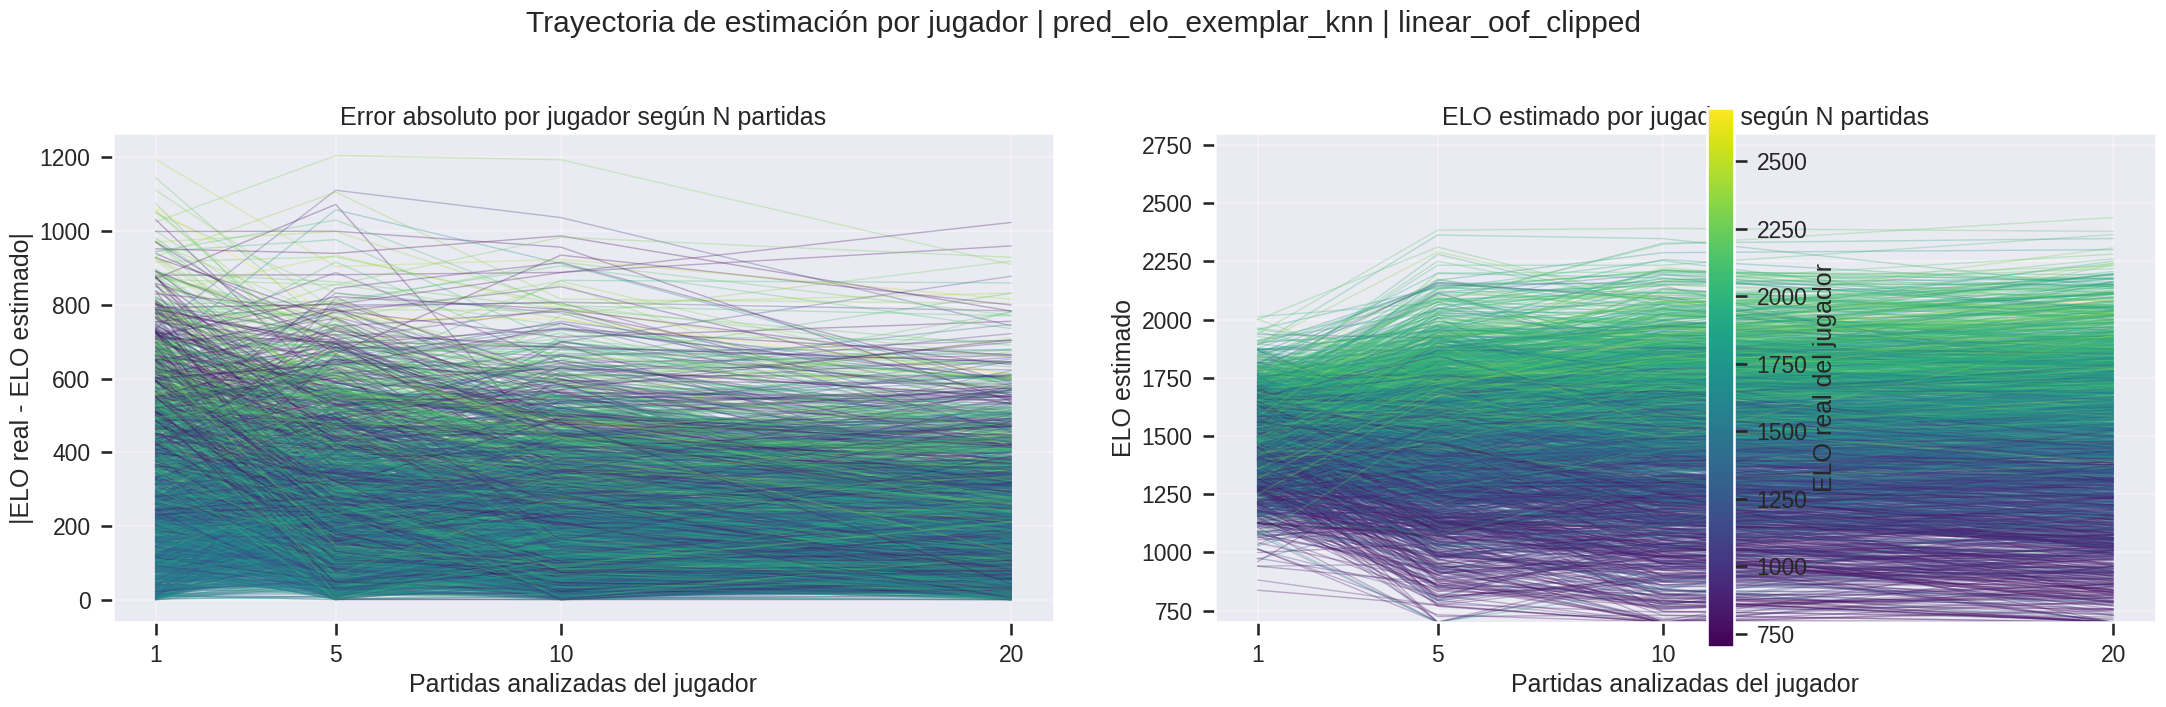

In [12]:
PLAYER_TRAJECTORY_GAME_COUNTS = [1, 5, 10, 20]
PLAYER_TRAJECTORY_OUTPUT_CSV_PATH = EVAL_DIR / "player_elo_trajectory_by_games.csv"

if "game_predictions_df" not in globals():
    if not GAME_PREDICTIONS_CSV_PATH.exists():
        raise RuntimeError(
            "No existe game_predictions_df en memoria ni game_level_predictions.csv en disco."
        )
    game_predictions_df = pd.read_csv(GAME_PREDICTIONS_CSV_PATH)

if "prediction_cols" not in globals():
    prediction_cols = [
        "pred_elo_exemplar_top1",
        "pred_elo_exemplar_knn",
        "pred_elo_player_memory_top1",
        "pred_elo_player_memory_weighted",
        "pred_elo_centroid_top1",
        "pred_elo_centroid_weighted",
    ]

if "best_by_count_df" in globals() and not best_by_count_df.empty:
    PLAYER_TRAJECTORY_METHOD = str(
        best_by_count_df.sort_values("games_per_player").iloc[-1]["method"]
    )
else:
    PLAYER_TRAJECTORY_METHOD = (
        "pred_elo_exemplar_knn"
        if "pred_elo_exemplar_knn" in game_predictions_df.columns
        else prediction_cols[0]
    )

PLAYER_TRAJECTORY_USE_OOF_LINEAR = True


def _trajectory_seed(text: str, base_seed: int = SEED) -> int:
    digest = hashlib.blake2b(str(text).encode("utf-8"), digest_size=4).hexdigest()
    return int(base_seed) + int(digest, 16)


def _trajectory_fit_linear(x_pred: np.ndarray, y_true: np.ndarray) -> Tuple[float, float]:
    x = np.asarray(x_pred, dtype=np.float64)
    y = np.asarray(y_true, dtype=np.float64)
    X = np.column_stack([np.ones(len(x), dtype=np.float64), x])
    intercept, slope = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(intercept), float(slope)


def _trajectory_oof_linear(
    x_pred: np.ndarray,
    y_true: np.ndarray,
    n_splits: int = 5,
    seed: int = SEED,
) -> np.ndarray:
    x = np.asarray(x_pred, dtype=np.float64)
    y = np.asarray(y_true, dtype=np.float64)
    n = len(x)
    folds_count = min(max(2, int(n_splits)), n)
    rng = np.random.default_rng(seed)
    order = np.arange(n)
    rng.shuffle(order)
    folds = np.array_split(order, folds_count)
    out = np.full(n, np.nan, dtype=np.float32)
    all_idx = np.arange(n)
    for valid_idx in folds:
        train_idx = np.setdiff1d(all_idx, valid_idx, assume_unique=False)
        intercept, slope = _trajectory_fit_linear(x[train_idx], y[train_idx])
        out[valid_idx] = intercept + slope * x[valid_idx]
    return out


def build_player_elo_trajectory_plot_df(
    df: pd.DataFrame,
    pred_col: str,
    game_counts: List[int],
    use_oof_linear: bool = True,
) -> pd.DataFrame:
    required = ["unknown_player", "unknown_elo", pred_col]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f"Faltan columnas: {missing}")

    work = df.dropna(subset=required).copy()
    mask = np.isfinite(work["unknown_elo"].to_numpy(dtype=np.float64)) & np.isfinite(
        work[pred_col].to_numpy(dtype=np.float64)
    )
    work = work.loc[mask].reset_index(drop=True)

    rows = []
    sort_cols = ["game_index"] if "game_index" in work.columns else None
    for player, group in work.groupby("unknown_player", sort=True):
        if sort_cols:
            group = group.sort_values(sort_cols)
        values = group[pred_col].to_numpy(dtype=np.float64)
        rng = np.random.default_rng(_trajectory_seed(f"{pred_col}-{player}"))
        order = rng.permutation(len(values))
        values = values[order]
        true_elo = float(group["unknown_elo"].iloc[0])
        for n_games in game_counts:
            if len(values) < int(n_games):
                continue
            pred_raw = float(np.mean(values[: int(n_games)]))
            rows.append(
                {
                    "unknown_player": str(player),
                    "unknown_elo": true_elo,
                    "method": pred_col,
                    "games_per_player": int(n_games),
                    "pred_elo_raw": pred_raw,
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        raise RuntimeError("No se pudo construir la trayectoria por jugador.")

    out["pred_elo_plot"] = out["pred_elo_raw"].astype(np.float32)
    out["calibration"] = "raw_mean"
    if use_oof_linear:
        clip_min = float(getattr(CONFIG, "elo_min", 700))
        clip_max = float(getattr(CONFIG, "elo_max", 2800))
        for n_games, sub in out.groupby("games_per_player", sort=True):
            idx = sub.index.to_numpy()
            x = sub["pred_elo_raw"].to_numpy(dtype=np.float64)
            y = sub["unknown_elo"].to_numpy(dtype=np.float64)
            pred = _trajectory_oof_linear(
                x,
                y,
                n_splits=5,
                seed=_trajectory_seed(f"trajectory-{pred_col}-{n_games}"),
            )
            out.loc[idx, "pred_elo_plot"] = np.clip(pred, clip_min, clip_max)
        out["calibration"] = "linear_oof_clipped"

    out["abs_error_plot"] = (
        out["pred_elo_plot"].astype(float) - out["unknown_elo"].astype(float)
    ).abs()
    return out.sort_values(["unknown_player", "games_per_player"]).reset_index(drop=True)


player_elo_trajectory_df = build_player_elo_trajectory_plot_df(
    df=game_predictions_df,
    pred_col=PLAYER_TRAJECTORY_METHOD,
    game_counts=PLAYER_TRAJECTORY_GAME_COUNTS,
    use_oof_linear=PLAYER_TRAJECTORY_USE_OOF_LINEAR,
)
player_elo_trajectory_df.to_csv(PLAYER_TRAJECTORY_OUTPUT_CSV_PATH, index=False)

trajectory_summary_df = (
    player_elo_trajectory_df.groupby("games_per_player", as_index=False)
    .agg(
        players=("unknown_player", "nunique"),
        mae=("abs_error_plot", "mean"),
        median_ae=("abs_error_plot", "median"),
        rmse=("abs_error_plot", lambda s: float(np.sqrt(np.mean(np.square(s))))),
        pred_elo_mean=("pred_elo_plot", "mean"),
    )
    .sort_values("games_per_player")
    .reset_index(drop=True)
)

print("=" * 90)
print("TRAYECTORIA POR JUGADOR SEGÚN N PARTIDAS")
print("=" * 90)
print(f"Método usado:       {PLAYER_TRAJECTORY_METHOD}")
print(f"Calibración usada: {player_elo_trajectory_df['calibration'].iloc[0]}")
print(f"CSV:               {PLAYER_TRAJECTORY_OUTPUT_CSV_PATH}")
print("=" * 90)
display(trajectory_summary_df)
display(player_elo_trajectory_df.head(20))

import matplotlib as mpl

plot_df = player_elo_trajectory_df.copy()
elo_min = float(plot_df["unknown_elo"].min())
elo_max = float(plot_df["unknown_elo"].max())
norm = mpl.colors.Normalize(vmin=elo_min, vmax=elo_max)
cmap = plt.get_cmap("viridis")

fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharex=True)
for _, player_df in plot_df.groupby("unknown_player", sort=False):
    player_df = player_df.sort_values("games_per_player")
    color = cmap(norm(float(player_df["unknown_elo"].iloc[0])))
    axes[0].plot(
        player_df["games_per_player"],
        player_df["abs_error_plot"],
        color=color,
        alpha=0.30,
        linewidth=1.0,
    )
    axes[1].plot(
        player_df["games_per_player"],
        player_df["pred_elo_plot"],
        color=color,
        alpha=0.30,
        linewidth=1.0,
    )

axes[0].set_title("Error absoluto por jugador según N partidas")
axes[0].set_xlabel("Partidas analizadas del jugador")
axes[0].set_ylabel("|ELO real - ELO estimado|")
axes[0].set_xticks(PLAYER_TRAJECTORY_GAME_COUNTS)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("ELO estimado por jugador según N partidas")
axes[1].set_xlabel("Partidas analizadas del jugador")
axes[1].set_ylabel("ELO estimado")
axes[1].set_xticks(PLAYER_TRAJECTORY_GAME_COUNTS)
axes[1].set_ylim(
    float(getattr(CONFIG, "elo_min", max(400, elo_min - 100))),
    float(getattr(CONFIG, "elo_max", elo_max + 100)),
)
axes[1].grid(True, alpha=0.3)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=axes.ravel().tolist(), label="ELO real del jugador")
fig.suptitle(
    f"Trayectoria de estimación por jugador | {PLAYER_TRAJECTORY_METHOD} | "
    f"{plot_df['calibration'].iloc[0]}",
    y=1.02,
)

plt.tight_layout()
plt.show()


## Búsqueda de grupos estilométricos con PCA/t-SNE

Esta sección intenta responder una pregunta distinta a `jugador_i -> jugador_p`: si el embedding no separa identidades individuales con suficiente precisión, quizá sí separa **grupos de estilo**. No se reentrena el modelo.

Importante: t-SNE se usa como visualización, no como clasificador. Los grupos se buscan con KMeans sobre centroides de jugador en el espacio de embedding/PCA, y luego se pintan en t-SNE. Para jugadores no vistos, si no guardamos sus embeddings, se les asigna grupo por voto usando los jugadores conocidos predichos por los métodos ya calculados (`pred_player_memory_top1`, `pred_centroid_top1`, `pred_player_exemplar_top1`).


BÚSQUEDA DE GRUPOS ESTILOMÉTRICOS PCA/t-SNE
Jugadores de referencia: 200
PCA components usados para t-SNE: 50
PCA components usados para clustering: 30
Perplexity t-SNE: 30.00
K elegido: 2
CSV búsqueda K: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/tsne_style_cluster_search.csv
CSV clusters referencia: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/tsne_style_reference_player_clusters.csv
CSV grupos open-set: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/tsne_style_unknown_group_predictions.csv


,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,0.008912,0.234463,1.480407,83.980331
1,3,0.007734,0.181372,1.620982,63.146050
2,4,0.007177,0.122228,2.055689,50.201112
3,5,0.006723,0.119313,1.964793,43.286218
9,11,0.005527,0.099879,1.917414,24.501017
20,22,0.004411,0.099425,1.644513,15.912350
4,6,0.006462,0.097949,2.072005,37.404498
5,7,0.006240,0.096170,2.061549,33.263499
14,16,0.005008,0.095487,1.827099,18.819402
7,9,0.005825,0.093230,1.966370,28.147504


,style_group,players,mean_elo,median_elo,min_elo,max_elo,elo_std
0,0,103,1348.776733,1319.0,638.0,2297.0,324.514343
1,1,97,1706.927856,1722.0,856.0,2271.0,280.275177


,player,label,elo,style_group,tsne_x,tsne_y,pca_1,pca_2
147,manuelkevogo,147,638.0,0,2.742013,10.630024,-0.008786,-0.001209
67,ROkkk45,67,647.0,0,4.144561,8.845076,-0.004309,-0.001634
198,youcef7112,198,716.0,0,3.482187,11.576099,-0.010027,-0.003092
128,hmzaydn,128,734.0,0,1.753594,12.791758,-0.009647,-0.001858
150,marwanabd,150,770.0,0,2.034372,11.062407,-0.011551,-0.000160
31,GErmaNnadIY_333,31,847.0,0,3.873017,8.535183,-0.002912,-0.000290
106,cavaddruf3,106,878.0,0,1.064544,11.689220,-0.012866,-0.002943
55,MarkusMake,55,908.0,0,3.490096,10.907607,-0.009569,0.002568
144,looseasagoosearms76,144,919.0,0,5.515151,4.012376,-0.006198,-0.004900
151,mathieuCham,151,941.0,0,0.540639,12.408526,-0.015886,-0.004009


,unknown_player,unknown_elo,pred_style_group,group_vote_confidence,group_votes,pred_group_mean_elo,abs_error_group_mean_elo,vote_columns
936,Theknigh,1707.0,1,0.683333,60,1706.927856,0.072144,"pred_player_memory_top1, pred_centroid_top1, p..."
991,Villamor155,1707.0,1,0.650000,60,1706.927856,0.072144,"pred_player_memory_top1, pred_centroid_top1, p..."
506,KarsangRang,1348.0,0,0.516667,60,1348.776733,0.776733,"pred_player_memory_top1, pred_centroid_top1, p..."
1451,ivandrago311079,1706.0,1,0.900000,60,1706.927856,0.927856,"pred_player_memory_top1, pred_centroid_top1, p..."
1196,brkgs,1706.0,1,0.683333,60,1706.927856,0.927856,"pred_player_memory_top1, pred_centroid_top1, p..."
1639,moelgabry,1706.0,1,0.566667,60,1706.927856,0.927856,"pred_player_memory_top1, pred_centroid_top1, p..."
1313,ennzomalgrat2309,1706.0,1,0.550000,60,1706.927856,0.927856,"pred_player_memory_top1, pred_centroid_top1, p..."
1594,marcellius2015,1350.0,0,0.633333,60,1348.776733,1.223267,"pred_player_memory_top1, pred_centroid_top1, p..."
1995,zlate,1705.0,1,0.600000,60,1706.927856,1.927856,"pred_player_memory_top1, pred_centroid_top1, p..."
1731,papaP999,1705.0,1,0.533333,60,1706.927856,1.927856,"pred_player_memory_top1, pred_centroid_top1, p..."


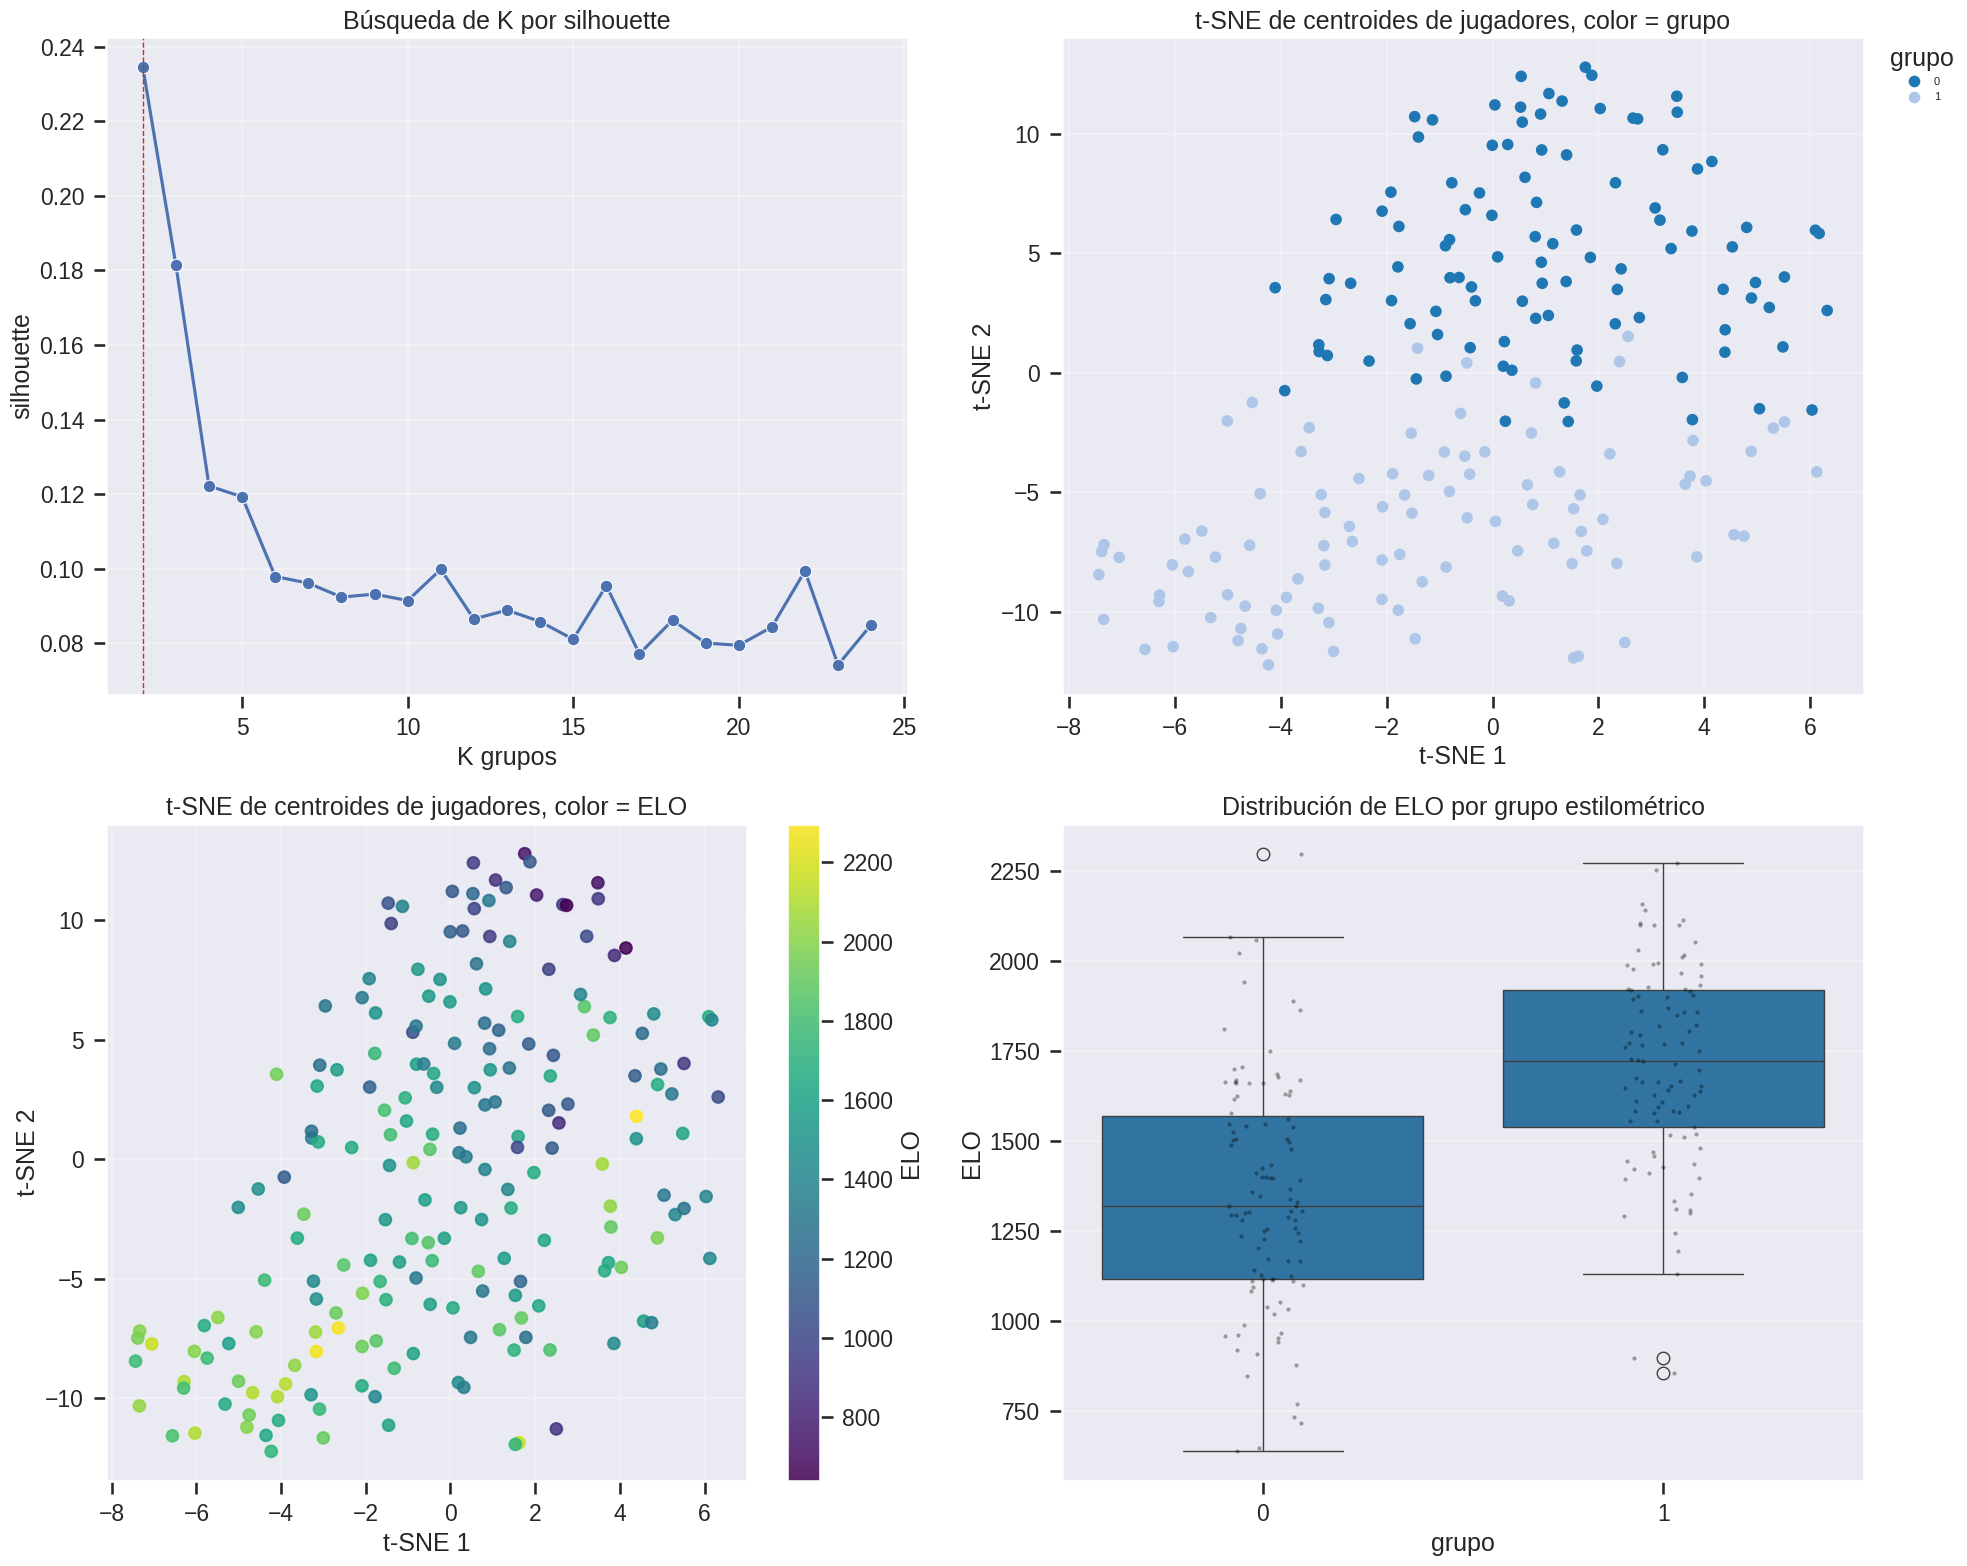

,pred_style_group,unknown_players,mean_unknown_elo,median_unknown_elo,mean_vote_confidence,mean_abs_error_group_mean_elo
0,0,1035,1218.373913,1152.0,0.646184,328.194590
1,1,965,1785.054922,1845.0,0.631278,306.932595


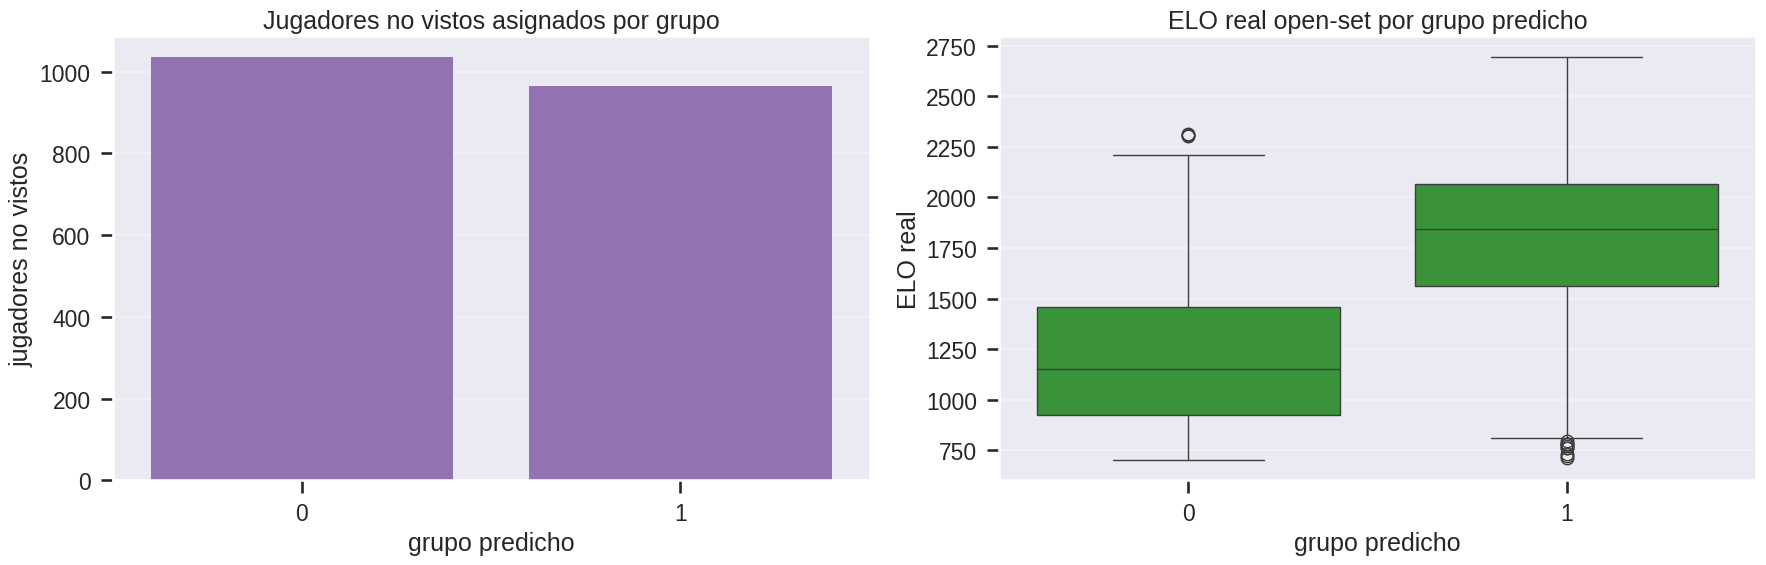

In [13]:
TSNE_STYLE_FORCE_K = None  # Ejemplo: 8 para fijar manualmente el número de grupos.
TSNE_STYLE_K_MIN = 2
TSNE_STYLE_K_MAX = 24
TSNE_STYLE_PCA_COMPONENTS = 50
TSNE_STYLE_CLUSTER_PCA_COMPONENTS = 30
TSNE_STYLE_PERPLEXITY = 30
TSNE_STYLE_RANDOM_STATE = SEED

TSNE_STYLE_CLUSTER_SEARCH_CSV_PATH = EVAL_DIR / "tsne_style_cluster_search.csv"
TSNE_STYLE_REFERENCE_CLUSTERS_CSV_PATH = EVAL_DIR / "tsne_style_reference_player_clusters.csv"
TSNE_STYLE_UNKNOWN_GROUPS_CSV_PATH = EVAL_DIR / "tsne_style_unknown_group_predictions.csv"

try:
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.metrics import (
        calinski_harabasz_score,
        davies_bouldin_score,
        silhouette_score,
    )
except Exception as exc:
    raise RuntimeError(
        "Esta celda necesita scikit-learn para PCA/t-SNE/KMeans. "
        "Instálalo en el kernel del notebook o ejecuta en un entorno que ya lo tenga."
    ) from exc

if "reference_players" not in globals():
    raise RuntimeError("Falta reference_players. Ejecuta primero las celdas de carga/reconstrucción de memoria.")

if "centroid_matrix" in globals():
    player_embedding_matrix = np.asarray(centroid_matrix, dtype=np.float32)
elif "train_embeddings" in globals() and "train_labels" in globals():
    player_embedding_matrix = []
    for class_idx in range(len(reference_players)):
        class_emb = train_embeddings[np.asarray(train_labels) == class_idx]
        if class_emb.size == 0:
            raise RuntimeError(f"Sin embeddings TRAIN para clase {class_idx}.")
        centroid = class_emb.mean(axis=0)
        centroid = centroid / np.clip(np.linalg.norm(centroid), 1e-8, None)
        player_embedding_matrix.append(centroid)
    player_embedding_matrix = np.vstack(player_embedding_matrix).astype(np.float32)
else:
    raise RuntimeError("Falta centroid_matrix o train_embeddings/train_labels. No se puede buscar grupos.")

player_embedding_matrix = np.asarray(player_embedding_matrix, dtype=np.float32)
player_embedding_matrix = player_embedding_matrix / np.clip(
    np.linalg.norm(player_embedding_matrix, axis=1, keepdims=True),
    1e-8,
    None,
)

if "reference_player_elos" in globals():
    ref_elos = np.asarray(reference_player_elos, dtype=np.float32)
else:
    ref_elos = np.array(
        [PLAYER_ELO.get(player, np.nan) for player in reference_players],
        dtype=np.float32,
    )

n_players = len(reference_players)
pca_components = min(
    int(TSNE_STYLE_PCA_COMPONENTS),
    player_embedding_matrix.shape[1],
    max(2, n_players - 1),
)
pca_model = PCA(n_components=pca_components, random_state=TSNE_STYLE_RANDOM_STATE)
player_pca = pca_model.fit_transform(player_embedding_matrix)

cluster_components = min(
    int(TSNE_STYLE_CLUSTER_PCA_COMPONENTS),
    player_pca.shape[1],
)
cluster_features = player_pca[:, :cluster_components]

k_max = min(int(TSNE_STYLE_K_MAX), n_players - 1)
k_values = list(range(int(TSNE_STYLE_K_MIN), k_max + 1))
cluster_search_rows = []
cluster_labels_by_k = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=int(k),
        random_state=TSNE_STYLE_RANDOM_STATE,
        n_init=25,
    )
    labels = kmeans.fit_predict(cluster_features)
    cluster_labels_by_k[int(k)] = labels

    row = {
        "k": int(k),
        "inertia": float(kmeans.inertia_),
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
    }
    if len(np.unique(labels)) > 1 and len(np.unique(labels)) < len(labels):
        row["silhouette"] = float(silhouette_score(cluster_features, labels))
        row["davies_bouldin"] = float(davies_bouldin_score(cluster_features, labels))
        row["calinski_harabasz"] = float(calinski_harabasz_score(cluster_features, labels))
    cluster_search_rows.append(row)

style_cluster_search_df = pd.DataFrame(cluster_search_rows)
style_cluster_search_df.to_csv(TSNE_STYLE_CLUSTER_SEARCH_CSV_PATH, index=False)

if TSNE_STYLE_FORCE_K is not None:
    best_style_k = int(TSNE_STYLE_FORCE_K)
else:
    best_style_k = int(
        style_cluster_search_df.sort_values(
            ["silhouette", "calinski_harabasz", "davies_bouldin"],
            ascending=[False, False, True],
        ).iloc[0]["k"]
    )

style_labels = cluster_labels_by_k[best_style_k]
# Reetiqueta por ELO medio ascendente para que grupo 0 tienda a menor ELO si hay señal.
cluster_order_df = pd.DataFrame({"cluster_raw": style_labels, "elo": ref_elos})
cluster_order_df = (
    cluster_order_df.groupby("cluster_raw", as_index=False)
    .agg(mean_elo=("elo", "mean"), players=("elo", "size"))
    .sort_values(["mean_elo", "cluster_raw"])
    .reset_index(drop=True)
)
cluster_raw_to_group = {
    int(row.cluster_raw): int(idx)
    for idx, row in cluster_order_df.iterrows()
}
style_groups = np.array([cluster_raw_to_group[int(label)] for label in style_labels], dtype=np.int32)

perplexity = min(float(TSNE_STYLE_PERPLEXITY), max(5.0, (n_players - 1) / 3.0))
perplexity = min(perplexity, float(n_players - 1))

tsne_kwargs = dict(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=TSNE_STYLE_RANDOM_STATE,
    metric="euclidean",
)
try:
    tsne_model = TSNE(max_iter=1500, **tsne_kwargs)
except TypeError:
    tsne_model = TSNE(n_iter=1500, **tsne_kwargs)

player_tsne = tsne_model.fit_transform(player_pca)

style_reference_cluster_df = pd.DataFrame(
    {
        "player": reference_players,
        "label": np.arange(n_players, dtype=np.int32),
        "elo": ref_elos,
        "style_group": style_groups,
        "tsne_x": player_tsne[:, 0],
        "tsne_y": player_tsne[:, 1],
        "pca_1": player_pca[:, 0],
        "pca_2": player_pca[:, 1] if player_pca.shape[1] > 1 else 0.0,
    }
)
style_reference_cluster_df.to_csv(TSNE_STYLE_REFERENCE_CLUSTERS_CSV_PATH, index=False)

style_group_summary_df = (
    style_reference_cluster_df.groupby("style_group", as_index=False)
    .agg(
        players=("player", "count"),
        mean_elo=("elo", "mean"),
        median_elo=("elo", "median"),
        min_elo=("elo", "min"),
        max_elo=("elo", "max"),
        elo_std=("elo", "std"),
    )
    .sort_values("style_group")
    .reset_index(drop=True)
)

player_to_style_group = dict(
    zip(style_reference_cluster_df["player"], style_reference_cluster_df["style_group"])
)
style_group_to_mean_elo = dict(
    zip(style_group_summary_df["style_group"], style_group_summary_df["mean_elo"])
)

# Centroides de grupo en el embedding original, útiles para clasificar nuevas partidas si tenemos embeddings.
style_group_centroids = []
style_group_ids = sorted(style_reference_cluster_df["style_group"].unique().tolist())
for group_id in style_group_ids:
    mask = style_reference_cluster_df["style_group"].to_numpy() == group_id
    centroid = player_embedding_matrix[mask].mean(axis=0)
    centroid = centroid / np.clip(np.linalg.norm(centroid), 1e-8, None)
    style_group_centroids.append(centroid)
style_group_centroids = np.vstack(style_group_centroids).astype(np.float32)
style_group_ids = np.array(style_group_ids, dtype=np.int32)


def predict_style_group_from_embeddings(
    embeddings: np.ndarray,
    top_k: int = 5,
) -> pd.DataFrame:
    emb = np.asarray(embeddings, dtype=np.float32)
    if emb.ndim == 1:
        emb = emb[None, :]
    emb = emb / np.clip(np.linalg.norm(emb, axis=1, keepdims=True), 1e-8, None)
    sims = np.clip(emb @ style_group_centroids.T, -1.0, 1.0)
    dists = np.sqrt(np.maximum(2.0 - 2.0 * sims, 0.0) + 1e-12)
    mean_dists = dists.mean(axis=0)
    order = np.argsort(mean_dists)[: max(1, int(top_k))]
    return pd.DataFrame(
        {
            "rank": np.arange(1, len(order) + 1),
            "style_group": style_group_ids[order],
            "distance": mean_dists[order],
            "group_mean_elo": [style_group_to_mean_elo.get(int(g), np.nan) for g in style_group_ids[order]],
            "group_players": [
                int(style_group_summary_df.loc[style_group_summary_df["style_group"] == int(g), "players"].iloc[0])
                for g in style_group_ids[order]
            ],
        }
    )


def predict_style_group_from_pgn(
    pgn_path: Path,
    game_index: int = 1,
    side: str = "white",
    top_k: int = 5,
) -> pd.DataFrame:
    if "_embed_game_from_pgn" not in globals():
        raise RuntimeError("Falta _embed_game_from_pgn. Ejecuta la celda de helpers de inferencia antes.")
    emb = _embed_game_from_pgn(Path(pgn_path), game_index=game_index, side=side)
    return predict_style_group_from_embeddings(emb, top_k=top_k)

unknown_style_group_df = pd.DataFrame()
if "game_predictions_df" in globals() or GAME_PREDICTIONS_CSV_PATH.exists():
    if "game_predictions_df" not in globals():
        game_predictions_df = pd.read_csv(GAME_PREDICTIONS_CSV_PATH)

    vote_columns = [
        col
        for col in ["pred_player_memory_top1", "pred_centroid_top1", "pred_player_exemplar_top1"]
        if col in game_predictions_df.columns
    ]
    unknown_rows = []
    for player, group in game_predictions_df.groupby("unknown_player", sort=True):
        votes = []
        for col in vote_columns:
            for predicted_player in group[col].dropna().astype(str):
                if predicted_player in player_to_style_group:
                    votes.append(int(player_to_style_group[predicted_player]))
        if not votes:
            continue
        vote_counts = pd.Series(votes).value_counts().sort_values(ascending=False)
        pred_group = int(vote_counts.index[0])
        confidence = float(vote_counts.iloc[0] / max(1, len(votes)))
        true_elo = float(group["unknown_elo"].iloc[0]) if "unknown_elo" in group else np.nan
        group_mean_elo = float(style_group_to_mean_elo.get(pred_group, np.nan))
        unknown_rows.append(
            {
                "unknown_player": str(player),
                "unknown_elo": true_elo,
                "pred_style_group": pred_group,
                "group_vote_confidence": confidence,
                "group_votes": int(len(votes)),
                "pred_group_mean_elo": group_mean_elo,
                "abs_error_group_mean_elo": abs(group_mean_elo - true_elo) if np.isfinite(true_elo) else np.nan,
                "vote_columns": ", ".join(vote_columns),
            }
        )
    unknown_style_group_df = pd.DataFrame(unknown_rows)
    if not unknown_style_group_df.empty:
        unknown_style_group_df.to_csv(TSNE_STYLE_UNKNOWN_GROUPS_CSV_PATH, index=False)

print("=" * 90)
print("BÚSQUEDA DE GRUPOS ESTILOMÉTRICOS PCA/t-SNE")
print("=" * 90)
print(f"Jugadores de referencia: {n_players}")
print(f"PCA components usados para t-SNE: {pca_components}")
print(f"PCA components usados para clustering: {cluster_components}")
print(f"Perplexity t-SNE: {perplexity:.2f}")
print(f"K elegido: {best_style_k}")
print(f"CSV búsqueda K: {TSNE_STYLE_CLUSTER_SEARCH_CSV_PATH}")
print(f"CSV clusters referencia: {TSNE_STYLE_REFERENCE_CLUSTERS_CSV_PATH}")
if not unknown_style_group_df.empty:
    print(f"CSV grupos open-set: {TSNE_STYLE_UNKNOWN_GROUPS_CSV_PATH}")
print("=" * 90)

display(style_cluster_search_df.sort_values("silhouette", ascending=False).head(10))
display(style_group_summary_df)
display(style_reference_cluster_df.sort_values(["style_group", "elo", "player"]).head(30))
if not unknown_style_group_df.empty:
    display(unknown_style_group_df.sort_values("abs_error_group_mean_elo").head(30))

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

sns.lineplot(
    data=style_cluster_search_df,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].axvline(best_style_k, color="tab:red", linestyle="--", linewidth=1)
axes[0, 0].set_title("Búsqueda de K por silhouette")
axes[0, 0].set_xlabel("K grupos")
axes[0, 0].set_ylabel("silhouette")
axes[0, 0].grid(True, alpha=0.3)

sns.scatterplot(
    data=style_reference_cluster_df,
    x="tsne_x",
    y="tsne_y",
    hue="style_group",
    palette="tab20",
    s=70,
    linewidth=0,
    ax=axes[0, 1],
)
axes[0, 1].set_title("t-SNE de centroides de jugadores, color = grupo")
axes[0, 1].set_xlabel("t-SNE 1")
axes[0, 1].set_ylabel("t-SNE 2")
axes[0, 1].grid(True, alpha=0.25)
axes[0, 1].legend(title="grupo", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

scatter = axes[1, 0].scatter(
    style_reference_cluster_df["tsne_x"],
    style_reference_cluster_df["tsne_y"],
    c=style_reference_cluster_df["elo"],
    cmap="viridis",
    s=70,
    alpha=0.85,
)
axes[1, 0].set_title("t-SNE de centroides de jugadores, color = ELO")
axes[1, 0].set_xlabel("t-SNE 1")
axes[1, 0].set_ylabel("t-SNE 2")
axes[1, 0].grid(True, alpha=0.25)
fig.colorbar(scatter, ax=axes[1, 0], label="ELO")

sns.boxplot(
    data=style_reference_cluster_df,
    x="style_group",
    y="elo",
    color="tab:blue",
    ax=axes[1, 1],
)
sns.stripplot(
    data=style_reference_cluster_df,
    x="style_group",
    y="elo",
    color="black",
    alpha=0.35,
    size=3,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Distribución de ELO por grupo estilométrico")
axes[1, 1].set_xlabel("grupo")
axes[1, 1].set_ylabel("ELO")
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

if not unknown_style_group_df.empty:
    unknown_group_summary_df = (
        unknown_style_group_df.groupby("pred_style_group", as_index=False)
        .agg(
            unknown_players=("unknown_player", "count"),
            mean_unknown_elo=("unknown_elo", "mean"),
            median_unknown_elo=("unknown_elo", "median"),
            mean_vote_confidence=("group_vote_confidence", "mean"),
            mean_abs_error_group_mean_elo=("abs_error_group_mean_elo", "mean"),
        )
        .sort_values("pred_style_group")
        .reset_index(drop=True)
    )
    display(unknown_group_summary_df)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.countplot(
        data=unknown_style_group_df,
        x="pred_style_group",
        color="tab:purple",
        ax=axes[0],
    )
    axes[0].set_title("Jugadores no vistos asignados por grupo")
    axes[0].set_xlabel("grupo predicho")
    axes[0].set_ylabel("jugadores no vistos")
    axes[0].grid(True, axis="y", alpha=0.3)

    sns.boxplot(
        data=unknown_style_group_df,
        x="pred_style_group",
        y="unknown_elo",
        color="tab:green",
        ax=axes[1],
    )
    axes[1].set_title("ELO real open-set por grupo predicho")
    axes[1].set_xlabel("grupo predicho")
    axes[1].set_ylabel("ELO real")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


## t-SNE de partidas y clusters estilométricos de partida

Esta sección baja del nivel jugador al nivel partida: cada punto es una partida embebida por el modelo. La clasificación que se obtiene aquí es no supervisada: KMeans busca grupos en PCA/embedding y t-SNE solo los visualiza. Esto puede revelar diferencias de estilo que no sean simplemente ELO, como familias de posiciones, estabilidad intra-jugador o tipos de decisión que el embedding considera parecidos.


Partidas visualizadas: 4000
K elegido para clusters de partida: 2
Perplexity t-SNE usada: 35.0
CSV búsqueda K: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/tsne_game_cluster_search.csv
CSV proyección partidas: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/tsne_game_embeddings_projection.csv
CSV resumen clusters: /workspace/code/labs/notebooks/output/events/benchmark_132_elo_scale_130/tsne_game_cluster_summary.csv


,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.073175,3.426318,332.042518,4.612127
1,3,0.055255,3.612876,249.428193,4.440917
2,4,0.047727,3.464246,207.537714,4.321811
3,5,0.045279,3.331997,182.299021,4.224154
4,6,0.044833,3.299610,163.258471,4.147508
5,7,0.043716,3.250153,148.550148,4.083640
6,8,0.042288,3.171156,137.103985,4.027025
7,9,0.038976,3.175183,127.532544,3.978189
8,11,0.038841,3.049767,112.645903,3.895203
9,10,0.038746,3.136952,119.067741,3.937631


,game_style_cluster,games,players,sources,mean_elo,median_elo,std_elo,min_elo,max_elo,player_entropy_norm,top_players,style_group_mix
0,0,2030,200,reference:2030,1443.846798,1468.0,359.572755,638.0,2297.0,0.980313,"THEONLYTHERON:25, cavaddruf3:24, mathieuCham:2...","0:1349, 1:681"
1,1,1970,198,reference:1970,1608.909137,1639.0,325.292714,638.0,2297.0,0.980775,"PhilOne:22, sabil_46:21, FX-DANGER:19, kutu_lo...","1:1246, 0:724"


,source,row_id,player,elo,game_id,game_index,side,train_label,player_style_group,game_style_cluster,tsne_x,tsne_y,pca_1,pca_2
0,reference,reference::AdamIsGonnaLose709::0001,AdamIsGonnaLose709,1289.0,0001,NaN,reference,0,0,0,17.466093,-11.947412,-0.028978,-0.003989
1,reference,reference::AdamIsGonnaLose709::0006,AdamIsGonnaLose709,1289.0,0006,NaN,reference,0,0,1,-2.311128,34.913532,0.002144,-0.010734
2,reference,reference::AdamIsGonnaLose709::0019,AdamIsGonnaLose709,1289.0,0019,NaN,reference,0,0,0,41.580898,1.255543,-0.017924,-0.008925
3,reference,reference::AdamIsGonnaLose709::0033,AdamIsGonnaLose709,1289.0,0033,NaN,reference,0,0,1,-9.343905,22.679794,0.004561,-0.004169
4,reference,reference::AdamIsGonnaLose709::0037,AdamIsGonnaLose709,1289.0,0037,NaN,reference,0,0,0,8.730208,20.831297,-0.001986,-0.008919
5,reference,reference::AdamIsGonnaLose709::0039,AdamIsGonnaLose709,1289.0,0039,NaN,reference,0,0,1,-16.469440,11.586378,0.010005,-0.002800
6,reference,reference::AdamIsGonnaLose709::0041,AdamIsGonnaLose709,1289.0,0041,NaN,reference,0,0,0,28.613651,-10.338447,-0.012657,0.001321
7,reference,reference::AdamIsGonnaLose709::0047,AdamIsGonnaLose709,1289.0,0047,NaN,reference,0,0,1,-4.155766,9.820492,0.007442,0.009488
8,reference,reference::AdamIsGonnaLose709::0049,AdamIsGonnaLose709,1289.0,0049,NaN,reference,0,0,1,-11.568851,-0.588428,0.005327,0.004058
9,reference,reference::AdamIsGonnaLose709::0064,AdamIsGonnaLose709,1289.0,0064,NaN,reference,0,0,1,-6.128225,1.357094,0.001717,-0.013230


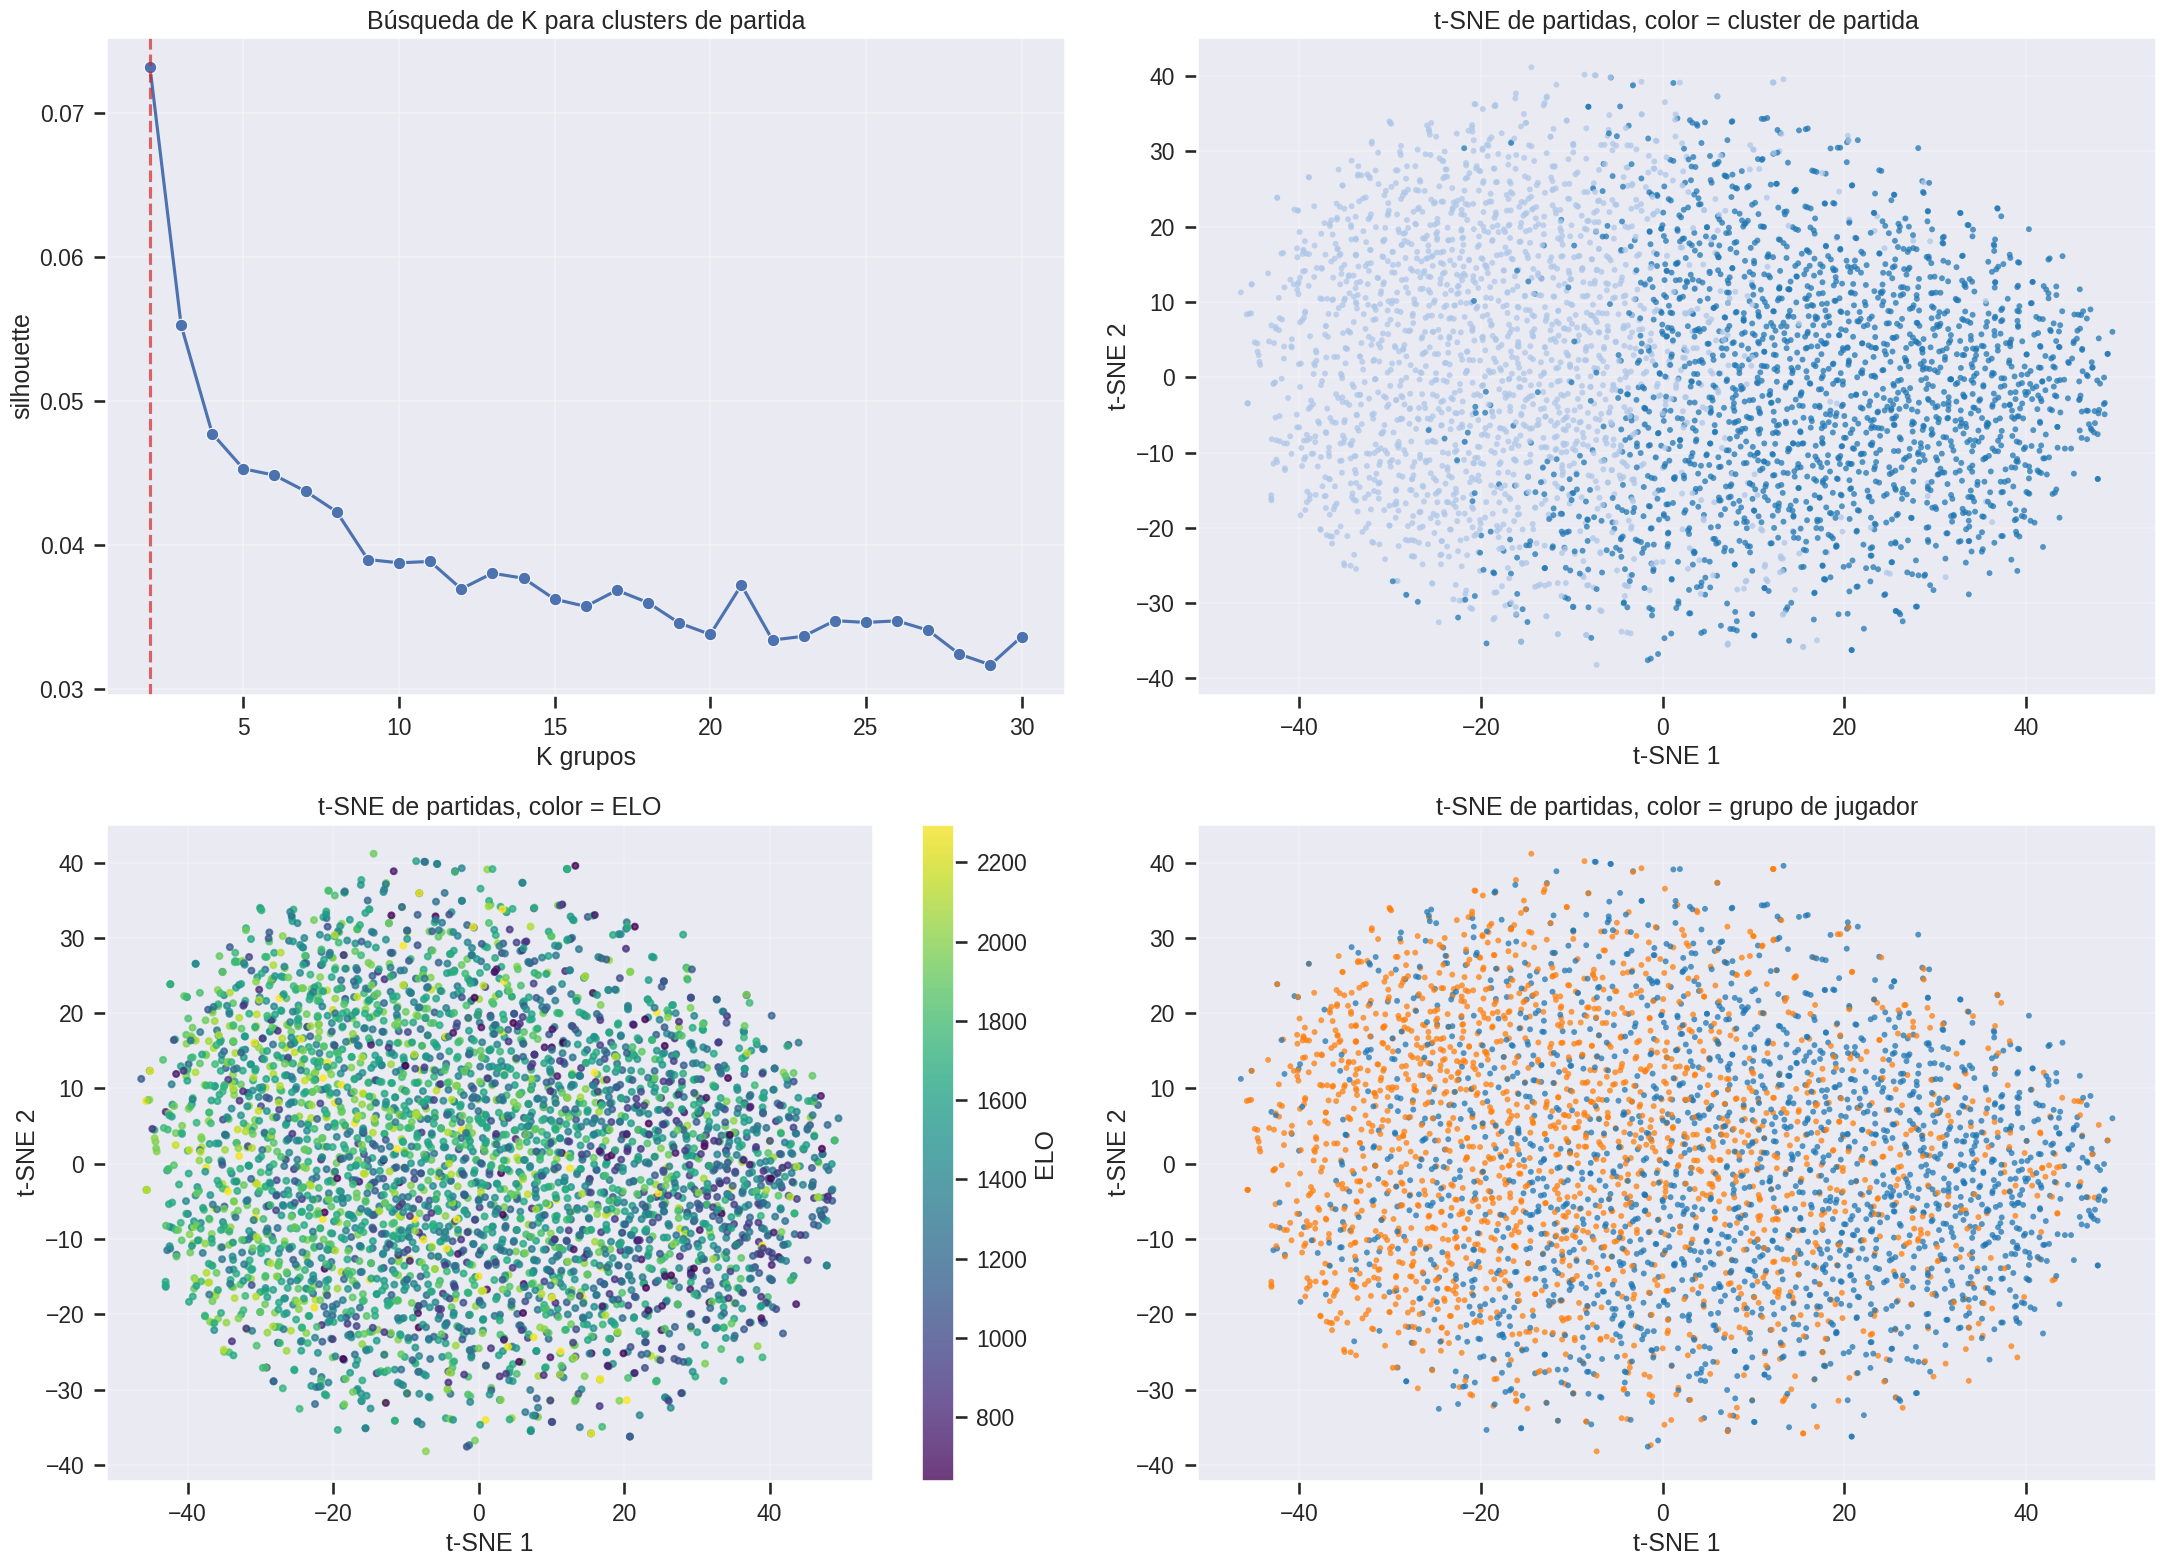

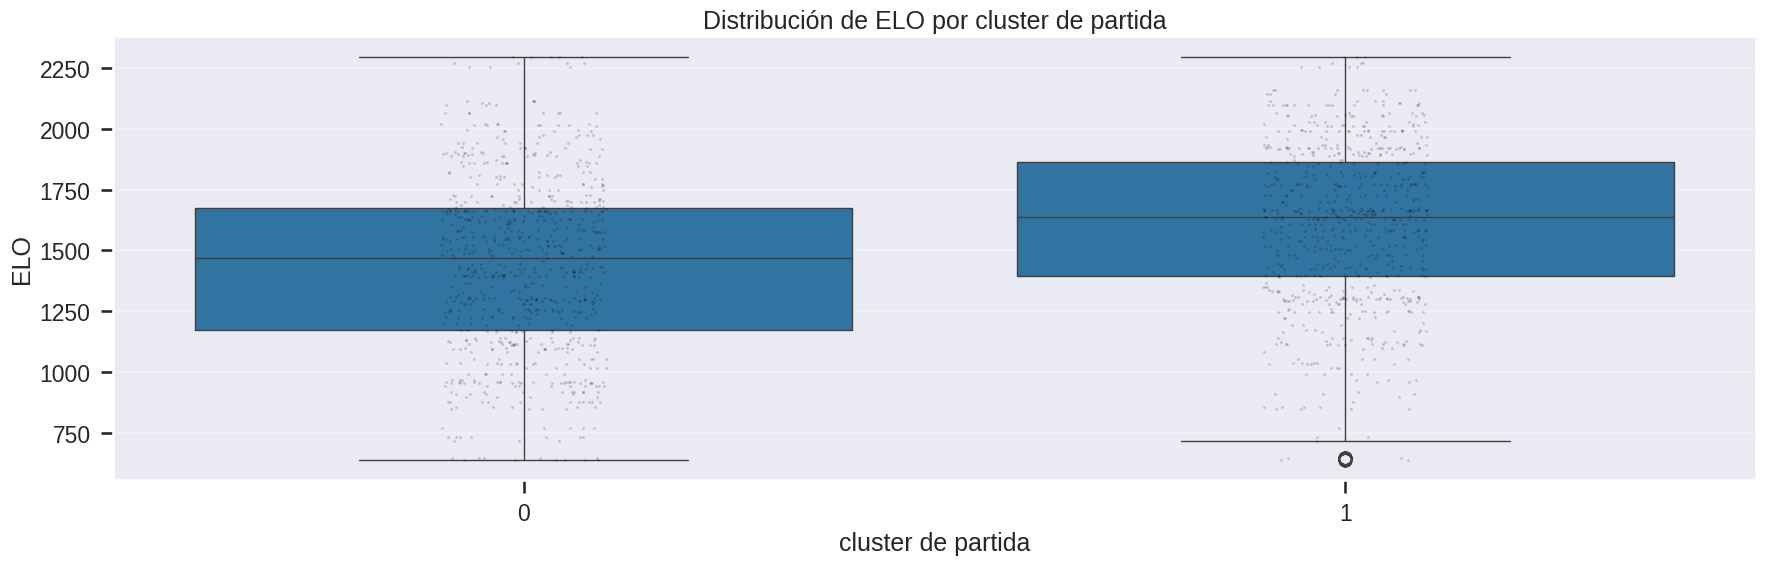

In [14]:
GAME_TSNE_INCLUDE_UNKNOWN = False  # Activarlo reembebe una muestra de jugadores no vistos; puede tardar.
GAME_TSNE_MAX_REFERENCE_GAMES = 4000
GAME_TSNE_UNKNOWN_PLAYERS = 100
GAME_TSNE_UNKNOWN_GAMES_PER_PLAYER = 5
GAME_TSNE_K_MIN = 2
GAME_TSNE_K_MAX = 30
GAME_TSNE_FORCE_K = None
GAME_TSNE_PCA_COMPONENTS = 50
GAME_TSNE_CLUSTER_PCA_COMPONENTS = 30
GAME_TSNE_PERPLEXITY = 35
GAME_TSNE_SILHOUETTE_SAMPLE_SIZE = 2500
GAME_TSNE_RANDOM_STATE = SEED

GAME_TSNE_CLUSTER_SEARCH_CSV_PATH = EVAL_DIR / "tsne_game_cluster_search.csv"
GAME_TSNE_PROJECTION_CSV_PATH = EVAL_DIR / "tsne_game_embeddings_projection.csv"
GAME_TSNE_CLUSTER_SUMMARY_CSV_PATH = EVAL_DIR / "tsne_game_cluster_summary.csv"

try:
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.metrics import (
        calinski_harabasz_score,
        davies_bouldin_score,
        silhouette_score,
    )
except Exception as exc:
    raise RuntimeError(
        "Esta celda necesita scikit-learn para PCA/t-SNE/KMeans. "
        "Instálalo en el kernel del notebook o ejecuta en un entorno que ya lo tenga."
    ) from exc

if "train_embeddings" not in globals() or "TRAIN_SAMPLES" not in globals():
    raise RuntimeError("Faltan train_embeddings o TRAIN_SAMPLES. Ejecuta primero la reconstrucción de memoria.")


def _normalize_rows(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=np.float32)
    return matrix / np.clip(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-8, None)


def _top_value_string(values: pd.Series, n: int = 5) -> str:
    counts = values.dropna().astype(str).value_counts().head(n)
    return ", ".join(f"{idx}:{int(val)}" for idx, val in counts.items())


def _normalized_entropy(values: pd.Series) -> float:
    counts = values.dropna().astype(str).value_counts().to_numpy(dtype=np.float64)
    if counts.size <= 1:
        return 0.0
    probs = counts / np.sum(counts)
    entropy = -float(np.sum(probs * np.log(np.clip(probs, 1e-12, 1.0))))
    return entropy / float(np.log(counts.size))


def _build_reference_game_embedding_table() -> Tuple[np.ndarray, pd.DataFrame]:
    embeddings = np.asarray(train_embeddings, dtype=np.float32)
    rows = []
    for idx, sample in enumerate(TRAIN_SAMPLES):
        rows.append(
            {
                "source": "reference",
                "row_id": f"reference::{sample.player}::{sample.game_id}",
                "player": str(sample.player),
                "elo": float(PLAYER_ELO.get(sample.player, np.nan)),
                "game_id": str(sample.game_id),
                "game_index": np.nan,
                "side": "reference",
                "train_label": int(train_labels[idx]) if "train_labels" in globals() else np.nan,
            }
        )
    meta_df = pd.DataFrame(rows)

    if GAME_TSNE_MAX_REFERENCE_GAMES and len(meta_df) > int(GAME_TSNE_MAX_REFERENCE_GAMES):
        rng = np.random.default_rng(GAME_TSNE_RANDOM_STATE)
        selected_idx = np.sort(
            rng.choice(len(meta_df), size=int(GAME_TSNE_MAX_REFERENCE_GAMES), replace=False)
        )
        embeddings = embeddings[selected_idx]
        meta_df = meta_df.iloc[selected_idx].reset_index(drop=True)

    return embeddings, meta_df


def _collect_unknown_game_embeddings_for_tsne() -> Tuple[np.ndarray, pd.DataFrame]:
    required_names = [
        "selected_unknown_players_df",
        "sample_random_games_from_zst",
        "build_single_game_tensor",
        "embedding_model",
    ]
    missing = [name for name in required_names if name not in globals()]
    if missing:
        raise RuntimeError(f"No se pueden reembeber partidas no vistas. Faltan: {missing}")

    candidates = selected_unknown_players_df.dropna(subset=["player", "elo", "zst_path"]).copy()
    if candidates.empty:
        return np.empty((0, CONFIG.embedding_dim), dtype=np.float32), pd.DataFrame()

    if GAME_TSNE_UNKNOWN_PLAYERS and len(candidates) > int(GAME_TSNE_UNKNOWN_PLAYERS):
        candidates = candidates.sample(
            n=int(GAME_TSNE_UNKNOWN_PLAYERS),
            random_state=GAME_TSNE_RANDOM_STATE,
        ).reset_index(drop=True)

    meta_rows = []
    board_batches = []
    heat_batches = []

    for _, row in candidates.iterrows():
        player_name = str(row["player"])
        zst_path = Path(row["zst_path"])
        if not zst_path.exists():
            continue

        sampled_games, scanned_total, useful_seen = sample_random_games_from_zst(
            zst_path=zst_path,
            player_name=player_name,
            sample_size=max(int(GAME_TSNE_UNKNOWN_GAMES_PER_PLAYER) * 2, int(GAME_TSNE_UNKNOWN_GAMES_PER_PLAYER)),
            seed=stable_player_seed(player_name, GAME_TSNE_RANDOM_STATE + 1701),
            max_games_to_scan=CONFIG.max_games_to_scan_per_player,
        )

        kept = 0
        for game_index, game, side in sampled_games:
            if kept >= int(GAME_TSNE_UNKNOWN_GAMES_PER_PLAYER):
                break
            try:
                boards, heats = build_single_game_tensor(
                    game=game,
                    side=side,
                    sequence_len=CONFIG.sequence_len,
                    fullmove_start=CONFIG.fullmove_start,
                    fullmove_end=CONFIG.fullmove_end,
                    image_size=CONFIG.image_size,
                )
            except Exception:
                continue

            board_batches.append(boards[0])
            heat_batches.append(heats[0])
            meta_rows.append(
                {
                    "source": "unknown",
                    "row_id": f"unknown::{player_name}::{int(game_index)}::{side}",
                    "player": player_name,
                    "elo": float(row["elo"]),
                    "game_id": np.nan,
                    "game_index": int(game_index),
                    "side": str(side),
                    "train_label": np.nan,
                    "scanned_total_games_in_file": int(scanned_total),
                    "useful_games_seen_in_file": int(useful_seen),
                }
            )
            kept += 1

    if not meta_rows:
        return np.empty((0, CONFIG.embedding_dim), dtype=np.float32), pd.DataFrame()

    emb_chunks = []
    batch_size = max(1, int(CONFIG.infer_batch_size))
    for start in range(0, len(meta_rows), batch_size):
        end = min(start + batch_size, len(meta_rows))
        boards_np = np.stack(board_batches[start:end]).astype(np.float32)
        heats_np = np.stack(heat_batches[start:end]).astype(np.float32)
        emb = embedding_model.predict(
            {"board_sequence": boards_np, "heat_sequence": heats_np},
            batch_size=len(boards_np),
            verbose=0,
        ).astype(np.float32)
        emb_chunks.append(emb)
        print(f"Partidas no vistas embebidas para t-SNE: {end}/{len(meta_rows)}")
        del boards_np, heats_np, emb
        gc.collect()

    return np.vstack(emb_chunks), pd.DataFrame(meta_rows)


embedding_chunks = []
meta_frames = []

reference_game_embeddings, reference_game_tsne_df = _build_reference_game_embedding_table()
embedding_chunks.append(reference_game_embeddings)
meta_frames.append(reference_game_tsne_df)

if GAME_TSNE_INCLUDE_UNKNOWN:
    unknown_game_embeddings, unknown_game_tsne_df = _collect_unknown_game_embeddings_for_tsne()
    if len(unknown_game_tsne_df):
        embedding_chunks.append(unknown_game_embeddings)
        meta_frames.append(unknown_game_tsne_df)

game_embedding_matrix = _normalize_rows(np.vstack(embedding_chunks))
game_tsne_df = pd.concat(meta_frames, ignore_index=True)

if len(game_tsne_df) < 10:
    raise RuntimeError("Hay muy pocas partidas para hacer t-SNE/clustering de partidas.")

if "style_reference_cluster_df" in globals() and not style_reference_cluster_df.empty:
    player_to_style_group_for_games = dict(
        zip(style_reference_cluster_df["player"].astype(str), style_reference_cluster_df["style_group"])
    )
    game_tsne_df["player_style_group"] = game_tsne_df["player"].astype(str).map(player_to_style_group_for_games)
else:
    game_tsne_df["player_style_group"] = np.nan

pca_components = min(
    int(GAME_TSNE_PCA_COMPONENTS),
    game_embedding_matrix.shape[1],
    max(2, len(game_tsne_df) - 1),
)
game_pca_model = PCA(n_components=pca_components, random_state=GAME_TSNE_RANDOM_STATE)
game_pca = game_pca_model.fit_transform(game_embedding_matrix)
cluster_dims = min(int(GAME_TSNE_CLUSTER_PCA_COMPONENTS), game_pca.shape[1])
game_cluster_features = game_pca[:, :cluster_dims]

valid_k_min = max(2, int(GAME_TSNE_K_MIN))
valid_k_max = min(int(GAME_TSNE_K_MAX), len(game_tsne_df) - 1)
if valid_k_max < valid_k_min:
    raise RuntimeError("No hay suficientes partidas para buscar K clusters.")

cluster_search_rows = []
for k in range(valid_k_min, valid_k_max + 1):
    kmeans = KMeans(n_clusters=k, random_state=GAME_TSNE_RANDOM_STATE, n_init=20)
    labels = kmeans.fit_predict(game_cluster_features)
    if len(np.unique(labels)) < 2:
        continue

    sample_size = min(int(GAME_TSNE_SILHOUETTE_SAMPLE_SIZE), len(labels))
    cluster_search_rows.append(
        {
            "k": int(k),
            "silhouette": float(
                silhouette_score(
                    game_cluster_features,
                    labels,
                    sample_size=sample_size,
                    random_state=GAME_TSNE_RANDOM_STATE,
                )
            ),
            "davies_bouldin": float(davies_bouldin_score(game_cluster_features, labels)),
            "calinski_harabasz": float(calinski_harabasz_score(game_cluster_features, labels)),
            "inertia": float(kmeans.inertia_),
        }
    )

game_cluster_search_df = pd.DataFrame(cluster_search_rows).sort_values(
    "silhouette", ascending=False
).reset_index(drop=True)
if game_cluster_search_df.empty:
    raise RuntimeError("No se pudo calcular una búsqueda válida de clusters de partidas.")

game_cluster_search_df.to_csv(GAME_TSNE_CLUSTER_SEARCH_CSV_PATH, index=False)

if GAME_TSNE_FORCE_K is None:
    selected_game_k = int(game_cluster_search_df.iloc[0]["k"])
else:
    selected_game_k = int(GAME_TSNE_FORCE_K)
    if selected_game_k < valid_k_min or selected_game_k > valid_k_max:
        raise ValueError(f"GAME_TSNE_FORCE_K debe estar entre {valid_k_min} y {valid_k_max}.")

final_game_kmeans = KMeans(
    n_clusters=selected_game_k,
    random_state=GAME_TSNE_RANDOM_STATE,
    n_init=20,
)
raw_game_cluster_labels = final_game_kmeans.fit_predict(game_cluster_features)

# Ordenamos clusters por tamaño descendente, no por ELO: la idea es explorar estilo, no imponer fuerza.
size_order_df = (
    pd.Series(raw_game_cluster_labels)
    .value_counts()
    .rename_axis("raw_cluster")
    .reset_index(name="games")
    .sort_values(["games", "raw_cluster"], ascending=[False, True])
    .reset_index(drop=True)
)
raw_to_ordered_cluster = {
    int(row.raw_cluster): int(idx) for idx, row in size_order_df.iterrows()
}
game_tsne_df["game_style_cluster"] = [
    raw_to_ordered_cluster[int(label)] for label in raw_game_cluster_labels
]

tsne_input = game_pca[:, : min(50, game_pca.shape[1])]
tsne_perplexity = min(
    float(GAME_TSNE_PERPLEXITY),
    max(2.0, float((len(game_tsne_df) - 1) // 3)),
)
try:
    game_tsne = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        init="pca",
        learning_rate="auto",
        random_state=GAME_TSNE_RANDOM_STATE,
        max_iter=1000,
    ).fit_transform(tsne_input)
except TypeError:
    game_tsne = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        init="pca",
        learning_rate="auto",
        random_state=GAME_TSNE_RANDOM_STATE,
        n_iter=1000,
    ).fit_transform(tsne_input)

game_tsne_df["tsne_x"] = game_tsne[:, 0]
game_tsne_df["tsne_y"] = game_tsne[:, 1]
game_tsne_df["pca_1"] = game_pca[:, 0]
game_tsne_df["pca_2"] = game_pca[:, 1] if game_pca.shape[1] > 1 else 0.0

game_cluster_summary_rows = []
for cluster_id, group in game_tsne_df.groupby("game_style_cluster", sort=True):
    style_group_mix = (
        _top_value_string(group["player_style_group"], n=5)
        if group["player_style_group"].notna().any()
        else ""
    )
    game_cluster_summary_rows.append(
        {
            "game_style_cluster": int(cluster_id),
            "games": int(len(group)),
            "players": int(group["player"].nunique()),
            "sources": _top_value_string(group["source"], n=5),
            "mean_elo": float(group["elo"].mean()),
            "median_elo": float(group["elo"].median()),
            "std_elo": float(group["elo"].std(ddof=0)),
            "min_elo": float(group["elo"].min()),
            "max_elo": float(group["elo"].max()),
            "player_entropy_norm": float(_normalized_entropy(group["player"])),
            "top_players": _top_value_string(group["player"], n=8),
            "style_group_mix": style_group_mix,
        }
    )

game_cluster_summary_df = pd.DataFrame(game_cluster_summary_rows).sort_values(
    "game_style_cluster"
).reset_index(drop=True)

game_tsne_df.to_csv(GAME_TSNE_PROJECTION_CSV_PATH, index=False)
game_cluster_summary_df.to_csv(GAME_TSNE_CLUSTER_SUMMARY_CSV_PATH, index=False)

# Centroides de cluster de partida en el embedding original: sirven para clasificar nuevas partidas sin reentrenar.
game_cluster_ids = np.array(sorted(game_tsne_df["game_style_cluster"].unique()), dtype=np.int32)
game_cluster_centroids = []
for cluster_id in game_cluster_ids:
    mask = game_tsne_df["game_style_cluster"].to_numpy() == int(cluster_id)
    centroid = game_embedding_matrix[mask].mean(axis=0)
    centroid = centroid / np.clip(np.linalg.norm(centroid), 1e-8, None)
    game_cluster_centroids.append(centroid)
game_cluster_centroids = np.vstack(game_cluster_centroids).astype(np.float32)


def predict_game_style_cluster_from_embeddings(
    embeddings: np.ndarray,
    top_k: int = 5,
) -> pd.DataFrame:
    emb = np.asarray(embeddings, dtype=np.float32)
    if emb.ndim == 1:
        emb = emb[None, :]
    emb = _normalize_rows(emb)
    sims = np.clip(emb @ game_cluster_centroids.T, -1.0, 1.0)
    dists = np.sqrt(np.maximum(2.0 - 2.0 * sims, 0.0) + 1e-12)
    mean_dists = dists.mean(axis=0)
    order = np.argsort(mean_dists)[: max(1, int(top_k))]
    summary_by_cluster = game_cluster_summary_df.set_index("game_style_cluster")
    return pd.DataFrame(
        {
            "rank": np.arange(1, len(order) + 1),
            "game_style_cluster": game_cluster_ids[order],
            "distance": mean_dists[order],
            "cluster_games": [
                int(summary_by_cluster.loc[int(g), "games"]) for g in game_cluster_ids[order]
            ],
            "cluster_players": [
                int(summary_by_cluster.loc[int(g), "players"]) for g in game_cluster_ids[order]
            ],
            "cluster_mean_elo": [
                float(summary_by_cluster.loc[int(g), "mean_elo"]) for g in game_cluster_ids[order]
            ],
            "cluster_top_players": [
                summary_by_cluster.loc[int(g), "top_players"] for g in game_cluster_ids[order]
            ],
        }
    )


def predict_game_style_cluster_from_pgn(
    pgn_path: Path,
    game_index: int = 1,
    side: str = "white",
    top_k: int = 5,
) -> pd.DataFrame:
    if "_embed_game_from_pgn" not in globals():
        raise RuntimeError("Falta _embed_game_from_pgn. Ejecuta la celda de helpers de inferencia antes.")
    emb = _embed_game_from_pgn(Path(pgn_path), game_index=game_index, side=side)
    return predict_game_style_cluster_from_embeddings(emb, top_k=top_k)

print(f"Partidas visualizadas: {len(game_tsne_df)}")
print(f"K elegido para clusters de partida: {selected_game_k}")
print(f"Perplexity t-SNE usada: {tsne_perplexity:.1f}")
print(f"CSV búsqueda K: {GAME_TSNE_CLUSTER_SEARCH_CSV_PATH}")
print(f"CSV proyección partidas: {GAME_TSNE_PROJECTION_CSV_PATH}")
print(f"CSV resumen clusters: {GAME_TSNE_CLUSTER_SUMMARY_CSV_PATH}")

display(game_cluster_search_df.head(10))
display(game_cluster_summary_df)
display(game_tsne_df.head(20))

fig, axes = plt.subplots(2, 2, figsize=(22, 16))

sns.lineplot(
    data=game_cluster_search_df.sort_values("k"),
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].axvline(selected_game_k, color="tab:red", linestyle="--", alpha=0.7)
axes[0, 0].set_title("Búsqueda de K para clusters de partida")
axes[0, 0].set_xlabel("K grupos")
axes[0, 0].set_ylabel("silhouette")
axes[0, 0].grid(True, alpha=0.3)

sns.scatterplot(
    data=game_tsne_df,
    x="tsne_x",
    y="tsne_y",
    hue="game_style_cluster",
    palette="tab20",
    s=18,
    alpha=0.75,
    linewidth=0,
    legend=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("t-SNE de partidas, color = cluster de partida")
axes[0, 1].set_xlabel("t-SNE 1")
axes[0, 1].set_ylabel("t-SNE 2")
axes[0, 1].grid(True, alpha=0.2)

elo_scatter = axes[1, 0].scatter(
    game_tsne_df["tsne_x"],
    game_tsne_df["tsne_y"],
    c=game_tsne_df["elo"],
    s=18,
    alpha=0.75,
    cmap="viridis",
)
axes[1, 0].set_title("t-SNE de partidas, color = ELO")
axes[1, 0].set_xlabel("t-SNE 1")
axes[1, 0].set_ylabel("t-SNE 2")
axes[1, 0].grid(True, alpha=0.2)
fig.colorbar(elo_scatter, ax=axes[1, 0], label="ELO")

if game_tsne_df["player_style_group"].notna().any():
    plot_style_df = game_tsne_df.dropna(subset=["player_style_group"]).copy()
    plot_style_df["player_style_group"] = plot_style_df["player_style_group"].astype(int)
    sns.scatterplot(
        data=plot_style_df,
        x="tsne_x",
        y="tsne_y",
        hue="player_style_group",
        palette="tab10",
        s=18,
        alpha=0.75,
        linewidth=0,
        legend=False,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("t-SNE de partidas, color = grupo de jugador")
else:
    sns.scatterplot(
        data=game_tsne_df,
        x="tsne_x",
        y="tsne_y",
        hue="source",
        s=18,
        alpha=0.75,
        linewidth=0,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("t-SNE de partidas, color = origen")
axes[1, 1].set_xlabel("t-SNE 1")
axes[1, 1].set_ylabel("t-SNE 2")
axes[1, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(18, 6))
sns.boxplot(
    data=game_tsne_df,
    x="game_style_cluster",
    y="elo",
    color="tab:blue",
    ax=ax,
)
sns.stripplot(
    data=game_tsne_df.sample(
        n=min(len(game_tsne_df), 1500),
        random_state=GAME_TSNE_RANDOM_STATE,
    ),
    x="game_style_cluster",
    y="elo",
    color="black",
    alpha=0.18,
    size=2,
    ax=ax,
)
ax.set_title("Distribución de ELO por cluster de partida")
ax.set_xlabel("cluster de partida")
ax.set_ylabel("ELO")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
